# 🔬 Experimento Comparativo — YOLOv8 vs SSD MobileNetV3 vs Ensemble (Detecção de EPI)


Notebook de suporte para o artigo do MBA. Implementa um protocolo experimental real:

- Dataset **Construction-PPE** (Ultralytics) — 1.416 imagens, 11 classes
- **Hold-out estratificado** separado da base ANTES de qualquer treino (Parte 3), avaliado apenas ao final (Parte 7b) — endereça a limitação "não há hold-out separado"
- **K-Fold estratificado** pela presença de violação (`no_helmet`, `no_gloves`, `no_goggle`, `no_boots`), com **K configurável** (padrão 5, mas o parâmetro `K` pode ser elevado para 10 se houver GPU dedicada/paga) — endereça a limitação "K=5 em vez de K=10"
- Treino do **YOLOv8** e do **SSD MobileNetV3 (SSDLite320)** em cada fold, sob o mesmo split
- **Terceira abordagem — Ensemble YOLOv8 + SSD (Parte 6b):** fusão das predições dos dois detectores via *Weighted Boxes Fusion* (WBF), avaliada nos **mesmos folds e no mesmo Hold-Out**, com as mesmas métricas (mAP@0.5, Precision, Recall, F1, FPS). **Não exige re-treino:** reutiliza os pesos já salvos de cada modelo. As três abordagens (YOLOv8 isolado, SSD isolado e Ensemble) são comparadas nas Partes 7 a 10 e na análise da imagem/vídeo externo (Parte 11)
- **Augmentation simétrica**: o SSD-Lite agora recebe flip horizontal + jitter de cor (Parte 4b), reduzindo (sem eliminar totalmente) a assimetria frente ao pipeline do YOLOv8 — endereça a limitação "assimetria de augmentation"
- **Precision, Recall e F1-Score isolados por modelo** (não apenas F1 agregado) — endereça a limitação "Precision/Recall não isolados"
- **Estimativa de exposição financeira à NR 28** a partir do Recall medido no hold-out, com valores de multa/trabalhadores expostos parametrizáveis pelo usuário (Parte 9b) — endereça a limitação "nenhuma estimativa financeira calculada"
- **Medição de FPS em dois níveis** (alto nível via API do Ultralytics vs. baixo nível via forward puro do modelo) para o YOLOv8, e nota explícita sobre a comparabilidade com a medição do SSD — mitiga (não elimina) a ameaça à validade de construto do FPS
- Checkpoint em Google Drive a cada fold concluído (retomável se a sessão do Colab cair)
- Ao final: teste de Friedman (omnibus) e comparações pareadas entre as três abordagens — normalidade (Shapiro-Wilk) → teste t pareado ou Wilcoxon, com correção de Holm

**O que continua sendo uma limitação de fato, não "corrigível" via código** (documentado explicitamente onde ocorre):
- O dataset Construction-PPE **não tem uma classe `no_vest`** — isso é uma característica do dataset público, não um bug do pipeline. O código agora **valida e avisa** isso explicitamente na Parte 2, em vez de deixar a lacuna implícita.
- As **resoluções nativas diferem por arquitetura** (YOLOv8n a 640×640, SSDLite320 a 320×320 — o "320" está no nome porque é fixo no design do modelo). O código agora testa o **YOLOv8n também a 320×320** como ponto de comparação adicional (Parte 5), mas não é possível forçar o SSDLite320 a rodar nativamente a 640×640 sem redefinir sua grade de âncoras (fora do escopo deste notebook).
- A distribuição de iluminação/ângulo de câmera do dataset público (validade externa) não é algo que o código possa corrigir.

**Ambiente:** Google Colab, GPU T4 (gratuito).

**⚠️ Sobre tempo:** com hold-out, o tempo total sobe (mais um treino completo por modelo, ao final). Cada fold agora também roda uma medição extra de FPS a 320×320 para o YOLO (rápida, poucos segundos). Ajuste `K`, `YOLO_EPOCHS`, `SSD_EPOCHS` e `RUN_HOLDOUT_FINAL_TRAINING` conforme o tempo de sessão disponível — o notebook salva tudo no Google Drive e pode ser retomado de onde parou. O ensemble adiciona apenas tempo de **inferência** (poucos minutos por fold), pois não treina nada.

---

---

---

### 🆕 Partes adicionadas — validação experimental completa (v6)

Este notebook reúne, em **um único arquivo**, o experimento e as análises exigidas para o relatório de validação (Formato B):

| Parte | O que faz |
|---|---|
| **0** (revisada) | Monta o Drive no Colab **ou** usa pasta local fora dele |
| **0b** | **Pergunta de avaliação e hipóteses verificáveis** (H1–H3, mais H3' exploratória) |
| **3a** | **Justificativa da estratégia de divisão dos dados** |
| **3b / 3c** | Descrição dos dados; quase-duplicatas confirmadas e diagnóstico da divisão |
| **6d** | Sementes fixas (SSD) e registro de versões/GPU |
| **7e** | **YOLOv8 v2** sem seleção de checkpoint no teste (adotado por padrão, `ADOPT_V2_AS_MAIN = True`) |
| **9c–9e** | Métricas por classe, matriz de confusão, galeria de erros |
| **9f** | Análise qualitativa **quantificada** dos erros de violação |
| **9g** | Limiar por classe escolhido fora-da-amostra (exploratório), com **três critérios** de alerta por imagem |
| **9h** | Testes das hipóteses, ICs e sensibilidades (AP em NumPy para o limite de detecções) |
| **9i** | Exposição financeira **corrigida** (a Parte 9b usava o recall global) |
| **10b** | Tabelas prontas para o relatório (`tabelas_relatorio.md`) — **roda depois da Parte 10** |
| **12** | Ameaças à validade e limitações |

**Sobre as saídas (v6):** parte da execução da v5, sem erros. As **Partes 9g, 9h e 10b foram corrigidas e estão sem saída — rode-as** (a 9g usa o cache `oof_predictions.pkl`; a 10b agora vem depois da Parte 10 para usar o FPS da mesma execução). A foto da Parte 11 foi retirada das saídas.
**Ordem:** rode de cima para baixo. Se reiniciar a sessão, as Partes 7 e 7e retomam dos CSVs e a 9g reaproveita o cache.

> **v7 (apenas visualização, sem re-treino):** nova Parte 9c-bis (acertos por classe e por modelo, com gráfico); gráficos das Partes 3b, 9, 9e, 9g e 11 agora um abaixo do outro; matriz de confusão (Parte 9d) com cores mais legíveis. As saídas das células alteradas ainda mostram a execução anterior até serem rodadas de novo.


## Parte 0b · Pergunta de avaliação e hipóteses verificáveis

**Pergunta de avaliação.** Entre YOLOv8n, SSD MobileNetV3 (SSDLite320) e o Ensemble YOLOv8 + SSD (Weighted Boxes Fusion), qual detecta melhor os EPIs e, principalmente, as **violações de uso de EPI** (`no_helmet`, `no_goggle`, `no_gloves`, `no_boots`) no conjunto Construction-PPE — e a que custo de velocidade?

**Delineamento.** Medidas repetidas: as três abordagens são avaliadas nos **mesmos 10 folds** (unidade de análise = fold, n = 10) e, uma única vez, no Hold-Out. α = 0,05, com correção de Holm nas comparações pareadas de cada família.

| Id | Hipótese | Métrica e teste | Regra de decisão | Onde |
|---|---|---|---|---|
| **H1** (primária) | H0: as três abordagens têm o mesmo mAP@0.5. H1: pelo menos uma difere. | mAP@0.5 por fold. Friedman → Shapiro-Wilk das diferenças → t pareado ou Wilcoxon, com Holm | p ajustado < 0,05 rejeita H0 | Partes 8 e 9h |
| H1a | Direção esperada a priori: YOLOv8 > SSD (detector completo pré-treinado no COCO, entrada 640) | Δ médio do mAP@0.5 e p pareado | suportada se Δ > 0 e p ajustado < 0,05 | Parte 9h |
| H1b | Direção esperada a priori: Ensemble > YOLOv8 (a fusão compensa erros de um modelo com o outro) | idem | idem | Parte 9h |
| **H2** (violações) | H0: o AP@0.5 médio das 4 classes de violação é igual entre as abordagens. H1: difere. | AP@0.5 macro das classes de violação, por fold. t pareado ou Wilcoxon, com Holm (também sem `no_boots`, a classe mais rara) | p ajustado < 0,05 rejeita H0 | Partes 9c e 9h |
| **H3** (suficiência operacional, **pré-especificada com o limiar fixo 0,25**) | Ao menos uma abordagem atinge **recall por imagem ≥ 0,80** ao sinalizar violações (critério de aceitação **ilustrativo**; ajuste conforme o risco da aplicação) | Recall do "alerta por imagem" no Hold-Out; IC95% de Wilson (n = 59 imagens com violação) | **refutada** se o limite superior do IC < 0,80 | Parte 9h |
| **H3'** (exploratória) | O mesmo critério, com **limiar por classe escolhido fora-da-amostra** (Parte 9g), avaliado em três critérios de acerto: permissivo (qualquer classe de violação), por classe e por caixa | IC95% de Wilson | suportada se o limite **inferior** do IC ≥ 0,80; refutada se o **superior** < 0,80; senão inconclusiva | Partes 9g e 9h |

**Por que H2 e H3.** O mAP global é dominado pelas classes de conformidade (capacete, colete, botas...), muito mais frequentes e fáceis. Testar só H1 permitiria concluir "o YOLOv8 é o melhor" sem revelar se algum modelo é **útil para o objetivo real** — detectar violações. H2 compara as abordagens nas violações; H3 confronta o desempenho com um critério de aceitação.

**Velocidade** (FPS e latência) é apenas descrita, não testada estatisticamente: benchmark de 50 imagens no mesmo dispositivo e sessão (Parte 10).

**Ressalvas do delineamento.** Os folds compartilham dados de treino, então a independência entre observações é aproximada e os p-valores são **indicativos** (Nadeau & Bengio, 2003). O critério da H3 foi fixado sem otimização, mas se for alterado depois de ver os resultados, apresente a H3 como análise exploratória.

## Parte 0 · Montar Google Drive (persistência entre sessões) — ou usar pasta local

No Colab, monta o Drive e salva tudo em `MyDrive/epi_experimento`. Fora do Colab (ex.: máquina do professor), usa `./epi_experimento`, para que o notebook seja reproduzível sem o Drive do autor.

In [1]:
# ==== Parte 0 · Google Drive (Colab) ou pasta local ====
# No Colab: monta o Google Drive. Fora do Colab (ex.: máquina do professor): usa uma pasta local.
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = "/content/drive/MyDrive/epi_experimento"
    IN_COLAB = True
except ImportError:
    PROJECT_DIR = os.path.abspath("./epi_experimento")
    IN_COLAB = False

os.makedirs(PROJECT_DIR, exist_ok=True)

# A Parte 5 grava as pastas temporárias de cada fold em /content (padrão do Colab).
try:
    os.makedirs("/content", exist_ok=True)
except PermissionError:
    print("⚠️ Sem permissão para criar /content. Em `materialize_yolo_fold`, troque "
          "'/content' por uma pasta local (ex.: './tmp').")

print(f"Ambiente: {'Google Colab' if IN_COLAB else 'local'}")
print(f"Resultados e checkpoints serão salvos em: {PROJECT_DIR}")

Mounted at /content/drive
Ambiente: Google Colab
Resultados e checkpoints serão salvos em: /content/drive/MyDrive/epi_experimento


## Parte 1 · Instalação de dependências

In [2]:
%pip install -q ultralytics torchmetrics pycocotools scikit-learn scipy pandas matplotlib ensemble-boxes
import torch
print("CUDA disponível:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "nenhuma (vai rodar em CPU — MUITO lento)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 9.0 MB/s eta 0:00:00
CUDA disponível: True
GPU: NVIDIA A100-SXM4-40GB


## Parte 2 · Baixar e organizar o dataset Construction-PPE

O dataset já vem dividido em train/val/test pelo `construction-ppe.yaml` oficial, mas para o K-Fold
nós juntamos **todas** as imagens numa única pool e fazemos nossos próprios splits — assim os dois
modelos são comparados exatamente nos mesmos dados em cada fold.

In [3]:
import os
from ultralytics.utils import DATASETS_DIR
from ultralytics.utils.downloads import safe_download

DATASET_ROOT = DATASETS_DIR / "construction-ppe"

if not DATASET_ROOT.exists():
    print("Baixando dataset Construction-PPE (~180 MB)...")
    safe_download(
        url="https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip",
        dir=DATASETS_DIR,
        unzip=True,
    )
else:
    print("Dataset já em cache:", DATASET_ROOT)

CLASS_NAMES = ["helmet", "gloves", "vest", "boots", "goggles", "none",
               "Person", "no_helmet", "no_goggle", "no_gloves", "no_boots"]
VIOLATION_CLASS_IDS = {7, 8, 9, 10}   # no_helmet, no_goggle, no_gloves, no_boots
NUM_CLASSES_YOLO = len(CLASS_NAMES)   # 11 (sem contar background)

print(f"Classes ({NUM_CLASSES_YOLO}): {CLASS_NAMES}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Baixando dataset Construction-PPE (~180 MB)...
Unzipping /content/datasets/construction-ppe.zip to /content/datasets/construction-ppe...: 100% ━━━━━━━━━━━━ 2852/2852 2.7Kfiles/s 1.1s
Classes (11): ['helmet', 'gloves', 'vest', 'boots', 'goggles', 'none', 'Person', 'no_helmet', 'no_goggle', 'no_gloves', 'no_boots']


In [4]:
# --- Checagem explícita de cobertura de classes (limitação documentada, não "corrigível" via código) ---
# O Construction-PPE mapeia "vest" (conformidade) mas NÃO tem uma classe "no_vest" (violação).


PAIRED_CLASSES = {
    "helmet": "no_helmet",
    "goggles": "no_goggle",
    "gloves": "no_gloves",
    "boots": "no_boots",
}
UNPAIRED_CLASSES = [c for c in CLASS_NAMES if c not in PAIRED_CLASSES
                     and c not in PAIRED_CLASSES.values() and c not in ("none", "Person")]

print("Pares conformidade/violação disponíveis neste dataset:")
for ok, bad in PAIRED_CLASSES.items():
    print(f"  - {ok:10s} <-> {bad}")
print(f"\nClasses SEM par de violação equivalente (não avaliáveis como par conformidade/violação): {UNPAIRED_CLASSES}")
if "vest" in UNPAIRED_CLASSES:
    print("\n⚠️  ATENÇÃO: 'vest' não tem uma classe 'no_vest' neste dataset. A comparação "
          "colete/sem-colete NÃO será reportada nos resultados deste notebook.")

# Hook opcional: caminho para um dataset complementar (formato YOLO) que já tenha anotações
# de "no_vest", caso o time queira ampliar a cobertura de classes no futuro. Desativado por padrão.
MERGE_VEST_DATASET_DIR = None  # ex.: "/content/drive/MyDrive/epi_extra_vest_dataset"
if MERGE_VEST_DATASET_DIR is not None:
    raise NotImplementedError(
        "Hook de mesclagem de dataset complementar de 'no_vest' ainda não implementado neste "
        "notebook — defina MERGE_VEST_DATASET_DIR=None para seguir apenas com o Construction-PPE, "
        "ou implemente a função merge_extra_vest_annotations(all_images, MERGE_VEST_DATASET_DIR) "
        "antes de habilitar esta opção."
    )

Pares conformidade/violação disponíveis neste dataset:
  - helmet     <-> no_helmet
  - goggles    <-> no_goggle
  - gloves     <-> no_gloves
  - boots      <-> no_boots

Classes SEM par de violação equivalente (não avaliáveis como par conformidade/violação): ['vest']

⚠️  ATENÇÃO: 'vest' não tem uma classe 'no_vest' neste dataset. A comparação colete/sem-colete NÃO será reportada nos resultados deste notebook.


In [5]:
import glob

# Junta todas as imagens de train/val/test numa lista única (caminho da imagem + caminho do label .txt)
all_images = []
for split in ["train", "val", "test"]:
    img_dir = DATASET_ROOT / "images" / split
    lbl_dir = DATASET_ROOT / "labels" / split
    if not img_dir.exists():
        continue
    for img_path in sorted(glob.glob(str(img_dir / "*.*"))):
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = lbl_dir / f"{stem}.txt"
        all_images.append((img_path, str(lbl_path) if lbl_path.exists() else None))

print(f"Total de imagens na pool: {len(all_images)}")

Total de imagens na pool: 1416


## Parte 3 · Separar Hold-Out e criar os folds estratificados

**Mudança em relação à v1:** antes de criar os folds de validação cruzada, separamos um conjunto de
**Hold-Out** (por padrão, 20% da pool, nunca usado durante o treino ou a validação cruzada). O K-Fold
estratificado é aplicado apenas sobre o restante ("desenvolvimento"). Ao final do notebook (Parte 7b),
cada modelo é treinado uma última vez usando todo o conjunto de desenvolvimento e avaliado, uma única
vez, no Hold-Out — reproduzindo o desenho "K-Fold + Hold-Out" descrito no TCC.

Estratificação por um rótulo binário por imagem: `1` se a imagem contém **alguma classe de violação**
(`no_helmet`, `no_goggle`, `no_gloves`, `no_boots`), `0` caso contrário. Isso garante que tanto o
Hold-Out quanto cada fold tenham uma proporção parecida de imagens "com infração" e "sem infração".

`K` agora é um parâmetro explícito: o padrão é 5 (adequado à GPU T4 gratuita do Colab), mas pode ser
aumentado para 10 caso o time tenha acesso a uma GPU dedicada/paga, sem precisar alterar mais nada no
notebook.

In [6]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split

def has_violation(label_path):
    if label_path is None or not os.path.exists(label_path):
        return 0
    with open(label_path) as f:
        for line in f:
            cls_id = int(line.split()[0])
            if cls_id in VIOLATION_CLASS_IDS:
                return 1
    return 0

y_strat = np.array([has_violation(lbl) for _, lbl in all_images])
print("Imagens com violação:", y_strat.sum(), "/", len(y_strat))

# --- Parâmetros configuráveis ---
K = 10                     # eleve para 10 se tiver GPU dedicada/paga (ver nota da Parte 3 acima)
HOLD_OUT_FRACTION = 0.20  # 20% da pool reservados como Hold-Out; defina 0.0 para desativar
RANDOM_STATE = 42

pool_idx = np.arange(len(all_images))

if HOLD_OUT_FRACTION > 0:
    dev_idx, holdout_idx = train_test_split(
        pool_idx,
        test_size=HOLD_OUT_FRACTION,
        stratify=y_strat,
        random_state=RANDOM_STATE,
    )
else:
    dev_idx = pool_idx
    holdout_idx = np.array([], dtype=int)

print(f"\nPool total: {len(all_images)} imagens")
print(f"Desenvolvimento (usado nos {K} folds): {len(dev_idx)} imagens")
print(f"Hold-Out (nunca visto até a Parte 7b): {len(holdout_idx)} imagens "
      f"({100 * len(holdout_idx) / len(all_images):.1f}% da pool)")

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)
folds = []
for train_rel, test_rel in skf.split(np.zeros(len(dev_idx)), y_strat[dev_idx]):
    # Os índices retornados pelo StratifiedKFold são relativos a `dev_idx`;
    # traduzimos de volta para índices absolutos em `all_images` para manter o
    # restante do notebook (materialize_yolo_fold, train_and_eval_*) inalterado.
    folds.append((dev_idx[train_rel], dev_idx[test_rel]))

print(f"\n{K} folds criados sobre o conjunto de desenvolvimento.")
print("Tamanhos do fold de teste:", [len(te) for _, te in folds])
print("Tamanhos do fold de treino:", [len(tr) for tr, _ in folds])

Imagens com violação: 294 / 1416

Pool total: 1416 imagens
Desenvolvimento (usado nos 10 folds): 1132 imagens
Hold-Out (nunca visto até a Parte 7b): 284 imagens (20.1% da pool)

10 folds criados sobre o conjunto de desenvolvimento.
Tamanhos do fold de teste: [114, 114, 113, 113, 113, 113, 113, 113, 113, 113]
Tamanhos do fold de treino: [1018, 1018, 1019, 1019, 1019, 1019, 1019, 1019, 1019, 1019]


## Parte 3a · Justificativa da estratégia de divisão dos dados

| Decisão | Por quê | Evidência no notebook |
|---|---|---|
| **Pool única**: as divisões oficiais do dataset são reunidas (1.416 imagens) e re-particionadas | Controlar a estratificação e garantir que hold-out, folds e treino sigam a mesma regra para as três abordagens | Partes 2 e 3 |
| **Hold-Out de 20%** (284 imagens; 59 com violação) separado **antes de qualquer treino**, com `RANDOM_STATE` fixo | Estimativa final não usada para treinar, escolher hiperparâmetros nem selecionar checkpoints; o `split_id` audita que nenhuma linha de resultado vem de outra partição | Partes 3, 6c, 7b |
| **Estratificação pela presença de violação** (20,8% das imagens) | A violação é a classe-alvo e é minoritária; sem estratificar, folds poderiam ficar com poucas ou nenhuma imagem de violação | Partes 3 e 3c (diagnóstico por bloco) |
| **Não** estratificar por classe individual | Cada imagem tem várias classes (multirrótulo), o que inviabiliza estratificar por classe. **Consequência aceita:** classes raras (`no_boots`: 36 imagens, 12 instâncias no Hold-Out) variam entre folds | Partes 3b e 3c |
| **Validação cruzada K = 10** sobre o desenvolvimento (1.132 imagens) | Treina com ~90% dos dados (menos viés que K pequeno) e gera 10 observações pareadas para Friedman/Wilcoxon (com n = 10 o menor p do Wilcoxon é 0,002; com K = 5 seria 0,0625, sem poder rejeitar) | Parte 7 |
| **Mesmas partições para as três abordagens** | Delineamento pareado: a diferença entre modelos não é confundida com a dificuldade do fold. O Ensemble usa os modelos do próprio fold, sem re-treino | Partes 6c, 7d |
| **Hold-Out avaliado uma única vez**, com o modelo final treinado em todo o desenvolvimento | Evita reaproveitar o teste para decisões de projeto. Na v1, o YOLOv8 escolhia o `best.pt` olhando o Hold-Out; a Parte 7e refaz sem essa escolha | Partes 7b e 7e |
| **Controles de vazamento**: hash exato (MD5), quase-duplicatas por correlação e sensibilidade do Hold-Out | Imagens de uma mesma cena em treino e teste inflariam o desempenho | Partes 3b, 3c e 9h |

**Limites que devem constar no relatório:** (i) não há metadados de cena/vídeo, então a divisão não é agrupada por origem — só é possível checar quase-duplicatas *a posteriori*; (ii) um único Hold-Out tem variabilidade (ver IC na Parte 9h); (iii) a estratificação binária não equilibra as classes individuais.

## Parte 3b · Descrição e qualidade dos dados (EDA) e checagem de duplicatas

Instâncias por classe, imagens por classe, tamanho das caixas, distribuição **desenvolvimento × hold-out** e checagem de **duplicatas exatas (MD5) e quase-duplicatas (dHash)**.
Pares que caem em blocos diferentes (fold de teste / hold-out) são um possível vazamento treino→teste: cite no relatório o que for encontrado.
Gera `eda_por_classe.csv`, `eda_particoes.csv`, `eda_classes.png` e `possiveis_duplicatas.csv`.

Imagens na pool: 1416 | com >=1 violação: 294 (20.8%) | sem nenhuma anotação: 0
Caixas por imagem — média 8.1, mediana 7, máx 58
Tamanhos de imagem mais comuns (largura, altura): [((640, 640), 1116), ((1024, 768), 41), ((1024, 683), 39), ((683, 1024), 26), ((768, 1024), 25), ((612, 408), 24)]

Resumo por classe:


,classe,tipo,instâncias,imagens com a classe,% das imagens,área mediana (fração da imagem),% caixas pequenas (<32px a 640)
0,helmet,conformidade,1734,1047,73.9407,0.0119,9.8616
1,gloves,conformidade,1445,705,49.7881,0.0068,7.4740
2,vest,conformidade,1618,1048,74.0113,0.0633,0.9889
3,boots,conformidade,1597,669,47.2458,0.0130,4.6963
4,goggles,conformidade,518,480,33.8983,0.0069,5.4054
5,none,pessoa / genérica,797,425,30.0141,0.0516,4.8934
6,Person,pessoa / genérica,2245,1339,94.5621,0.2265,0.0445
7,no_helmet,violação,485,283,19.9859,0.0187,3.2990
8,no_goggle,violação,411,265,18.7147,0.0053,25.5474
9,no_gloves,violação,556,236,16.6667,0.0099,7.7338



Desenvolvimento vs. Hold-Out (instâncias e % por parte):


part,desenvolvimento,hold-out,% desenvolvimento,% hold-out
helmet,1380,354,15.00,15.26
gloves,1132,313,12.30,13.49
vest,1300,318,14.13,13.71
boots,1255,342,13.64,14.74
goggles,409,109,4.45,4.70
none,643,154,6.99,6.64
Person,1797,448,19.53,19.31
no_helmet,392,93,4.26,4.01
no_goggle,326,85,3.54,3.66
no_gloves,464,92,5.04,3.97


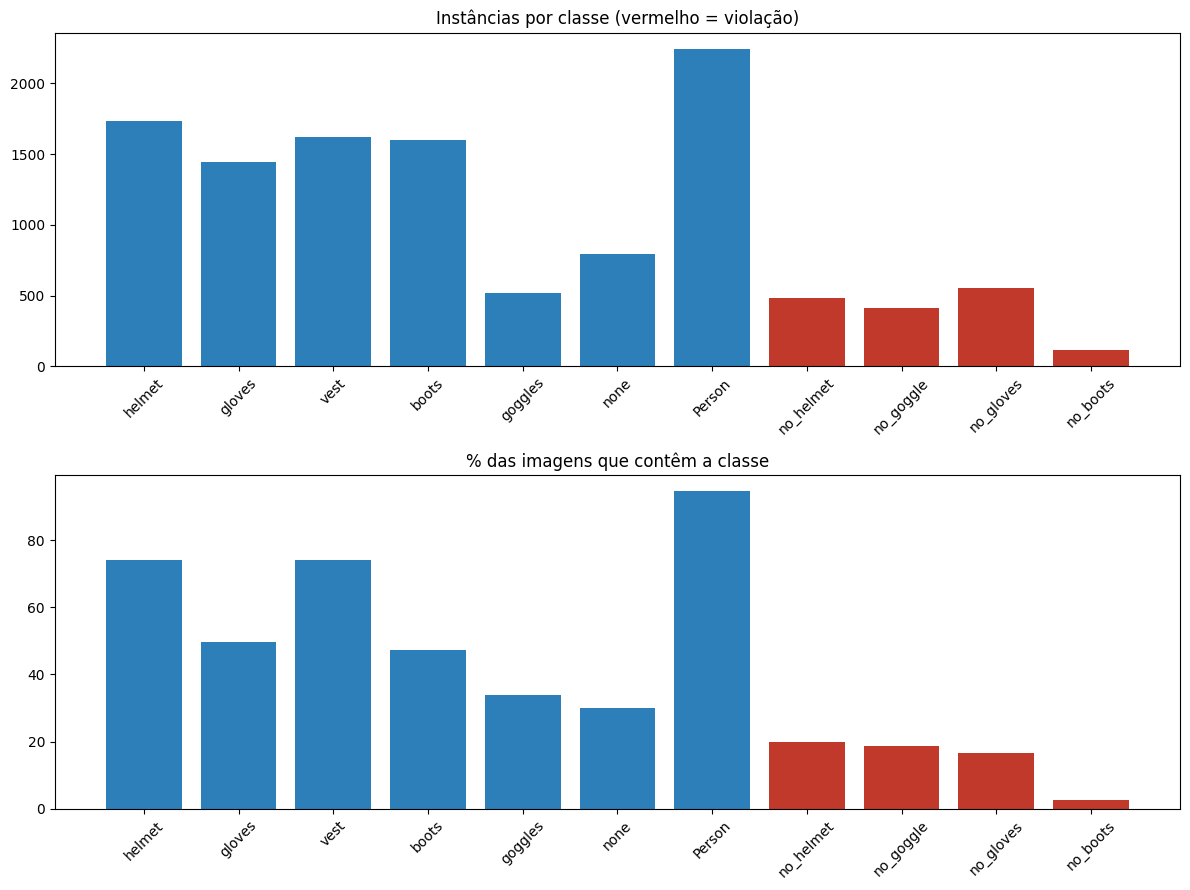


Duplicatas exatas: 0 | quase-duplicatas (dHash <= 4): 318 | pares que cruzam blocos de teste/hold-out: 293
Confira visualmente os primeiros pares (podem ser cenas parecidas, não cópias):


,imagem_a,imagem_b,tipo,dist_hamming,bloco_a,bloco_b,cruza_particao
0,image1002.jpg,image1003.jpg,quase,2,0,8,True
1,image1011.jpg,image1010.jpg,quase,0,5,0,True
2,image102.jpg,image1025.jpg,quase,4,8,-1,True
3,image102.jpg,image1038.jpg,quase,3,8,-1,True
4,image102.jpg,image142.jpg,quase,4,8,-1,True
5,image102.jpg,image24.jpg,quase,4,8,3,True
6,image102.jpg,image279.jpg,quase,4,8,8,False
7,image102.jpg,image376.jpg,quase,3,8,0,True
8,image102.jpg,image42.jpg,quase,4,8,-1,True
9,image102.jpg,image54.jpg,quase,4,8,0,True


Se houver pares que cruzam blocos, cite como ameaça à validade (possível vazamento treino→teste).


In [7]:
# ==== Parte 3b · Descrição dos dados (EDA) e checagem de duplicatas ====
import hashlib
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

NEAR_DUP_MAX_DIST = 4          # distância de Hamming (de 64 bits) para considerar "quase duplicata"
SMALL_BOX_AREA = (32 / 640) ** 2  # caixa menor que 32x32 px numa imagem 640x640 (fração da área)


def _parse_labels(path):
    """Lê um .txt YOLO e devolve tuplas (classe, cx, cy, w, h) normalizadas."""
    rows = []
    if path and os.path.exists(path):
        with open(path) as f:
            for line in f:
                p = line.split()
                if len(p) >= 5:
                    rows.append((int(p[0]),) + tuple(float(v) for v in p[1:5]))
    return rows


def _tipo_da_classe(c):
    if c in VIOLATION_CLASS_IDS:
        return "violação"
    if CLASS_NAMES[c] in ("Person", "none"):
        return "pessoa / genérica"
    return "conformidade"


def build_instances_df():
    part_of = {int(i): "desenvolvimento" for i in dev_idx}
    part_of.update({int(i): "hold-out" for i in holdout_idx})
    inst = []
    for i, (_, lbl_path) in enumerate(all_images):
        for c, cx, cy, w, h in _parse_labels(lbl_path):
            inst.append({"img": i, "cls": c, "area": w * h, "part": part_of.get(i, "?")})
    return pd.DataFrame(inst, columns=["img", "cls", "area", "part"])


def class_summary(inst_df):
    rows = []
    for c, name in enumerate(CLASS_NAMES):
        d = inst_df[inst_df["cls"] == c]
        n_img = d["img"].nunique()
        rows.append({
            "classe": name,
            "tipo": _tipo_da_classe(c),
            "instâncias": len(d),
            "imagens com a classe": n_img,
            "% das imagens": 100 * n_img / len(all_images),
            "área mediana (fração da imagem)": d["area"].median() if len(d) else np.nan,
            "% caixas pequenas (<32px a 640)": 100 * (d["area"] < SMALL_BOX_AREA).mean() if len(d) else np.nan,
        })
    return pd.DataFrame(rows)


def partition_summary(inst_df):
    """Instâncias por classe em desenvolvimento vs. hold-out (a estratificação é só pela presença de
    violação; aqui se vê o quanto cada classe ficou proporcional nas duas partes)."""
    cmp_ = (inst_df.groupby(["cls", "part"]).size().unstack(fill_value=0)
            .reindex(range(len(CLASS_NAMES)), fill_value=0))
    for part in list(cmp_.columns):
        cmp_[f"% {part}"] = 100 * cmp_[part] / max(cmp_[part].sum(), 1)
    cmp_.index = CLASS_NAMES
    return cmp_


def _dhash(path, size=8):
    img = Image.open(path).convert("L").resize((size + 1, size), Image.LANCZOS)
    a = np.asarray(img, dtype=np.int16)
    return np.packbits((a[:, 1:] > a[:, :-1]).flatten())   # 64 bits -> 8 bytes


def find_duplicates(max_dist=NEAR_DUP_MAX_DIST):
    """Duplicatas exatas (MD5) e candidatas a quase-duplicatas (dHash). Retorna DataFrame de pares."""
    md5 = {}
    for i, (p, _) in enumerate(all_images):
        with open(p, "rb") as f:
            md5.setdefault(hashlib.md5(f.read()).hexdigest(), []).append(i)
    pairs = []
    for idxs in md5.values():
        for a in range(len(idxs)):
            for b in range(a + 1, len(idxs)):
                pairs.append((idxs[a], idxs[b], 0, "exata"))

    H = np.stack([_dhash(p) for p, _ in all_images])
    for i in range(len(H) - 1):
        dist = np.unpackbits(np.bitwise_xor(H[i + 1:], H[i]), axis=1).sum(axis=1)
        for j in np.where(dist <= max_dist)[0]:
            jj = i + 1 + int(j)
            if not any(a == i and b == jj for a, b, _, _ in pairs):
                pairs.append((i, jj, int(dist[j]), "quase"))

    # "bloco" = fold de teste (0..K-1) ou hold-out (-1). Par em blocos diferentes => em algum
    # fold um dos dois está no treino e o outro no teste (potencial vazamento).
    block = {int(i): -1 for i in holdout_idx}
    for f, (_, te) in enumerate(folds):
        block.update({int(i): f for i in te})
    rows = [{"imagem_a": os.path.basename(all_images[a][0]), "imagem_b": os.path.basename(all_images[b][0]),
             "tipo": t, "dist_hamming": d, "bloco_a": block.get(a), "bloco_b": block.get(b),
             "cruza_particao": block.get(a) != block.get(b)} for a, b, d, t in pairs]
    return pd.DataFrame(rows, columns=["imagem_a", "imagem_b", "tipo", "dist_hamming", "bloco_a",
                                       "bloco_b", "cruza_particao"])


def plot_class_distribution(cls_df, path):
    colors = ["#c0392b" if t == "violação" else "#2c7fb8" for t in cls_df["tipo"]]
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))   # um gráfico abaixo do outro
    axes[0].bar(cls_df["classe"], cls_df["instâncias"], color=colors)
    axes[0].set_title("Instâncias por classe (vermelho = violação)")
    axes[0].tick_params(axis="x", rotation=45)
    axes[1].bar(cls_df["classe"], cls_df["% das imagens"], color=colors)
    axes[1].set_title("% das imagens que contêm a classe")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()


# ---- execução ----
inst_df = build_instances_df()
cls_df = class_summary(inst_df)
print(f"Imagens na pool: {len(all_images)} | com >=1 violação: {int(y_strat.sum())} "
      f"({100 * y_strat.mean():.1f}%) | sem nenhuma anotação: {len(all_images) - inst_df['img'].nunique()}")
per_img = inst_df.groupby("img").size()
print(f"Caixas por imagem — média {per_img.mean():.1f}, mediana {per_img.median():.0f}, máx {per_img.max()}")
print("Tamanhos de imagem mais comuns (largura, altura):",
      Counter(Image.open(p).size for p, _ in all_images).most_common(6))

print("\nResumo por classe:")
display(cls_df.round(4))
print("\nDesenvolvimento vs. Hold-Out (instâncias e % por parte):")
part_df = partition_summary(inst_df)
display(part_df.round(2))

cls_df.to_csv(f"{PROJECT_DIR}/eda_por_classe.csv", index=False)
part_df.to_csv(f"{PROJECT_DIR}/eda_particoes.csv")
plot_class_distribution(cls_df, f"{PROJECT_DIR}/eda_classes.png")

dups = find_duplicates()
dups.to_csv(f"{PROJECT_DIR}/possiveis_duplicatas.csv", index=False)
n_exact = int((dups["tipo"] == "exata").sum())
n_cross = int(dups["cruza_particao"].sum())
print(f"\nDuplicatas exatas: {n_exact} | quase-duplicatas (dHash <= {NEAR_DUP_MAX_DIST}): "
      f"{int((dups['tipo'] == 'quase').sum())} | pares que cruzam blocos de teste/hold-out: {n_cross}")
if len(dups):
    print("Confira visualmente os primeiros pares (podem ser cenas parecidas, não cópias):")
    display(dups.head(10))
print("Se houver pares que cruzam blocos, cite como ameaça à validade (possível vazamento treino→teste).")

## Parte 3c · Quase-duplicatas (confirmação por correlação) e diagnóstico da divisão

A Parte 3b usa dHash 8×8, que gerou candidatos demais (318 pares; imagens de pouca textura, como a `image102.jpg`, "casam" com dezenas de outras). Esta parte **confirma** os candidatos comparando miniaturas 32×32 por correlação de Pearson (também contra a versão espelhada) e mede o que interessa: **quantas imagens de teste têm uma quase-duplicata no treino** de cada fold e do Hold-Out. Também mostra a prevalência de violação e as instâncias por classe de violação em cada bloco (evidência da estratificação).

Gera `quase_duplicatas_confirmadas.csv`, `vazamento_quase_duplicatas_por_bloco.csv`, `diagnostico_divisao.csv` e a montagem `quase_duplicatas_amostra.png` (**abra e confira visualmente**). A montagem contém pessoas: por padrão é salva, não exibida (`MOSTRAR_FIGURAS_COM_PESSOAS`).

In [8]:
# ==== Parte 3c · Quase-duplicatas (confirmação por correlação) e diagnóstico da divisão ====
# Rodar depois da Parte 3b. Não usa GPU nem modelos.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

THUMB = 32                # miniatura THUMB x THUMB (RGB) usada na comparação
NEAR_DUP_CORR = 0.97      # correlação de Pearson mínima entre miniaturas para chamar de quase-duplicata
N_PAIRS_MONTAGE = 12      # pares mostrados na montagem para conferência visual
# As figuras abaixo contêm pessoas: por padrão são SALVAS em disco, mas não exibidas no notebook
# (assim o .ipynb publicado não carrega rostos). Ponha True para exibir.
MOSTRAR_FIGURAS_COM_PESSOAS = False


def _thumb_vec(path, flip=False):
    img = Image.open(path).convert("RGB").resize((THUMB, THUMB), Image.BILINEAR)
    if flip:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    a = np.asarray(img, dtype=np.float32).reshape(-1)
    a = a - a.mean()
    n = np.linalg.norm(a)
    return a / n if n > 1e-6 else np.zeros_like(a)   # imagem uniforme => vetor nulo => nunca casa


def near_duplicate_pairs(paths, min_corr=NEAR_DUP_CORR):
    """Pares (i, j) cuja miniatura tem correlação >= min_corr (também contra a versão espelhada).
    Mais seletivo que o dHash 8x8 da Parte 3b, que gerou candidatos demais (imagens de pouca textura
    coincidem com dezenas de outras)."""
    X = np.stack([_thumb_vec(p) for p in paths])
    Xf = np.stack([_thumb_vec(p, flip=True) for p in paths])
    C, Cf = X @ X.T, X @ Xf.T
    best, flipped = np.maximum(C, Cf), Cf > C
    iu, ju = np.triu_indices(len(paths), k=1)
    corr_all = best[iu, ju]
    keep = corr_all >= min_corr
    pairs = pd.DataFrame({"i": iu[keep], "j": ju[keep], "corr": corr_all[keep], "espelhada": flipped[iu, ju][keep]})
    sens = {t: int((corr_all >= t).sum()) for t in (0.90, 0.95, 0.97, 0.99)}
    return pairs.sort_values("corr", ascending=False).reset_index(drop=True), sens


def cluster_ids(n, pairs):
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for a, b in zip(pairs["i"], pairs["j"]):
        ra, rb = find(int(a)), find(int(b))
        if ra != rb:
            parent[rb] = ra
    return np.array([find(i) for i in range(n)])


def build_mates(pairs):
    mates = {}
    for a, b in zip(pairs["i"], pairs["j"]):
        mates.setdefault(int(a), set()).add(int(b))
        mates.setdefault(int(b), set()).add(int(a))
    return mates


def leakage_table(mates):
    """Quantas imagens de teste têm quase-duplicata no TREINO daquele fold (e no desenvolvimento, no hold-out)."""
    rows = []
    for f, (tr, te) in enumerate(folds):
        trs = set(map(int, tr))
        n_leak = sum(1 for i in te if mates.get(int(i), set()) & trs)
        rows.append({"bloco de teste": f"fold {f}", "imagens de teste": len(te),
                     "com quase-duplicata no treino": n_leak, "%": 100 * n_leak / len(te)})
    devs = set(map(int, dev_idx))
    n_leak = sum(1 for i in holdout_idx if mates.get(int(i), set()) & devs)
    rows.append({"bloco de teste": "hold-out", "imagens de teste": len(holdout_idx),
                 "com quase-duplicata no treino": n_leak, "%": 100 * n_leak / len(holdout_idx)})
    return pd.DataFrame(rows)


def split_diagnostics(inst):
    """Prevalência de violação e instâncias por classe de violação em cada bloco de teste."""
    blocks = [(f"fold {f}", te) for f, (_, te) in enumerate(folds)] + [("hold-out", holdout_idx),
                                                                        ("desenvolvimento", dev_idx)]
    rows = []
    for name, idx in blocks:
        idx = np.asarray(idx)
        row = {"bloco": name, "imagens": len(idx), "com violação": int(y_strat[idx].sum()),
               "% com violação": 100 * float(y_strat[idx].mean())}
        if inst is not None:
            sub = inst[inst["img"].isin(set(map(int, idx)))]
            for c in sorted(VIOLATION_CLASS_IDS):
                row[f"inst. {CLASS_NAMES[c]}"] = int((sub["cls"] == c).sum())
        rows.append(row)
    return pd.DataFrame(rows)


def save_pairs_montage(pairs, paths, out_path, n=N_PAIRS_MONTAGE):
    top = pairs.head(n)
    if not len(top):
        return None
    cols = 3
    rows_n = int(np.ceil(len(top) / cols))
    fig, axes = plt.subplots(rows_n, cols * 2, figsize=(3.0 * cols * 2, 3.2 * rows_n))
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.axis("off")
    for k, r in top.iterrows():
        rr, cc = divmod(k, cols)
        for side, idx in enumerate((int(r["i"]), int(r["j"]))):
            ax = axes[rr, cc * 2 + side]
            ax.imshow(Image.open(paths[idx]).convert("RGB"))
            ax.set_title(f"{os.path.basename(paths[idx])}\ncorr={r['corr']:.3f}" + (" (espelh.)" if r["espelhada"] else ""),
                         fontsize=7)
    plt.tight_layout()
    plt.savefig(out_path, dpi=110)
    if MOSTRAR_FIGURAS_COM_PESSOAS:
        plt.show()
    else:
        plt.close(fig)
    return out_path


# ---- execução ----
_paths = [p for p, _ in all_images]
NEAR_DUP_PAIRS, _sens = near_duplicate_pairs(_paths)
NEAR_DUP_CLUSTER = cluster_ids(len(_paths), NEAR_DUP_PAIRS)
NEAR_DUP_MATES = build_mates(NEAR_DUP_PAIRS)

print(f"Pares com correlação de miniaturas >= {NEAR_DUP_CORR}: {len(NEAR_DUP_PAIRS)} "
      f"(espelhados: {int(NEAR_DUP_PAIRS['espelhada'].sum())})")
print("Sensibilidade ao limiar (nº de pares):", _sens)
sizes = pd.Series(NEAR_DUP_CLUSTER).value_counts()
n_grouped = int(sizes[sizes >= 2].sum())
print(f"Imagens em grupos de 2+ quase-duplicatas: {n_grouped} ({100 * n_grouped / len(_paths):.1f}% da pool); "
      f"maior grupo: {int(sizes.max())} imagens")

LEAK_DF = leakage_table(NEAR_DUP_MATES)
print("\nVazamento potencial treino → teste (imagens de teste com quase-duplicata no treino):")
display(LEAK_DF.round(1))

DIAG_DF = split_diagnostics(globals().get("inst_df"))
print("\nDiagnóstico da divisão (a estratificação foi pela presença de violação):")
display(DIAG_DF.round(1))

NEAR_DUP_PAIRS.assign(imagem_a=[os.path.basename(_paths[i]) for i in NEAR_DUP_PAIRS["i"]],
                      imagem_b=[os.path.basename(_paths[j]) for j in NEAR_DUP_PAIRS["j"]]) \
    .to_csv(f"{PROJECT_DIR}/quase_duplicatas_confirmadas.csv", index=False)
LEAK_DF.to_csv(f"{PROJECT_DIR}/vazamento_quase_duplicatas_por_bloco.csv", index=False)
DIAG_DF.to_csv(f"{PROJECT_DIR}/diagnostico_divisao.csv", index=False)
out_png = save_pairs_montage(NEAR_DUP_PAIRS, _paths, f"{PROJECT_DIR}/quase_duplicatas_amostra.png")
if out_png:
    print(f"\nMontagem de conferência visual salva em {out_png} (abra e confirme se são mesmo a mesma cena).")
print("Leitura: se a % de teste com quase-duplicata no treino for pequena (ou zero), o risco de vazamento é baixo; "
      "se for alta, cite como ameaça e veja a sensibilidade do hold-out na Parte 9h.")

Pares com correlação de miniaturas >= 0.97: 126 (espelhados: 1)
Sensibilidade ao limiar (nº de pares): {0.9: 1244, 0.95: 290, 0.97: 126, 0.99: 21}
Imagens em grupos de 2+ quase-duplicatas: 168 (11.9% da pool); maior grupo: 7 imagens

Vazamento potencial treino → teste (imagens de teste com quase-duplicata no treino):


,bloco de teste,imagens de teste,com quase-duplicata no treino,%
0,fold 0,114,15,13.2
1,fold 1,114,8,7.0
2,fold 2,113,9,8.0
3,fold 3,113,8,7.1
4,fold 4,113,12,10.6
5,fold 5,113,8,7.1
6,fold 6,113,10,8.8
7,fold 7,113,8,7.1
8,fold 8,113,16,14.2
9,fold 9,113,7,6.2



Diagnóstico da divisão (a estratificação foi pela presença de violação):


,bloco,imagens,com violação,% com violação,inst. no_helmet,inst. no_goggle,inst. no_gloves,inst. no_boots
0,fold 0,114,24,21.1,43,37,40,6
1,fold 1,114,24,21.1,35,26,49,15
2,fold 2,113,23,20.4,40,39,49,5
3,fold 3,113,23,20.4,43,40,60,4
4,fold 4,113,23,20.4,36,27,34,2
5,fold 5,113,23,20.4,30,25,33,6
6,fold 6,113,23,20.4,33,29,36,11
7,fold 7,113,24,21.2,54,37,63,24
8,fold 8,113,24,21.2,46,37,60,23
9,fold 9,113,24,21.2,32,29,40,7



Montagem de conferência visual salva em /content/drive/MyDrive/epi_experimento/quase_duplicatas_amostra.png (abra e confirme se são mesmo a mesma cena).
Leitura: se a % de teste com quase-duplicata no treino for pequena (ou zero), o risco de vazamento é baixo; se for alta, cite como ameaça e veja a sensibilidade do hold-out na Parte 9h.


## Parte 4 · Funções utilitárias comuns (anotações, dataset, avaliação, FPS)

Estas funções são usadas por **ambos** os modelos, para garantir que a avaliação seja idêntica.

In [9]:
import cv2
from PIL import Image

def read_yolo_labels(label_path, img_w, img_h):
    """Lê um .txt YOLO e retorna boxes absolutos [x1,y1,x2,y2] e labels (0-based, id do Construction-PPE)."""
    boxes, labels = [], []
    if label_path is None or not os.path.exists(label_path):
        return boxes, labels
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            cls_id = int(parts[0])
            cx, cy, w, h = map(float, parts[1:5])
            x1 = (cx - w / 2) * img_w
            y1 = (cy - h / 2) * img_h
            x2 = (cx + w / 2) * img_w
            y2 = (cy + h / 2) * img_h
            boxes.append([x1, y1, x2, y2])
            labels.append(cls_id)
    return boxes, labels

In [10]:
import torch
from torch.utils.data import Dataset

class PPEDetectionDataset(Dataset):
    """Dataset genérico usado para treinar modelos torchvision (SSD).
    Labels do YOLO (0-based) são deslocados +1 porque o torchvision reserva a classe 0 para 'background'.
    `transforms`, se fornecido, recebe (img_tensor, target) e retorna (img_tensor, target) — usado para
    aplicar a augmentation simétrica definida na Parte 4b.
    """
    def __init__(self, samples, transforms=None):
        self.samples = samples  # lista de (img_path, label_path)
        self.transforms = transforms

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        boxes, labels = read_yolo_labels(label_path, w, h)

        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor([l + 1 for l in labels], dtype=torch.int64)  # +1: reserva 0 p/ background

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
        }

        img_t = torch.as_tensor(np.array(img)).permute(2, 0, 1).float() / 255.0

        if self.transforms:
            img_t, target = self.transforms(img_t, target)

        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

## Parte 4b · Augmentation simétrica para o SSD-Lite (reduz a assimetria com o YOLOv8)



Esta célula adiciona ao SSD-Lite: **flip horizontal (p=0,5)** com ajuste correspondente das
bounding boxes, e **jitter de cor** (brilho/contraste/saturação), aplicados apenas ao conjunto de
treino. Isso não replica o Mosaic do YOLO (que combina 4 imagens/anotações diferentes em um único
mosaico — uma reimplementação própria seria um projeto à parte), mas cobre as duas transformações
mais citadas na literatura de detecção como responsáveis pela maior parte do ganho de robustez do
augmentation, reduzindo (embora não eliminando por completo) a assimetria. O que resta de assimetria
é registrado explicitamente na Seção 4.3 do TCC (Ameaças à Validade — Validade Interna).

In [11]:
import random
from torchvision.transforms import functional as TF

def ssd_train_augment(img_t, target, hflip_p=0.5,
                       brightness_delta=0.15, contrast_delta=0.15, saturation_delta=0.10):
    """Augmentation leve e simétrica em espírito à do YOLOv8 (flip + jitter de cor), aplicada
    apenas nas amostras de treino do SSD-Lite. Ajusta as boxes corretamente no flip horizontal.
    """
    _, h, w = img_t.shape
    boxes = target["boxes"]

    if random.random() < hflip_p:
        img_t = torch.flip(img_t, dims=[2])  # flip no eixo da largura
        if boxes.shape[0] > 0:
            boxes = boxes.clone()
            x1 = boxes[:, 0].clone()
            x2 = boxes[:, 2].clone()
            boxes[:, 0] = w - x2
            boxes[:, 2] = w - x1
            target = dict(target)
            target["boxes"] = boxes

    # Jitter de cor — não afeta as coordenadas das boxes
    img_t = TF.adjust_brightness(img_t, 1.0 + random.uniform(-brightness_delta, brightness_delta))
    img_t = TF.adjust_contrast(img_t, 1.0 + random.uniform(-contrast_delta, contrast_delta))
    img_t = TF.adjust_saturation(img_t, 1.0 + random.uniform(-saturation_delta, saturation_delta))
    img_t = torch.clamp(img_t, 0.0, 1.0)

    return img_t, target

In [12]:
def box_iou(boxA, boxB):
    """IoU entre dois boxes [x1,y1,x2,y2] (aceita listas, tensores ou arrays)."""
    ax1, ay1, ax2, ay2 = [float(v) for v in boxA]
    bx1, by1, bx2, by2 = [float(v) for v in boxB]
    xA, yA = max(ax1, bx1), max(ay1, by1)
    xB, yB = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, xB - xA) * max(0.0, yB - yA)
    areaA = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    areaB = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def build_gt_dict(label_path, img_w, img_h, device="cpu"):
    boxes, labels = read_yolo_labels(label_path, img_w, img_h)
    if len(boxes) == 0:
        return {"boxes": torch.zeros((0, 4)).to(device), "labels": torch.zeros((0,), dtype=torch.int64).to(device)}
    return {
        "boxes": torch.as_tensor(boxes, dtype=torch.float32).to(device),
        "labels": torch.as_tensor(labels, dtype=torch.int64).to(device),  # 0-based, id do Construction-PPE
    }


def compute_precision_recall_f1(preds_per_image, gts_per_image, iou_thr=0.5, conf_thr=0.25):
    """Precision, Recall e F1-score globais via correspondência gulosa por IoU, no limiar de
    confiança fixo `conf_thr`. Substitui a antiga `compute_f1` (que só retornava o F1) — agora
    Precision e Recall ficam disponíveis isoladamente por modelo/fold, o que a v1 não permitia.
    """
    tp = fp = fn = 0
    for preds, gt in zip(preds_per_image, gts_per_image):
        p_boxes = preds["boxes"][preds["scores"] >= conf_thr]
        p_labels = preds["labels"][preds["scores"] >= conf_thr]
        g_boxes = gt["boxes"]
        g_labels = gt["labels"]
        matched_gt = set()
        for pb, pl in zip(p_boxes, p_labels):
            best_iou, best_j = 0.0, -1
            for j, (gb, gl) in enumerate(zip(g_boxes, g_labels)):
                if j in matched_gt or gl.item() != pl.item():
                    continue
                iou = box_iou(pb, gb)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= iou_thr:
                tp += 1
                matched_gt.add(best_j)
            else:
                fp += 1
        fn += len(g_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}

In [13]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import time

def evaluate_map50(preds_per_image, gts_per_image):
    """mAP@0.5 via torchmetrics — mesma chamada usada para os dois modelos."""
    metric = MeanAveragePrecision(iou_thresholds=[0.5], box_format="xyxy")
    metric.update(preds_per_image, gts_per_image)
    result = metric.compute()
    return float(result["map"])


def measure_fps_yolo(model, image_paths, warmup=5, n=None, imgsz=640):
    """FPS de inferência 'alto nível' (API do Ultralytics: inclui pré/pós-processamento e NMS) —
    imagem a imagem, sem batching, como em uso real. `imgsz` permite medir também a uma resolução
    equivalente à do SSDLite (320), para uma comparação de FPS mais controlada (ver Parte 5).
    """
    n = n or len(image_paths)
    for p in image_paths[:warmup]:
        model.predict(source=p, imgsz=imgsz, verbose=False)
    t0 = time.time()
    for p in image_paths[:n]:
        model.predict(source=p, imgsz=imgsz, verbose=False)
    elapsed = time.time() - t0
    return n / elapsed if elapsed > 0 else 0.0


def measure_fps_yolo_raw(yolo_wrapper, image_paths, device, warmup=5, n=None, imgsz=640):
    """FPS de inferência 'baixo nível': chama diretamente o forward do nn.Module interno do
    YOLOv8 (bypassa pré-processamento/NMS/logging de alto nível do Ultralytics), no mesmo estilo
    de laço manual usado em `measure_fps_torchvision` para o SSD-Lite. Não é uma medição
    perfeitamente equivalente (o forward do SSD do torchvision já inclui NMS internamente, o do
    YOLO aqui não), mas fornece um segundo ponto de referência que ajuda a delimitar o quanto da
    diferença de FPS observada é overhead de framework vs. diferença arquitetural real — ver
    Seção 4.3 (Ameaças à Validade — Validade de Construto) do TCC.
    """
    net = yolo_wrapper.model.to(device).eval()
    n = n or len(image_paths)
    imgs = []
    for p in image_paths[:n]:
        img = Image.open(p).convert("RGB").resize((imgsz, imgsz))
        t = torch.as_tensor(np.array(img)).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
        imgs.append(t)

    with torch.no_grad():
        for t in imgs[:warmup]:
            _ = net(t)
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for t in imgs:
            _ = net(t)
        if device == "cuda":
            torch.cuda.synchronize()
    elapsed = time.time() - t0
    return len(imgs) / elapsed if elapsed > 0 else 0.0


def measure_fps_torchvision(model, image_paths, device, warmup=5, n=None):
    """FPS de inferência para modelos torchvision (SSD) — mesma filosofia da função acima.
    Nota de validade de construto: o forward() de um modelo de detecção do torchvision já inclui
    a decodificação de âncoras e o NMS internamente (não há uma etapa de pós-processamento
    separada como no Ultralytics), então este número já é, por construção, mais parecido com o
    `measure_fps_yolo` (alto nível) do que com o `measure_fps_yolo_raw` (baixo nível).
    """
    model.eval()
    n = n or len(image_paths)
    imgs = []
    for p in image_paths[:n]:
        img = Image.open(p).convert("RGB")
        img_t = torch.as_tensor(np.array(img)).permute(2, 0, 1).float().to(device) / 255.0
        imgs.append(img_t)

    with torch.no_grad():
        for img_t in imgs[:warmup]:
            _ = model([img_t])
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for img_t in imgs:
            _ = model([img_t])
        if device == "cuda":
            torch.cuda.synchronize()
    elapsed = time.time() - t0
    return len(imgs) / elapsed if elapsed > 0 else 0.0

## Parte 5 · Função de treino + avaliação — YOLOv8

In [14]:
import yaml as pyyaml
import shutil

def materialize_yolo_fold(fold_id, train_idx, test_idx, samples, name_prefix="fold"):
    """Cria uma pasta com estrutura YOLO (train/val) apontando (via symlink) para as imagens do fold."""
    fold_dir = f"/content/{name_prefix}_{fold_id}_yolo"
    if os.path.exists(fold_dir):
        shutil.rmtree(fold_dir)
    for split, idxs in [("train", train_idx), ("val", test_idx)]:
        os.makedirs(f"{fold_dir}/images/{split}", exist_ok=True)
        os.makedirs(f"{fold_dir}/labels/{split}", exist_ok=True)
        for i in idxs:
            img_path, lbl_path = samples[i]
            img_name = os.path.basename(img_path)
            stem = os.path.splitext(img_name)[0]
            os.symlink(os.path.abspath(img_path), f"{fold_dir}/images/{split}/{img_name}")
            if lbl_path and os.path.exists(lbl_path):
                os.symlink(os.path.abspath(lbl_path), f"{fold_dir}/labels/{split}/{stem}.txt")
            else:
                open(f"{fold_dir}/labels/{split}/{stem}.txt", "w").close()  # imagem sem objetos

    yaml_path = f"{fold_dir}/data.yaml"
    with open(yaml_path, "w") as f:
        pyyaml.dump({
            "path": fold_dir,
            "train": "images/train",
            "val": "images/val",
            "nc": NUM_CLASSES_YOLO,
            "names": CLASS_NAMES,
        }, f)
    return yaml_path, fold_dir


def train_and_eval_yolo(fold_id, train_idx, test_idx, epochs=30, name_prefix="fold"):
    from ultralytics import YOLO

    yaml_path, fold_dir = materialize_yolo_fold(fold_id, train_idx, test_idx, all_images, name_prefix=name_prefix)
    device = 0 if torch.cuda.is_available() else "cpu"
    device_str = "cuda" if torch.cuda.is_available() else "cpu"

    model = YOLO("yolov8n.pt")

    t0 = time.time()
    model.train(
        data=yaml_path,
        epochs=epochs,
        imgsz=640,
        batch=16,
        device=device,
        project=f"{PROJECT_DIR}/runs_yolo",
        name=f"{name_prefix}_{fold_id}",
        exist_ok=True,
        verbose=False,
    )
    train_time_s = time.time() - t0

    best_weights = f"{PROJECT_DIR}/runs_yolo/{name_prefix}_{fold_id}/weights/best.pt"
    eval_model = YOLO(best_weights)

    test_samples = [all_images[i] for i in test_idx]
    image_paths = [s[0] for s in test_samples]
    label_paths = [s[1] for s in test_samples]

    # Predições com conf baixo (0.001) para permitir o cálculo correto do mAP;
    # Precision/Recall/F1 usam seu próprio limiar fixo (0.25) dentro de compute_precision_recall_f1.
    preds_per_image, gts_per_image = [], []
    for img_path, lbl_path in zip(image_paths, label_paths):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        result = eval_model.predict(source=img_path, conf=0.001, iou=0.6, verbose=False)[0]
        preds_per_image.append({
            "boxes": result.boxes.xyxy.cpu(),
            "scores": result.boxes.conf.cpu(),
            "labels": result.boxes.cls.cpu().long(),
        })
        gts_per_image.append(build_gt_dict(lbl_path, w, h, device="cpu"))

    map50 = evaluate_map50(preds_per_image, gts_per_image)
    prf = compute_precision_recall_f1(preds_per_image, gts_per_image)

    n_fps_sample = min(30, len(image_paths))
    fps_640 = measure_fps_yolo(eval_model, image_paths[:n_fps_sample], imgsz=640)
    fps_320 = measure_fps_yolo(eval_model, image_paths[:n_fps_sample], imgsz=320)
    fps_raw_640 = measure_fps_yolo_raw(eval_model, image_paths[:n_fps_sample], device_str, imgsz=640)

    return {
        "model": "YOLOv8",
        "fold": fold_id,
        "map50": map50,
        "precision": prf["precision"],
        "recall": prf["recall"],
        "f1": prf["f1"],
        "tp": prf["tp"],
        "fp": prf["fp"],
        "fn": prf["fn"],
        "fps": fps_640,            # mantém o nome original ("fps") para compatibilidade retroativa
        "fps_320_matched": fps_320,  # ponto de comparação controlado com a resolução nativa do SSDLite
        "fps_raw_forward": fps_raw_640,  # medição de baixo nível (ver measure_fps_yolo_raw)
        "train_time_s": train_time_s,
    }

## Parte 6 · Função de treino + avaliação — SSD MobileNetV3 (SSDLite320)

In [15]:
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torch.utils.data import DataLoader


def build_ssd(num_classes_with_bg):
    """SSDLite320 com backbone MobileNetV3-Large pré-treinado na ImageNet.
    `num_classes` já reconstrói a cabeça de classificação para o número de classes do problema
    (mesma convenção do torchvision: classe 0 = background). A resolução de entrada (320x320) é
    fixa no design desta arquitetura (SSDLite320) — não é um parâmetro livre, então não é possível
    testá-la nativamente a 640x640 sem redefinir sua grade de âncoras (fora do escopo deste
    notebook; ver nota na introdução e na Seção 4.2/4.3 do TCC).
    """
    model = ssdlite320_mobilenet_v3_large(
        weights=None,
        weights_backbone=MobileNet_V3_Large_Weights.IMAGENET1K_V1,
        num_classes=num_classes_with_bg,
        score_thresh=0.001,  # baixo de propósito: permite calcular o mAP corretamente
    )
    return model


def train_and_eval_ssd(fold_id, train_idx, test_idx, epochs=10, device=None, name_prefix="fold"):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    train_samples = [all_images[i] for i in train_idx]
    test_samples = [all_images[i] for i in test_idx]

    # Augmentation simétrica (Parte 4b) aplicada apenas ao conjunto de treino do SSD-Lite.
    train_ds = PPEDetectionDataset(train_samples, transforms=ssd_train_augment)
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, collate_fn=collate_fn)

    num_classes_with_bg = NUM_CLASSES_YOLO + 1  # +1 = background
    model = build_ssd(num_classes_with_bg).to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 2), gamma=0.1)

    t0 = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for imgs, targets in train_loader:
            imgs = [im.to(device) for im in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        lr_scheduler.step()
        print(f"  [SSD][{name_prefix} {fold_id}] epoch {epoch + 1}/{epochs} — loss médio: {epoch_loss / len(train_loader):.4f}")
    train_time_s = time.time() - t0

    # Salva os pesos em disco (necessário para reutilizar o modelo depois, ex.: Parte 11 de inferência)
    ssd_weights_dir = f"{PROJECT_DIR}/runs_ssd/{name_prefix}_{fold_id}/weights"
    os.makedirs(ssd_weights_dir, exist_ok=True)
    ssd_weights_path = f"{ssd_weights_dir}/best.pt"
    torch.save({
        "state_dict": model.state_dict(),
        "num_classes_with_bg": num_classes_with_bg,
        "class_names": CLASS_NAMES,
    }, ssd_weights_path)
    print(f"  [SSD][{name_prefix} {fold_id}] pesos salvos em: {ssd_weights_path}")

    # --- Avaliação (mesmas funções usadas para o YOLOv8: evaluate_map50 / compute_precision_recall_f1 / FPS) ---
    model.eval()
    preds_per_image, gts_per_image = [], []
    with torch.no_grad():
        for img_path, lbl_path in test_samples:
            img = Image.open(img_path).convert("RGB")
            w, h = img.size
            img_t = torch.as_tensor(np.array(img)).permute(2, 0, 1).float().to(device) / 255.0
            output = model([img_t])[0]

            preds_per_image.append({
                "boxes": output["boxes"].cpu(),
                "scores": output["scores"].cpu(),
                "labels": (output["labels"] - 1).clamp(min=0).cpu(),  # remove o deslocamento de background
            })
            gts_per_image.append(build_gt_dict(lbl_path, w, h, device="cpu"))

    map50 = evaluate_map50(preds_per_image, gts_per_image)
    prf = compute_precision_recall_f1(preds_per_image, gts_per_image)
    fps = measure_fps_torchvision(
        model, [s[0] for s in test_samples[: min(30, len(test_samples))]], device
    )

    return {
        "model": "SSD MobileNetV3",
        "fold": fold_id,
        "map50": map50,
        "precision": prf["precision"],
        "recall": prf["recall"],
        "f1": prf["f1"],
        "tp": prf["tp"],
        "fp": prf["fp"],
        "fn": prf["fn"],
        "fps": fps,
        "fps_320_matched": fps,   # o SSDLite320 já roda nativamente a 320x320 (ver build_ssd)
        "fps_raw_forward": fps,   # forward() do torchvision já inclui decodificação+NMS (ver measure_fps_torchvision)
        "train_time_s": train_time_s,
    }

## Parte 6b · Terceira abordagem — Ensemble YOLOv8 + SSD MobileNetV3 (Weighted Boxes Fusion)

Além de avaliar cada detector isoladamente, avaliamos a **combinação dos dois**. O ensemble funde as
predições do YOLOv8 e do SSD MobileNetV3 para a mesma imagem usando **Weighted Boxes Fusion (WBF)**
(Solovyev et al., 2021), técnica padrão para combinar detectores: em vez de descartar caixas
sobrepostas (como faz o NMS), o WBF agrupa as caixas da **mesma classe** com IoU ≥ `ENSEMBLE_IOU_THR`
e calcula uma caixa média, ponderada pela confiança.

**Como a confiança fundida é calculada (importante para interpretar os resultados):**
- Caixa detectada pelos **dois** modelos → confiança = média ponderada das duas confianças.
- Caixa detectada por **apenas um** modelo → confiança multiplicada por `peso_do_modelo / soma_dos_pesos`
  (com pesos `[1, 1]`, cai pela metade). O ensemble se comporta como um "voto de consenso".
- Consequência: no limiar fixo de 0,25 usado para Precision/Recall/F1, uma caixa vista por um só modelo
  precisa ter confiança ≥ 0,50 para sobreviver. Isso tende a **subir a Precision e reduzir o Recall**
  em relação ao melhor modelo isolado. O mAP@0.5 não depende desse limiar.

**Desenho experimental:**
- **Nenhum re-treino.** Em cada fold, o ensemble usa os pesos do YOLOv8 e do SSD **daquele mesmo fold**
  (já salvos em `runs_yolo/` e `runs_ssd/`) e roda só inferência + fusão no mesmo fold de teste. Mesmos
  folds, mesmo Hold-Out e as mesmas funções de métrica (`evaluate_map50`, `compute_precision_recall_f1`)
  das outras duas abordagens.
- Os hiperparâmetros (`ENSEMBLE_WEIGHTS`, `ENSEMBLE_IOU_THR`, ...) são **fixados a priori**. Como o SSD tende
  a ser bem mais fraco que o YOLOv8 neste experimento, pesos iguais são uma escolha neutra, não
  necessariamente a melhor. Se quiser ajustá-los, faça-o **nos folds de validação cruzada, nunca no
  Hold-Out** — caso contrário o Hold-Out deixa de ser uma avaliação independente.
- **FPS do ensemble** = pipeline completo e sequencial (YOLOv8 → SSD → fusão). O custo é, aproximadamente, a
  soma dos dois modelos mais a fusão. Para comparar os três FPS sob o mesmo hardware, veja a Parte 10.
- **Tempo de treino** do ensemble = soma dos tempos de treino dos dois modelos (é preciso treinar ambos).
- As colunas `fps_320_matched` e `fps_raw_forward` **não se aplicam** ao ensemble e ficam vazias (NaN).


In [16]:
# ==== Parte 6b · Ensemble YOLOv8 + SSD MobileNetV3 (Weighted Boxes Fusion) ====
import glob
import os
import subprocess
import sys
import time

import numpy as np
import pandas as pd
import torch
from PIL import Image

try:
    from ensemble_boxes import weighted_boxes_fusion
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ensemble-boxes"])
    from ensemble_boxes import weighted_boxes_fusion

# --- Nomes canônicos das três abordagens (usados nos CSVs, testes estatísticos e gráficos) ---
YOLO_NAME = "YOLOv8"
SSD_NAME = "SSD MobileNetV3"
ENSEMBLE_NAME = "Ensemble (YOLOv8 + SSD)"
MODEL_ORDER = [YOLO_NAME, SSD_NAME, ENSEMBLE_NAME]

# --- Hiperparâmetros do ensemble (fixados a priori — NÃO ajuste olhando o Hold-Out) ---
ENSEMBLE_WEIGHTS = [1, 1]       # [peso do YOLOv8, peso do SSD]
ENSEMBLE_IOU_THR = 0.55         # IoU mínimo entre caixas da mesma classe para serem fundidas
ENSEMBLE_SKIP_BOX_THR = 0.001   # descarta caixas abaixo desta confiança antes da fusão (mesmo piso usado no mAP)
ENSEMBLE_CONF_TYPE = "avg"      # forma de combinar as confianças: "avg" (padrão do WBF) ou "max"


# ---------------------------------------------------------------------------------------------
# Predições "cruas" de cada modelo (mesmos limiares usados na avaliação das Partes 5 e 6)
# ---------------------------------------------------------------------------------------------
def yolo_predict_raw(yolo_model, source, conf=0.001, iou=0.6):
    """Predições do YOLOv8 em pixels absolutos, com o mesmo conf/iou da avaliação (Parte 5).
    `source`: caminho da imagem ou array BGR (formato do OpenCV)."""
    result = yolo_model.predict(source=source, conf=conf, iou=iou, verbose=False)[0]
    return {
        "boxes": result.boxes.xyxy.cpu(),
        "scores": result.boxes.conf.cpu(),
        "labels": result.boxes.cls.cpu().long(),
    }


def ssd_predict_raw(ssd_model, img_rgb, device):
    """Predições do SSD em pixels absolutos (labels 0-based, sem o deslocamento de background),
    mesmo formato da avaliação da Parte 6. `img_rgb`: array HxWx3 uint8 em RGB."""
    img_t = torch.as_tensor(np.ascontiguousarray(img_rgb)).permute(2, 0, 1).float().to(device) / 255.0
    with torch.no_grad():
        output = ssd_model([img_t])[0]
    return {
        "boxes": output["boxes"].cpu(),
        "scores": output["scores"].cpu(),
        "labels": (output["labels"] - 1).clamp(min=0).cpu(),
    }


# ---------------------------------------------------------------------------------------------
# Fusão (WBF) e pipeline do ensemble
# ---------------------------------------------------------------------------------------------
def fuse_predictions(pred_list, img_w, img_h, weights=None, iou_thr=None, skip_box_thr=None, conf_type=None):
    """Funde as predições de vários modelos (lista de dicts boxes/scores/labels em pixels) com WBF.
    O WBF trabalha com coordenadas normalizadas em [0, 1], então normalizamos antes e
    desnormalizamos depois. Retorna um dict no mesmo formato das predições individuais, pronto para
    `evaluate_map50` e `compute_precision_recall_f1`."""
    weights = ENSEMBLE_WEIGHTS if weights is None else weights
    iou_thr = ENSEMBLE_IOU_THR if iou_thr is None else iou_thr
    skip_box_thr = ENSEMBLE_SKIP_BOX_THR if skip_box_thr is None else skip_box_thr
    conf_type = ENSEMBLE_CONF_TYPE if conf_type is None else conf_type

    scale = np.array([img_w, img_h, img_w, img_h], dtype=np.float32)
    boxes_list, scores_list, labels_list = [], [], []
    for p in pred_list:
        b = p["boxes"].numpy().astype(np.float32).reshape(-1, 4) / scale
        boxes_list.append(np.clip(b, 0.0, 1.0))
        scores_list.append(p["scores"].numpy().astype(np.float32))
        labels_list.append(p["labels"].numpy().astype(np.int64))

    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        weights=weights, iou_thr=iou_thr, skip_box_thr=skip_box_thr, conf_type=conf_type,
    )
    return {
        "boxes": torch.as_tensor(boxes * scale, dtype=torch.float32).reshape(-1, 4),
        "scores": torch.as_tensor(scores, dtype=torch.float32),
        "labels": torch.as_tensor(labels, dtype=torch.int64),  # o WBF devolve labels em float
    }


def ensemble_predict(yolo_model, ssd_model, yolo_source, img_rgb, device):
    """Pipeline completo do ensemble para UMA imagem: YOLOv8 + SSD + fusão WBF.
    `yolo_source`: caminho da imagem ou array BGR; `img_rgb`: a mesma imagem em RGB (para o SSD)."""
    h, w = img_rgb.shape[:2]
    p_yolo = yolo_predict_raw(yolo_model, yolo_source)
    p_ssd = ssd_predict_raw(ssd_model, img_rgb, device)
    return fuse_predictions([p_yolo, p_ssd], w, h)


# ---------------------------------------------------------------------------------------------
# Carregamento de pesos já treinados
# ---------------------------------------------------------------------------------------------
def find_best_weights(runs_dir):
    """Prioriza o modelo final treinado em todo o conjunto de desenvolvimento e avaliado no
    Hold-Out (`holdout_-1`, Parte 7b); se não existir, usa o primeiro fold encontrado."""
    holdout_path = f"{runs_dir}/holdout_-1/weights/best.pt"
    if os.path.exists(holdout_path):
        return holdout_path
    candidates = sorted(glob.glob(f"{runs_dir}/*/weights/best.pt"))
    return candidates[0] if candidates else None


def load_yolo_from_weights(path):
    from ultralytics import YOLO
    return YOLO(path)


def load_ssd_from_weights(path, device):
    checkpoint = torch.load(path, map_location=device)
    model = build_ssd(checkpoint["num_classes_with_bg"]).to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model


# ---------------------------------------------------------------------------------------------
# FPS e avaliação do ensemble
# ---------------------------------------------------------------------------------------------
def measure_fps_ensemble(yolo_model, ssd_model, image_paths, device, warmup=5, n=None):
    """FPS do pipeline COMPLETO do ensemble (YOLOv8 + SSD + fusão WBF), imagem a imagem, sem batching e
    de forma sequencial (os dois modelos NÃO rodam em paralelo). As imagens são lidas do disco antes
    da medição (a leitura não entra no tempo). Usa o mesmo pipeline da avaliação (caixas de baixa
    confiança incluídas na fusão), portanto é uma estimativa conservadora: elevar
    `ENSEMBLE_SKIP_BOX_THR` reduz o custo da fusão."""
    n = n or len(image_paths)
    rgb_imgs = [np.array(Image.open(p).convert("RGB")) for p in image_paths[:n]]
    bgr_imgs = [im[:, :, ::-1].copy() for im in rgb_imgs]  # YOLO espera BGR quando recebe um array

    for rgb, bgr in list(zip(rgb_imgs, bgr_imgs))[:warmup]:
        ensemble_predict(yolo_model, ssd_model, bgr, rgb, device)
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for rgb, bgr in zip(rgb_imgs, bgr_imgs):
        ensemble_predict(yolo_model, ssd_model, bgr, rgb, device)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    return len(rgb_imgs) / elapsed if elapsed > 0 else 0.0


def sum_component_train_time(df, fold_id):
    """Tempo de treino do ensemble = tempo do YOLOv8 + tempo do SSD no mesmo fold."""
    t = df[(df["fold"] == fold_id) & (df["model"].isin([YOLO_NAME, SSD_NAME]))]["train_time_s"]
    return float(t.sum()) if len(t) == 2 else np.nan


def eval_ensemble(fold_id, test_idx, name_prefix="fold"):
    """Avalia o ensemble em `test_idx` reutilizando os pesos já treinados do YOLOv8 e do SSD do mesmo
    fold (ou do treino final do Hold-Out, com name_prefix='holdout' e fold_id=-1). NÃO re-treina.
    Retorna uma linha no mesmo esquema de RESULT_COLUMNS (ou None se faltarem pesos)."""
    yolo_w = f"{PROJECT_DIR}/runs_yolo/{name_prefix}_{fold_id}/weights/best.pt"
    ssd_w = f"{PROJECT_DIR}/runs_ssd/{name_prefix}_{fold_id}/weights/best.pt"
    missing = [p for p in (yolo_w, ssd_w) if not os.path.exists(p)]
    if missing:
        print(f"  [AVISO] Ensemble {name_prefix} {fold_id}: pesos não encontrados ({missing}) — "
              f"treine YOLOv8 e SSD deste fold antes (Partes 7/7b).")
        return None

    device = "cuda" if torch.cuda.is_available() else "cpu"
    yolo_model = load_yolo_from_weights(yolo_w)
    ssd_model = load_ssd_from_weights(ssd_w, device)

    test_samples = [all_images[i] for i in test_idx]
    preds_per_image, gts_per_image = [], []
    for img_path, lbl_path in test_samples:
        img_rgb = np.array(Image.open(img_path).convert("RGB"))
        h, w = img_rgb.shape[:2]
        preds_per_image.append(ensemble_predict(yolo_model, ssd_model, img_path, img_rgb, device))
        gts_per_image.append(build_gt_dict(lbl_path, w, h, device="cpu"))

    map50 = evaluate_map50(preds_per_image, gts_per_image)
    prf = compute_precision_recall_f1(preds_per_image, gts_per_image)
    fps = measure_fps_ensemble(yolo_model, ssd_model, [s[0] for s in test_samples[: min(30, len(test_samples))]], device)
    print(f"  [Ensemble][{name_prefix} {fold_id}] mAP@0.5={map50:.4f} | P={prf['precision']:.3f} "
          f"R={prf['recall']:.3f} F1={prf['f1']:.3f} | FPS={fps:.1f} ({device})")

    del yolo_model, ssd_model
    if device == "cuda":
        torch.cuda.empty_cache()

    return {
        "model": ENSEMBLE_NAME,
        "fold": fold_id,
        "map50": map50,
        "precision": prf["precision"],
        "recall": prf["recall"],
        "f1": prf["f1"],
        "tp": prf["tp"],
        "fp": prf["fp"],
        "fn": prf["fn"],
        "fps": fps,
        "fps_320_matched": np.nan,   # não se aplica: o ensemble avaliado usa o YOLOv8 a 640
        "fps_raw_forward": np.nan,   # não se aplica: a fusão exige as caixas já decodificadas (com NMS)
        "train_time_s": np.nan,      # preenchido pelo chamador (soma dos tempos dos dois modelos)
    }


## Parte 6c · Trava de integridade da partição (anti-contaminação dos resultados)

**Por que existe:** o loop resumível da Parte 7 pula o que já está no CSV, identificando as linhas apenas por
*modelo + fold*. Se `K` (ou a semente, ou o Hold-Out) mudar entre duas execuções, linhas de uma partição antiga
passam a ser tratadas como se fossem da nova — e o Ensemble pode acabar combinando pesos treinados numa partição
com imagens de teste de outra (**vazamento de dados**). Foi exatamente o que aconteceu ao passar de K=5 para K=10.

**O que esta célula faz:**
1. Calcula a **impressão digital** de cada fold (hash dos nomes das imagens de teste + das de Hold-Out) e o
   **nº de caixas do gabarito** de cada conjunto de teste (`tp + fn` de qualquer linha válida tem de ser igual a ele).
2. Define `audit_results`, chamada automaticamente no início das Partes 7 e 7b:
   - linha **com `split_id`** → válida só se for igual à impressão digital atual;
   - linha **legada (sem `split_id`)** → válida só se `tp + fn` bater com o gabarito do teste atual; se bater, é carimbada;
   - se **qualquer** linha de um fold é inválida, o **fold inteiro** (as 3 abordagens) é descartado — o Ensemble depende
     dos pesos dos dois modelos — e os pesos desse fold vão para `backup_particao_antiga/` (o CSV antigo também é copiado);
   - os folds descartados são refeitos pelo loop normalmente.
3. Define `verify_cv_integrity` / `assert_cv_integrity`, usadas na Parte 7d, na Parte 8 e na Parte 9: a análise
   estatística **se recusa a rodar** com dados de partições misturadas.

Executar esta célula não apaga nada; a limpeza só acontece quando a Parte 7/7b chama `audit_results`.


In [17]:
# ==== Parte 6c · Trava de integridade da partição ====
import hashlib
import os
import shutil
import time

import numpy as np
import pandas as pd
from PIL import Image

BACKUP_DIR = f"{PROJECT_DIR}/backup_particao_antiga"


def _image_names(idx):
    return sorted(os.path.basename(all_images[i][0]) for i in idx)


def split_fingerprint(test_idx, holdout_idx_):
    """Impressão digital da partição: hash dos nomes das imagens de teste + das imagens de Hold-Out.
    Muda se K, RANDOM_STATE, o conjunto de imagens ou o Hold-Out mudarem (o treino é o complemento)."""
    h = hashlib.sha1()
    h.update("|".join(_image_names(test_idx)).encode())
    h.update(b"#holdout#")
    h.update("|".join(_image_names(holdout_idx_)).encode())
    return h.hexdigest()[:12]


def count_gt_boxes(idx):
    """Nº de caixas do gabarito nas imagens `idx`, lido com a MESMA função usada na avaliação.
    Numa linha válida, tp + fn é exatamente este número."""
    total = 0
    for i in idx:
        img_path, lbl_path = all_images[i]
        w, h = Image.open(img_path).size
        boxes, _ = read_yolo_labels(lbl_path, w, h)
        total += len(boxes)
    return total


FOLD_SPLIT_IDS = {f: split_fingerprint(te, holdout_idx) for f, (_, te) in enumerate(folds)}
FOLD_GT_COUNTS = {f: count_gt_boxes(te) for f, (_, te) in enumerate(folds)}
HOLDOUT_SPLIT_ID = split_fingerprint(holdout_idx, holdout_idx)
HOLDOUT_GT_COUNT = count_gt_boxes(holdout_idx)
print(f"Partição atual: K={len(folds)} folds | Hold-Out={len(holdout_idx)} imagens")
print("Nº de caixas do gabarito por fold de teste:", FOLD_GT_COUNTS)


def audit_results(df, split_ids, gt_counts, csv_path, weights_prefix="fold"):
    """Descarta de `df` (e do CSV) as linhas que não pertencem à partição atual — ver a explicação
    da Parte 6c. `weights_prefix`: 'fold' (validação cruzada) ou 'holdout'."""
    if df is None or len(df) == 0:
        return df
    df = df.copy()
    if "split_id" not in df.columns:
        df["split_id"] = None
    df["split_id"] = df["split_id"].astype(object)

    reasons, stamped_folds = {}, []
    for idx, r in df.iterrows():
        fold = int(r["fold"])
        if fold not in split_ids:
            reasons[idx] = f"fold {fold} não existe na partição atual (K mudou?)"
        elif isinstance(r["split_id"], str) and r["split_id"]:
            if r["split_id"] != split_ids[fold]:
                reasons[idx] = "split_id difere da partição atual"
        elif pd.isna(r["tp"]) or pd.isna(r["fn"]):
            reasons[idx] = "linha legada sem tp/fn: impossível validar"
        elif int(r["tp"] + r["fn"]) != gt_counts[fold]:
            reasons[idx] = f"nº de objetos no teste = {int(r['tp'] + r['fn'])}, esperado {gt_counts[fold]}"
        else:
            df.at[idx, "split_id"] = split_ids[fold]   # linha legada validada → carimba
            stamped_folds.append(fold)

    bad_folds = sorted({int(df.at[i, "fold"]) for i in reasons})
    stamped = sum(1 for f in stamped_folds if f not in bad_folds)   # só conta as linhas que permanecem
    if bad_folds:
        os.makedirs(BACKUP_DIR, exist_ok=True)
        stamp = time.strftime("%Y%m%d_%H%M%S")
        if os.path.exists(csv_path):
            shutil.copy(csv_path, f"{BACKUP_DIR}/{os.path.basename(csv_path)}.{stamp}.bak")
        report = pd.DataFrame([{"modelo": df.at[i, "model"], "fold": int(df.at[i, "fold"]), "motivo": m}
                               for i, m in reasons.items()]).sort_values(["fold", "modelo"])
        print(f"⚠️ [{weights_prefix}] Linhas de OUTRA partição detectadas — folds descartados por inteiro: {bad_folds}")
        print(report.to_string(index=False))
        df = df[~df["fold"].astype(int).isin(bad_folds)].reset_index(drop=True)
        for runs in ("runs_yolo", "runs_ssd"):
            for f in bad_folds:
                src = f"{PROJECT_DIR}/{runs}/{weights_prefix}_{f}"
                if os.path.exists(src):
                    dst = f"{BACKUP_DIR}/{runs}/{weights_prefix}_{f}_{stamp}"
                    os.makedirs(os.path.dirname(dst), exist_ok=True)
                    shutil.move(src, dst)
                    print(f"   pesos antigos movidos para backup: {dst}")
        print(f"   (CSV original copiado para {BACKUP_DIR}/). O loop vai refazer esses folds.")
    if bad_folds or stamped:
        df.to_csv(csv_path, index=False)
        if stamped:
            print(f"[{weights_prefix}] {stamped} linha(s) legada(s) validada(s) contra o gabarito e carimbada(s) com o split_id.")
    if not bad_folds:
        print(f"[{weights_prefix}] Auditoria OK: todas as linhas pertencem à partição atual.")
    return df


def verify_cv_integrity(df):
    """Confere se a validação cruzada está completa e íntegra. Retorna (ok, lista_de_problemas)."""
    problems = []
    models = [YOLO_NAME, SSD_NAME, ENSEMBLE_NAME]
    seen_folds = set(df["fold"].astype(int)) if len(df) else set()
    extra = sorted(seen_folds - set(range(len(folds))))
    if extra:
        problems.append(f"folds fora da partição atual: {extra}")
    for f in range(len(folds)):
        sub = df[df["fold"].astype(int) == f]
        for m in models:
            n = int((sub["model"] == m).sum())
            if n == 0:
                problems.append(f"fold {f}: falta {m}")
            elif n > 1:
                problems.append(f"fold {f}: {m} duplicado ({n} linhas)")
        if len(sub) == 0:
            continue
        n_obj = (sub["tp"] + sub["fn"]).dropna().astype(int).unique()
        if len(n_obj) != 1:
            problems.append(f"fold {f}: as abordagens têm nº de objetos de teste diferentes ({sorted(n_obj.tolist())})")
        elif n_obj[0] != FOLD_GT_COUNTS[f]:
            problems.append(f"fold {f}: nº de objetos = {n_obj[0]}, esperado {FOLD_GT_COUNTS[f]}")
        if "split_id" not in sub.columns or (sub["split_id"] != FOLD_SPLIT_IDS[f]).any():
            problems.append(f"fold {f}: split_id ausente ou diferente da partição atual")
    return len(problems) == 0, problems


def assert_cv_integrity(df):
    ok, problems = verify_cv_integrity(df)
    if not ok:
        print("❌ Validação cruzada NÃO íntegra:")
        for p in problems:
            print("   -", p)
        raise RuntimeError("Dados de validação cruzada incompletos ou de partições misturadas. Rode a Parte 7 "
                           "(ela descarta as linhas inválidas e refaz o que faltar) e depois a Parte 7d.")
    return True


Partição atual: K=10 folds | Hold-Out=284 imagens
Nº de caixas do gabarito por fold de teste: {0: 873, 1: 869, 2: 919, 3: 1022, 4: 842, 5: 944, 6: 949, 7: 935, 8: 994, 9: 854}


## Parte 6d · Sementes e registro de ambiente

- `set_seed` + um *wrapper* que fixa a semente antes de **cada treino do SSD** (a Parte 6 não fixava; o YOLOv8 já usa `seed=0` e `deterministic=True` por padrão no Ultralytics). Isso vale para execuções **novas**: os SSD já treinados numa execução anterior não tinham semente.
- `save_environment_info()` grava `ambiente.json` (GPU, CUDA, versões, hiperparâmetros) e `requirements_versions.txt`, para montar o `requirements.txt` do repositório. É chamada de novo ao final da Parte 9c, quando todas as variáveis existem.

In [18]:
# ==== Parte 6d · Sementes e registro de ambiente (rodar depois da Parte 6c e ANTES da Parte 7) ====
import importlib.metadata as importlib_metadata
import json
import os
import platform
import random
import time

import numpy as np
import torch

SEED = 42


def set_seed(seed=SEED, cudnn_deterministic=True):
    """Fixa as sementes de random, NumPy e PyTorch (CPU e GPU).
    Não garante bit-a-bit a mesma execução em GPU (algumas operações são não determinísticas),
    mas elimina a maior parte da variação entre execuções."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if cudnn_deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# O treino do SSD (Parte 6) não fixava semente (ordem do DataLoader, flip e jitter variavam a cada
# execução). Este wrapper fixa a semente imediatamente antes de cada treino de SSD, sem editar a
# Parte 6. O loop da Parte 7 chama `train_and_eval_ssd` pelo nome, então passa a usar o wrapper.
# (O YOLOv8 já usa seed=0 e deterministic=True por padrão no Ultralytics.)
if "_train_and_eval_ssd_original" not in globals():
    _train_and_eval_ssd_original = train_and_eval_ssd  # noqa: F821  (definida na Parte 6)


def train_and_eval_ssd(*args, **kwargs):
    set_seed(SEED)
    return _train_and_eval_ssd_original(*args, **kwargs)


set_seed(SEED)


def save_environment_info():
    """Grava `ambiente.json` (versões, GPU, hiperparâmetros) e `requirements_versions.txt`
    (pacotes com versão fixa, para o README/requirements.txt). Rode de novo ao final do notebook,
    quando todas as variáveis (épocas, ensemble...) já existem."""
    pkgs = ["ultralytics", "torch", "torchvision", "torchmetrics", "pycocotools", "scikit-learn",
            "scipy", "pandas", "numpy", "matplotlib", "ensemble-boxes", "opencv-python", "Pillow"]
    versions = {}
    for p in pkgs:
        try:
            versions[p] = importlib_metadata.version(p)
        except importlib_metadata.PackageNotFoundError:
            versions[p] = None

    g = globals()
    param_names = ["SEED", "K", "HOLD_OUT_FRACTION", "RANDOM_STATE", "YOLO_EPOCHS", "SSD_EPOCHS",
                   "ENSEMBLE_WEIGHTS", "ENSEMBLE_IOU_THR", "ENSEMBLE_SKIP_BOX_THR",
                   "ENSEMBLE_CONF_TYPE", "YOLO_SELECTION", "YOLO_VAL_FRACTION"]
    info = {
        "data_execucao": time.strftime("%Y-%m-%d %H:%M:%S"),
        "python": platform.python_version(),
        "sistema": platform.platform(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "cuda": torch.version.cuda,
        "pacotes": versions,
        "parametros": {k: g.get(k) for k in param_names},
    }
    with open(f"{PROJECT_DIR}/ambiente.json", "w") as f:
        json.dump(info, f, indent=2, ensure_ascii=False, default=str)
    with open(f"{PROJECT_DIR}/requirements_versions.txt", "w") as f:
        for p, v in versions.items():
            if v:
                f.write(f"{p}=={v}\n")
    print(f"Ambiente registrado em {PROJECT_DIR}/ambiente.json e requirements_versions.txt")
    print(f"  GPU: {info['gpu']} | Python {info['python']} | torch {versions.get('torch')} | "
          f"ultralytics {versions.get('ultralytics')}")


save_environment_info()

Ambiente registrado em /content/drive/MyDrive/epi_experimento/ambiente.json e requirements_versions.txt
  GPU: NVIDIA A100-SXM4-40GB | Python 3.13.15 | torch 2.11.0+cu128 | ultralytics 8.4.159


## Parte 7 · Loop principal (resumível) sobre os folds de desenvolvimento

Roda os `K` folds para as **três abordagens** (YOLOv8, SSD e Ensemble). O Ensemble não treina nada: usa os pesos que YOLOv8 e SSD acabaram de gerar (ou já tinham gerado) naquele fold e roda só inferência + fusão. Salva o resultado de cada fold **imediatamente** em
`resultados.csv` no Google Drive — se a sessão do Colab cair, é só rodar esta célula de novo:
ela pula tudo que já está no CSV e continua de onde parou.

**Dica de tempo:** comece com `YOLO_EPOCHS=30` e `SSD_EPOCHS=30`. Se sobrar tempo de sessão,
aumente depois e re-rode só os folds que quiser refinar (apague a linha correspondente do CSV).

**Trava de integridade (Parte 6c):** ao iniciar, esta célula audita o `resultados.csv`. Linhas de outra partição (por exemplo, de uma execução antiga com outro `K`) são descartadas junto com o fold inteiro — e os pesos antigos vão para `backup_particao_antiga/` —, e o loop refaz esses folds. Cada linha nova é gravada com o `split_id` da partição atual. Para forçar o refazimento de um fold, apague as suas linhas do CSV.


In [19]:
import pandas as pd

RESULTS_CSV = f"{PROJECT_DIR}/resultados.csv"
YOLO_EPOCHS = 30
SSD_EPOCHS = 30

RESULT_COLUMNS = ["model", "fold", "map50", "precision", "recall", "f1", "tp", "fp", "fn",
                  "fps", "fps_320_matched", "fps_raw_forward", "train_time_s", "split_id"]

if os.path.exists(RESULTS_CSV):
    results_df = pd.read_csv(RESULTS_CSV)
else:
    results_df = pd.DataFrame(columns=RESULT_COLUMNS)

# Trava anti-contaminação (Parte 6c): descarta linhas de outra partição (ex.: rodada antiga com outro K)
results_df = audit_results(results_df, FOLD_SPLIT_IDS, FOLD_GT_COUNTS, RESULTS_CSV, weights_prefix="fold")

def already_done(df, model_name, fold_id):
    return ((df["model"] == model_name) & (df["fold"] == fold_id)).any()

def append_result(df_name, row, csv_path):
    row = dict(row)
    # carimba a linha com a impressão digital da partição atual (Parte 6c)
    row["split_id"] = HOLDOUT_SPLIT_ID if df_name == "holdout_results_df" else FOLD_SPLIT_IDS[int(row["fold"])]
    df = globals()[df_name]
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(csv_path, index=False)
    globals()[df_name] = df
    print(f"[SALVO] {row}")

for fold_id, (train_idx, test_idx) in enumerate(folds):
    print(f"\n===== FOLD {fold_id + 1}/{K} =====")

    if already_done(results_df, "YOLOv8", fold_id):
        print("YOLOv8 já concluído neste fold — pulando.")
    else:
        row = train_and_eval_yolo(fold_id, train_idx, test_idx, epochs=YOLO_EPOCHS)
        append_result("results_df", row, RESULTS_CSV)

    if already_done(results_df, "SSD MobileNetV3", fold_id):
        print("SSD MobileNetV3 já concluído neste fold — pulando.")
    else:
        row = train_and_eval_ssd(fold_id, train_idx, test_idx, epochs=SSD_EPOCHS)
        append_result("results_df", row, RESULTS_CSV)

    # Terceira abordagem: Ensemble YOLOv8 + SSD (WBF). Sem re-treino — usa os pesos dos dois modelos deste fold.
    if already_done(results_df, ENSEMBLE_NAME, fold_id):
        print("Ensemble já concluído neste fold — pulando.")
    else:
        row = eval_ensemble(fold_id, test_idx, name_prefix="fold")
        if row is not None:
            row["train_time_s"] = sum_component_train_time(results_df, fold_id)
            append_result("results_df", row, RESULTS_CSV)

print(f"\nTodos os {K} folds concluídos (ou já estavam). Resultados em:", RESULTS_CSV)
results_df

[fold] Auditoria OK: todas as linhas pertencem à partição atual.

===== FOLD 1/10 =====
YOLOv8 já concluído neste fold — pulando.
SSD MobileNetV3 já concluído neste fold — pulando.
Ensemble já concluído neste fold — pulando.

===== FOLD 2/10 =====
YOLOv8 já concluído neste fold — pulando.
SSD MobileNetV3 já concluído neste fold — pulando.
Ensemble já concluído neste fold — pulando.

===== FOLD 3/10 =====
YOLOv8 já concluído neste fold — pulando.
SSD MobileNetV3 já concluído neste fold — pulando.
Ensemble já concluído neste fold — pulando.

===== FOLD 4/10 =====
YOLOv8 já concluído neste fold — pulando.
SSD MobileNetV3 já concluído neste fold — pulando.
Ensemble já concluído neste fold — pulando.

===== FOLD 5/10 =====
YOLOv8 já concluído neste fold — pulando.
SSD MobileNetV3 já concluído neste fold — pulando.
Ensemble já concluído neste fold — pulando.

===== FOLD 6/10 =====
YOLOv8 já concluído neste fold — pulando.
SSD MobileNetV3 já concluído neste fold — pulando.
Ensemble já concluí

,model,fold,map50,f1,fps,train_time_s,precision,recall,tp,fp,fn,fps_320_matched,fps_raw_forward,split_id
0,YOLOv8,5,0.521262,0.730233,81.250634,168.427012,0.809278,0.665254,628.0,148.0,316.0,68.121790,110.036947,5535d675aaa3
1,SSD MobileNetV3,5,0.338302,0.522063,53.781770,469.201060,0.631579,0.444915,420.0,245.0,524.0,53.781770,53.781770,5535d675aaa3
2,Ensemble (YOLOv8 + SSD),5,0.490866,0.685323,19.576703,637.628072,0.829819,0.583686,551.0,113.0,393.0,NaN,NaN,5535d675aaa3
3,YOLOv8,6,0.549605,0.746917,80.819414,163.363867,0.843501,0.670179,636.0,118.0,313.0,81.691625,106.273069,bf76b65a3096
4,SSD MobileNetV3,6,0.338704,0.504242,55.994482,474.481947,0.593438,0.438356,416.0,285.0,533.0,55.994482,55.994482,bf76b65a3096
5,Ensemble (YOLOv8 + SSD),6,0.502816,0.665845,19.662453,637.845814,0.802377,0.569020,540.0,133.0,409.0,NaN,NaN,bf76b65a3096
6,YOLOv8,7,0.532038,0.722126,73.574385,164.261611,0.785176,0.668449,625.0,171.0,310.0,75.471374,107.427627,70538942f6ca
7,SSD MobileNetV3,7,0.358637,0.513924,53.983734,480.149050,0.629457,0.434225,406.0,239.0,529.0,53.983734,53.983734,70538942f6ca
8,Ensemble (YOLOv8 + SSD),7,0.503808,0.679479,18.920807,644.410660,0.808260,0.586096,548.0,130.0,387.0,NaN,NaN,70538942f6ca
9,YOLOv8,8,0.530231,0.705128,73.901105,165.204997,0.751708,0.663984,660.0,218.0,334.0,78.384922,108.232562,ff3512ea78c5


## Parte 7b · Treino final e avaliação única no conjunto de Hold-Out (nova)

Endereça a limitação "não há um conjunto de hold-out separado". Usa **todo** o conjunto de
desenvolvimento (`dev_idx`, ou seja, todos os dados usados nos `K` folds, agora sem re-particionar)
para treinar cada modelo **uma última vez**, e avalia esse modelo final, **uma única vez**, no
conjunto de Hold-Out reservado na Parte 3 — que nunca foi usado em nenhum treino ou validação
intermediária.

Isso é mais caro computacionalmente (mais um treino completo por modelo). Defina
`RUN_HOLDOUT_FINAL_TRAINING = False` para pular esta etapa caso o tempo de sessão do Colab esteja
apertado — os resultados de validação cruzada (Parte 7) continuam válidos por si só.

**Ensemble:** o Ensemble também é avaliado, uma única vez, no Hold-Out — combinando os dois modelos finais treinados aqui (sem re-treino adicional). Assim, as três abordagens são comparadas sobre exatamente as mesmas imagens de Hold-Out.

> ⚠️ **Nota (v4):** na execução v1, o `val` do YOLOv8 no Ultralytics era o próprio Hold-Out (ver `materialize_yolo_fold`), então o `best.pt` do YOLOv8 foi escolhido olhando esses dados — o que contradiz o "nunca usado" acima **para o YOLOv8**. A **Parte 7e** refaz o YOLOv8 sem esse vazamento.


In [20]:
RUN_HOLDOUT_FINAL_TRAINING = True
HOLDOUT_RESULTS_CSV = f"{PROJECT_DIR}/resultados_holdout.csv"

if not RUN_HOLDOUT_FINAL_TRAINING:
    print("RUN_HOLDOUT_FINAL_TRAINING=False — etapa de Hold-Out pulada. "
          "Os resultados de validação cruzada (Parte 7) continuam válidos.")
elif len(holdout_idx) == 0:
    print("HOLD_OUT_FRACTION foi definido como 0.0 na Parte 3 — não há Hold-Out para avaliar.")
else:
    if os.path.exists(HOLDOUT_RESULTS_CSV):
        holdout_results_df = pd.read_csv(HOLDOUT_RESULTS_CSV)
    else:
        holdout_results_df = pd.DataFrame(columns=RESULT_COLUMNS)

    # Trava anti-contaminação (Parte 6c) também para o Hold-Out
    holdout_results_df = audit_results(holdout_results_df, {-1: HOLDOUT_SPLIT_ID}, {-1: HOLDOUT_GT_COUNT},
                                       HOLDOUT_RESULTS_CSV, weights_prefix="holdout")

    if already_done(holdout_results_df, "YOLOv8", -1):
        print("YOLOv8 (Hold-Out) já concluído — pulando.")
    else:
        row = train_and_eval_yolo(-1, dev_idx, holdout_idx, epochs=YOLO_EPOCHS, name_prefix="holdout")
        row["fold"] = -1  # -1 identifica a linha como avaliação de Hold-Out, não um fold de CV
        append_result("holdout_results_df", row, HOLDOUT_RESULTS_CSV)

    if already_done(holdout_results_df, "SSD MobileNetV3", -1):
        print("SSD MobileNetV3 (Hold-Out) já concluído — pulando.")
    else:
        row = train_and_eval_ssd(-1, dev_idx, holdout_idx, epochs=SSD_EPOCHS, name_prefix="holdout")
        row["fold"] = -1
        append_result("holdout_results_df", row, HOLDOUT_RESULTS_CSV)

    if already_done(holdout_results_df, ENSEMBLE_NAME, -1):
        print("Ensemble (Hold-Out) já concluído — pulando.")
    else:
        row = eval_ensemble(-1, holdout_idx, name_prefix="holdout")  # sem re-treino: combina os dois modelos finais
        if row is not None:
            row["fold"] = -1
            row["train_time_s"] = sum_component_train_time(holdout_results_df, -1)
            append_result("holdout_results_df", row, HOLDOUT_RESULTS_CSV)

    print("\nResultados de Hold-Out (avaliação única, nunca vista durante treino/CV):")
    display(holdout_results_df)

[holdout] Auditoria OK: todas as linhas pertencem à partição atual.
YOLOv8 (Hold-Out) já concluído — pulando.
SSD MobileNetV3 (Hold-Out) já concluído — pulando.
Ensemble (Hold-Out) já concluído — pulando.

Resultados de Hold-Out (avaliação única, nunca vista durante treino/CV):


,model,fold,map50,precision,recall,f1,tp,fp,fn,fps,fps_320_matched,fps_raw_forward,train_time_s,split_id
0,YOLOv8,-1,0.573581,0.829995,0.732328,0.778109,1699,348,621,79.387057,70.206722,126.113759,702.597407,3eb752c96bbf
1,SSD MobileNetV3,-1,0.369021,0.615160,0.454741,0.522924,1055,660,1265,57.961623,57.961623,57.961623,1257.945628,3eb752c96bbf
2,Ensemble (YOLOv8 + SSD),-1,0.537943,0.832386,0.631466,0.718137,1465,295,855,19.491903,NaN,NaN,1960.543035,3eb752c96bbf


## Parte 7c · correção erro anterior



Em vez de re-treinar (caro), esta célula **reavalia em modo inferência apenas** os pesos já
salvos em `runs_yolo/*/weights/best.pt` e `runs_ssd/*/weights/best.pt`, preenche as colunas
faltantes e regrava os CSVs.

In [21]:
# --- Parte 7c: Reconciliação de esquema (correção do erro da v1) ---
import torch as _torch
import numpy as np

def _eval_only_yolo(fold_id, test_idx, name_prefix="fold"):
    from ultralytics import YOLO
    best_weights = f"{PROJECT_DIR}/runs_yolo/{name_prefix}_{fold_id}/weights/best.pt"
    if not os.path.exists(best_weights):
        return None
    eval_model = YOLO(best_weights)
    device_str = "cuda" if torch.cuda.is_available() else "cpu"

    test_samples = [all_images[i] for i in test_idx]
    image_paths = [s[0] for s in test_samples]
    label_paths = [s[1] for s in test_samples]

    preds_per_image, gts_per_image = [], []
    for img_path, lbl_path in zip(image_paths, label_paths):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        result = eval_model.predict(source=img_path, conf=0.001, iou=0.6, verbose=False)[0]
        preds_per_image.append({
            "boxes": result.boxes.xyxy.cpu(),
            "scores": result.boxes.conf.cpu(),
            "labels": result.boxes.cls.cpu().long(),
        })
        gts_per_image.append(build_gt_dict(lbl_path, w, h, device="cpu"))

    map50 = evaluate_map50(preds_per_image, gts_per_image)
    prf = compute_precision_recall_f1(preds_per_image, gts_per_image)

    n_fps_sample = min(30, len(image_paths))
    fps_640 = measure_fps_yolo(eval_model, image_paths[:n_fps_sample], imgsz=640)
    fps_320 = measure_fps_yolo(eval_model, image_paths[:n_fps_sample], imgsz=320)
    fps_raw_640 = measure_fps_yolo_raw(eval_model, image_paths[:n_fps_sample], device_str, imgsz=640)

    return {
        "model": "YOLOv8", "fold": fold_id, "map50": map50,
        "precision": prf["precision"], "recall": prf["recall"], "f1": prf["f1"],
        "tp": prf["tp"], "fp": prf["fp"], "fn": prf["fn"],
        "fps": fps_640, "fps_320_matched": fps_320, "fps_raw_forward": fps_raw_640,
    }


def _eval_only_ssd(fold_id, test_idx, name_prefix="fold"):
    ssd_weights_path = f"{PROJECT_DIR}/runs_ssd/{name_prefix}_{fold_id}/weights/best.pt"
    if not os.path.exists(ssd_weights_path):
        return None
    device = "cuda" if torch.cuda.is_available() else "cpu"
    ckpt = _torch.load(ssd_weights_path, map_location=device)
    model = build_ssd(ckpt["num_classes_with_bg"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    test_samples = [all_images[i] for i in test_idx]
    preds_per_image, gts_per_image = [], []
    with torch.no_grad():
        for img_path, lbl_path in test_samples:
            img = Image.open(img_path).convert("RGB")
            w, h = img.size
            img_t = torch.as_tensor(np.array(img)).permute(2, 0, 1).float().to(device) / 255.0
            output = model([img_t])[0]
            preds_per_image.append({
                "boxes": output["boxes"].cpu(),
                "scores": output["scores"].cpu(),
                "labels": (output["labels"] - 1).clamp(min=0).cpu(),
            })
            gts_per_image.append(build_gt_dict(lbl_path, w, h, device="cpu"))

    map50 = evaluate_map50(preds_per_image, gts_per_image)
    prf = compute_precision_recall_f1(preds_per_image, gts_per_image)
    fps = measure_fps_torchvision(model, [s[0] for s in test_samples[: min(30, len(test_samples))]], device)

    return {
        "model": "SSD MobileNetV3", "fold": fold_id, "map50": map50,
        "precision": prf["precision"], "recall": prf["recall"], "f1": prf["f1"],
        "tp": prf["tp"], "fp": prf["fp"], "fn": prf["fn"],
        "fps": fps, "fps_320_matched": fps, "fps_raw_forward": fps,
    }


def _reconcile(df, csv_path, is_holdout=False):
    """Garante que `df` tenha todas as colunas de RESULT_COLUMNS, reavaliando (sem re-treinar,
    a partir dos pesos já salvos) apenas onde 'precision'/'recall'/'fps_320_matched'/
    'fps_raw_forward' estiverem faltando."""
    for col in RESULT_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan

    need_cols = ["precision", "recall", "fps_320_matched", "fps_raw_forward"]
    for idx, row in df.iterrows():
        if row["model"] not in (YOLO_NAME, SSD_NAME):
            continue  # o Ensemble (Parte 6b) não usa fps_320_matched/fps_raw_forward: não é reavaliado aqui
        if not row[need_cols].isna().any():
            continue

        model_name, fold_id = row["model"], int(row["fold"])
        name_prefix = "holdout" if is_holdout else "fold"
        test_idx = holdout_idx if is_holdout else folds[fold_id][1]

        print(f"Reavaliando (sem re-treino): {model_name} / fold {fold_id} ...")
        if model_name == "YOLOv8":
            new_row = _eval_only_yolo(fold_id, test_idx, name_prefix=name_prefix)
        else:
            new_row = _eval_only_ssd(fold_id, test_idx, name_prefix=name_prefix)

        if new_row is None:
            print(f"  [AVISO] Pesos não encontrados em disco para {model_name}/fold {fold_id} — "
                  f"essa linha continuará com valores ausentes nas colunas novas.")
            continue

        new_row["train_time_s"] = row.get("train_time_s", np.nan)
        for k, v in new_row.items():
            df.at[idx, k] = v

    df.to_csv(csv_path, index=False)
    return df


results_df = _reconcile(results_df, RESULTS_CSV, is_holdout=False)

if "holdout_results_df" in globals() and len(holdout_results_df) > 0:
    holdout_results_df = _reconcile(holdout_results_df, HOLDOUT_RESULTS_CSV, is_holdout=True)

print("\nEsquema reconciliado. Colunas em results_df:", list(results_df.columns))
results_df


Esquema reconciliado. Colunas em results_df: ['model', 'fold', 'map50', 'f1', 'fps', 'train_time_s', 'precision', 'recall', 'tp', 'fp', 'fn', 'fps_320_matched', 'fps_raw_forward', 'split_id']


,model,fold,map50,f1,fps,train_time_s,precision,recall,tp,fp,fn,fps_320_matched,fps_raw_forward,split_id
0,YOLOv8,5,0.521262,0.730233,81.250634,168.427012,0.809278,0.665254,628.0,148.0,316.0,68.121790,110.036947,5535d675aaa3
1,SSD MobileNetV3,5,0.338302,0.522063,53.781770,469.201060,0.631579,0.444915,420.0,245.0,524.0,53.781770,53.781770,5535d675aaa3
2,Ensemble (YOLOv8 + SSD),5,0.490866,0.685323,19.576703,637.628072,0.829819,0.583686,551.0,113.0,393.0,NaN,NaN,5535d675aaa3
3,YOLOv8,6,0.549605,0.746917,80.819414,163.363867,0.843501,0.670179,636.0,118.0,313.0,81.691625,106.273069,bf76b65a3096
4,SSD MobileNetV3,6,0.338704,0.504242,55.994482,474.481947,0.593438,0.438356,416.0,285.0,533.0,55.994482,55.994482,bf76b65a3096
5,Ensemble (YOLOv8 + SSD),6,0.502816,0.665845,19.662453,637.845814,0.802377,0.569020,540.0,133.0,409.0,NaN,NaN,bf76b65a3096
6,YOLOv8,7,0.532038,0.722126,73.574385,164.261611,0.785176,0.668449,625.0,171.0,310.0,75.471374,107.427627,70538942f6ca
7,SSD MobileNetV3,7,0.358637,0.513924,53.983734,480.149050,0.629457,0.434225,406.0,239.0,529.0,53.983734,53.983734,70538942f6ca
8,Ensemble (YOLOv8 + SSD),7,0.503808,0.679479,18.920807,644.410660,0.808260,0.586096,548.0,130.0,387.0,NaN,NaN,70538942f6ca
9,YOLOv8,8,0.530231,0.705128,73.901105,165.204997,0.751708,0.663984,660.0,218.0,334.0,78.384922,108.232562,ff3512ea78c5


## Parte 7d · Verificação de integridade da validação cruzada

Confere, antes de qualquer análise, que **os `K` folds estão completos** (3 abordagens por fold), que as três foram
testadas **exatamente nas mesmas imagens** (mesmo nº de objetos no teste, igual ao gabarito) e que todas as linhas
pertencem à partição atual. A Parte 8 e a Parte 9 repetem essa checagem e **se recusam a rodar** se ela falhar.


In [22]:
# ==== Parte 7d · Verificação de integridade da validação cruzada ====
chk = (results_df.assign(n_objetos_teste=results_df["tp"] + results_df["fn"])
       .pivot(index="fold", columns="model", values="n_objetos_teste"))
chk = chk.reindex(columns=[m for m in MODEL_ORDER if m in chk.columns])
chk["esperado (gabarito)"] = pd.Series(FOLD_GT_COUNTS)
print("Nº de objetos no conjunto de teste, por fold e abordagem (têm de ser iguais entre si e ao esperado):")
display(chk)

ok, problems = verify_cv_integrity(results_df)
if ok:
    print(f"\n✅ Validação cruzada íntegra: {len(folds)} folds × 3 abordagens = {len(results_df)} linhas, "
          f"todas testadas nas mesmas imagens e na partição atual. Pode rodar as Partes 8 e 9.")
else:
    print("\n❌ Problemas encontrados — NÃO use as Partes 8 e 9 ainda:")
    for p in problems:
        print("   -", p)
    print("Rode a Parte 7 novamente (ela descarta o que é inválido e refaz o que falta).")


Nº de objetos no conjunto de teste, por fold e abordagem (têm de ser iguais entre si e ao esperado):


model,YOLOv8,SSD MobileNetV3,Ensemble (YOLOv8 + SSD),esperado (gabarito)
fold,,,,
0,873.0,873.0,873.0,873
1,869.0,869.0,869.0,869
2,919.0,919.0,919.0,919
3,1022.0,1022.0,1022.0,1022
4,842.0,842.0,842.0,842
5,944.0,944.0,944.0,944
6,949.0,949.0,949.0,949
7,935.0,935.0,935.0,935
8,994.0,994.0,994.0,994



✅ Validação cruzada íntegra: 10 folds × 3 abordagens = 30 linhas, todas testadas nas mesmas imagens e na partição atual. Pode rodar as Partes 8 e 9.


## Parte 7e · YOLOv8 v2 — sem seleção de checkpoint no conjunto de teste

**Problema (v1):** em `materialize_yolo_fold` (Parte 5), o `val` do Ultralytics recebe o próprio `test_idx`. O Ultralytics escolhe o `best.pt` pela validação de cada época; logo, nos `K` folds **e no hold-out**, o checkpoint do YOLOv8 é escolhido olhando os dados de avaliação (o SSD salva a última época, sem seleção).

**Correção (v2):** o `val` sai do próprio treino.
- `YOLO_SELECTION = "last"` (padrão): treina com todo o treino e avalia a **última época** — protocolo idêntico ao do SSD.
- `YOLO_SELECTION = "val_split"`: separa 10% do treino como validação e escolhe o melhor checkpoint nela.

O **SSD não é retreinado** (não usa seleção de checkpoint): reaproveita pesos e métricas. O **Ensemble só é reavaliado** (sem treino). Resultados em `resultados_v2.csv` e `resultados_holdout_v2.csv`; os v1 **não** são apagados. A célula imprime quanto o mAP do YOLOv8 diferia entre v1 e v2.

- Tempo: ~30–90 min conforme a GPU (só retreina o YOLOv8: K folds + hold-out). Use `RUN_V2_CV` / `RUN_V2_HOLDOUT` para rodar só uma parte. A execução é **retomável**.
- **Nesta versão `ADOPT_V2_AS_MAIN = True` por padrão**: as Partes 8, 9, 9h e 9j usam os resultados v2. O v1 é preservado em `*_v1.csv` (backup feito uma única vez) e os arquivos que sustentam o relatório são gravados em `resultados_final.csv` e `resultados_holdout_final.csv`.
- Limite: isto não resolve a diferença de pré-treino entre YOLOv8 (detector completo no COCO) e SSD (só o backbone no ImageNet) — declare-a como ameaça à validade.

In [23]:
# ==== Parte 7e · YOLOv8 v2 — correção do vazamento de seleção de checkpoint ====
# Rodar depois da Parte 7d e ANTES da Parte 8 (precisa das funções das Partes 5, 6b, 6c e 7 e dos resultados originais).
import os
import shutil
import time

import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.model_selection import train_test_split

# "last"      : treina com TODO o conjunto de treino e avalia o modelo da ÚLTIMA época — mesmo protocolo
#               do SSD (sem seleção de checkpoint) e mesma quantidade de dados de treino. (recomendado)
# "val_split" : separa 10% do TREINO como validação, escolhe o melhor checkpoint nela (seleção
#               legítima) e treina com os 90% restantes. Testa-se só no fold / hold-out.
YOLO_SELECTION = "last"
YOLO_VAL_FRACTION = 0.10
RUN_V2_CV = True
RUN_V2_HOLDOUT = True
ADOPT_V2_AS_MAIN = True    # True (padrão): results_df/holdout_results_df passam a ser os v2; v1 fica em *_v1.csv

SEED = globals().get("SEED", 42)
RESULTS_V2_CSV = f"{PROJECT_DIR}/resultados_v2.csv"
HOLDOUT_V2_CSV = f"{PROJECT_DIR}/resultados_holdout_v2.csv"


def _eval_yolo_weights(weights_path, test_idx):
    """Avalia um .pt do YOLOv8 no conjunto `test_idx` com as mesmas funções das Partes 4/5."""
    from ultralytics import YOLO
    eval_model = YOLO(weights_path)
    device_str = "cuda" if torch.cuda.is_available() else "cpu"

    test_samples = [all_images[i] for i in test_idx]
    image_paths = [s[0] for s in test_samples]
    preds_per_image, gts_per_image = [], []
    for img_path, lbl_path in test_samples:
        w, h = Image.open(img_path).size
        preds_per_image.append(yolo_predict_raw(eval_model, img_path))          # conf=0.001, iou=0.6 (Parte 6b)
        gts_per_image.append(build_gt_dict(lbl_path, w, h, device="cpu"))

    map50 = evaluate_map50(preds_per_image, gts_per_image)
    prf = compute_precision_recall_f1(preds_per_image, gts_per_image)
    n_fps = min(30, len(image_paths))
    return {
        "map50": map50, "precision": prf["precision"], "recall": prf["recall"], "f1": prf["f1"],
        "tp": prf["tp"], "fp": prf["fp"], "fn": prf["fn"],
        "fps": measure_fps_yolo(eval_model, image_paths[:n_fps], imgsz=640),
        "fps_320_matched": measure_fps_yolo(eval_model, image_paths[:n_fps], imgsz=320),
        "fps_raw_forward": measure_fps_yolo_raw(eval_model, image_paths[:n_fps], device_str, imgsz=640),
    }


def train_and_eval_yolo_v2(fold_id, train_idx, test_idx, epochs=None, name_prefix="foldv2", selection=None):
    """Igual a `train_and_eval_yolo` (Parte 5), exceto que o `val` do Ultralytics NUNCA é o conjunto de
    teste: sai do próprio treino. Assim o checkpoint avaliado não é escolhido olhando o teste."""
    from ultralytics import YOLO
    epochs = epochs or YOLO_EPOCHS
    selection = selection or YOLO_SELECTION
    train_idx = np.asarray(train_idx)
    test_idx = np.asarray(test_idx)

    core_rel, val_rel = train_test_split(
        np.arange(len(train_idx)), test_size=YOLO_VAL_FRACTION,
        stratify=y_strat[train_idx], random_state=RANDOM_STATE)
    val_idx = train_idx[val_rel]
    fit_idx = train_idx[core_rel] if selection == "val_split" else train_idx

    # Garantia explícita: nada do conjunto de teste entra no treino nem na validação do YOLO.
    assert not (set(fit_idx.tolist()) & set(test_idx.tolist())), "treino vaza para o teste"
    assert not (set(val_idx.tolist()) & set(test_idx.tolist())), "validação vaza para o teste"

    yaml_path, _ = materialize_yolo_fold(fold_id, fit_idx, val_idx, all_images, name_prefix=name_prefix)
    device = 0 if torch.cuda.is_available() else "cpu"

    model = YOLO("yolov8n.pt")
    t0 = time.time()
    model.train(
        data=yaml_path, epochs=epochs, imgsz=640, batch=16, device=device, seed=SEED,
        project=f"{PROJECT_DIR}/runs_yolo", name=f"{name_prefix}_{fold_id}", exist_ok=True, verbose=False,
    )
    train_time_s = time.time() - t0

    wdir = f"{PROJECT_DIR}/runs_yolo/{name_prefix}_{fold_id}/weights"
    if selection == "last":
        # Convenção do notebook: `best.pt` = pesos que serão avaliados (usados por eval_ensemble,
        # find_best_weights, etc.). No modo "last", isso é o último checkpoint.
        shutil.copy(f"{wdir}/best.pt", f"{wdir}/best_por_val_NAO_USADO.pt")
        shutil.copy(f"{wdir}/last.pt", f"{wdir}/best.pt")

    row = _eval_yolo_weights(f"{wdir}/best.pt", test_idx)
    row.update({"model": YOLO_NAME, "fold": fold_id, "train_time_s": train_time_s})
    return row


def _read_or_new(csv_path):
    return pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame(columns=RESULT_COLUMNS)


def _append(df, row, csv_path, split_id):
    row = dict(row)
    row["split_id"] = split_id
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(csv_path, index=False)
    print(f"[SALVO v2] {row['model']} / fold {row['fold']} — mAP@0.5={row['map50']:.4f}")
    return df


def _copy_ssd_weights(kind, fold_id):
    """O SSD não usa seleção de checkpoint (salva a última época), então NÃO é afetado pelo problema
    e não precisa ser re-treinado: reutilizamos os pesos e as métricas já calculados."""
    src = f"{PROJECT_DIR}/runs_ssd/{kind}_{fold_id}/weights/best.pt"
    dst_dir = f"{PROJECT_DIR}/runs_ssd/{kind}v2_{fold_id}/weights"
    if not os.path.exists(src):
        return False
    os.makedirs(dst_dir, exist_ok=True)
    if not os.path.exists(f"{dst_dir}/best.pt"):
        shutil.copy(src, f"{dst_dir}/best.pt")
    return True


def _run_v2_block(kind, fold_id, train_idx, test_idx, df, csv_path, split_id, base_df):
    prefix = f"{kind}v2"
    if not already_done(df, YOLO_NAME, fold_id):
        df = _append(df, train_and_eval_yolo_v2(fold_id, train_idx, test_idx, name_prefix=prefix), csv_path, split_id)
    if not already_done(df, SSD_NAME, fold_id):
        old = base_df[(base_df["model"] == SSD_NAME) & (base_df["fold"] == fold_id)]
        if len(old) != 1:
            print(f"  ⚠️ linha original do SSD (fold {fold_id}) não encontrada — bloco incompleto.")
            return df
        df = _append(df, old.iloc[0].to_dict(), csv_path, split_id)
    if not already_done(df, ENSEMBLE_NAME, fold_id):
        if not _copy_ssd_weights(kind, fold_id):
            print(f"  ⚠️ pesos do SSD (fold {fold_id}) não encontrados — Ensemble não avaliado.")
            return df
        row = eval_ensemble(fold_id, test_idx, name_prefix=prefix)   # Parte 6b, sem re-treino
        if row is not None:
            row["train_time_s"] = sum_component_train_time(df, fold_id)
            df = _append(df, row, csv_path, split_id)
    return df


# ---- execução ----
results_v2_df = _read_or_new(RESULTS_V2_CSV)
holdout_v2_df = _read_or_new(HOLDOUT_V2_CSV)

if RUN_V2_CV:
    for fold_id, (train_idx, test_idx) in enumerate(folds):
        print(f"\n===== [v2] FOLD {fold_id + 1}/{K} =====")
        results_v2_df = _run_v2_block("fold", fold_id, train_idx, test_idx, results_v2_df,
                                      RESULTS_V2_CSV, FOLD_SPLIT_IDS[fold_id], results_df)

if RUN_V2_HOLDOUT and len(holdout_idx) > 0:
    print("\n===== [v2] HOLD-OUT =====")
    holdout_v2_df = _run_v2_block("holdout", -1, dev_idx, holdout_idx, holdout_v2_df,
                                  HOLDOUT_V2_CSV, HOLDOUT_SPLIT_ID, holdout_results_df)

# ---- quanto o vazamento inflava o YOLOv8? (v1 = best.pt escolhido no teste; v2 = corrigido) ----
if len(results_v2_df):
    ok, problems = verify_cv_integrity(results_v2_df)
    print("\nIntegridade da CV v2:", "OK" if ok else problems)

    v1 = results_df[results_df["model"] == YOLO_NAME].set_index("fold")["map50"]
    v2 = results_v2_df[results_v2_df["model"] == YOLO_NAME].set_index("fold")["map50"]
    cmp_ = pd.DataFrame({"mAP@0.5 v1": v1, "mAP@0.5 v2": v2}).dropna()
    cmp_["v1 − v2"] = cmp_["mAP@0.5 v1"] - cmp_["mAP@0.5 v2"]
    print(f"\nYOLOv8 — mAP@0.5 por fold, v1 (seleção no teste) vs. v2 (corrigido) — {len(cmp_)} folds:")
    display(cmp_.round(4))
    print(f"Média v1 = {cmp_['mAP@0.5 v1'].mean():.4f} | média v2 = {cmp_['mAP@0.5 v2'].mean():.4f} "
          f"| diferença média = {cmp_['v1 − v2'].mean():+.4f}")
    print("\nMédias (v2) por abordagem — refaça a Parte 8 com results_df = results_v2_df (ver ADOPT_V2_AS_MAIN):")
    print(results_v2_df.groupby("model")[["map50", "precision", "recall", "f1"]].mean().reindex(MODEL_ORDER))

if len(holdout_v2_df):
    print("\nHold-Out v2 (avaliação única, sem o teste em nenhuma etapa do YOLOv8):")
    display(holdout_v2_df.set_index("model").reindex(MODEL_ORDER)[["map50", "precision", "recall", "f1", "fps"]])

if ADOPT_V2_AS_MAIN and len(results_v2_df):
    for f in (RESULTS_CSV, HOLDOUT_RESULTS_CSV, f"{PROJECT_DIR}/tabela_resumo.csv",
              f"{PROJECT_DIR}/tabela_resumo_holdout.csv"):
        f_v1 = f.replace(".csv", "_v1.csv")
        if os.path.exists(f) and not os.path.exists(f_v1):      # backup UMA vez: não sobrescreve o v1 numa reexecução
            shutil.copy(f, f_v1)
    results_df = results_v2_df.copy()
    if len(holdout_v2_df):
        holdout_results_df = holdout_v2_df.copy()
    # arquivos finais que sustentam o relatório (use-os no repositório e em scripts/verificar_resultados.py)
    results_df.to_csv(f"{PROJECT_DIR}/resultados_final.csv", index=False)
    holdout_results_df.to_csv(f"{PROJECT_DIR}/resultados_holdout_final.csv", index=False)
    print("\nresults_df / holdout_results_df agora são os v2 (v1 salvo em *_v1.csv). "
          "Salvos: resultados_final.csv e resultados_holdout_final.csv. "
          "Rode as Partes 8, 9 e 9j (FPS/inferência das Partes 10 e 11 não dependem disso).")



===== [v2] FOLD 1/10 =====

===== [v2] FOLD 2/10 =====

===== [v2] FOLD 3/10 =====

===== [v2] FOLD 4/10 =====

===== [v2] FOLD 5/10 =====

===== [v2] FOLD 6/10 =====

===== [v2] FOLD 7/10 =====

===== [v2] FOLD 8/10 =====

===== [v2] FOLD 9/10 =====

===== [v2] FOLD 10/10 =====

===== [v2] HOLD-OUT =====

Integridade da CV v2: OK

YOLOv8 — mAP@0.5 por fold, v1 (seleção no teste) vs. v2 (corrigido) — 10 folds:


,mAP@0.5 v1,mAP@0.5 v2,v1 − v2
fold,,,
0,0.5342,0.5438,-0.0096
1,0.5191,0.5223,-0.0032
2,0.5731,0.5878,-0.0147
3,0.5006,0.4992,0.0014
4,0.5879,0.5893,-0.0014
5,0.5213,0.5247,-0.0035
6,0.5496,0.5307,0.0189
7,0.5320,0.5267,0.0054
8,0.5302,0.5337,-0.0035


Média v1 = 0.5425 | média v2 = 0.5430 | diferença média = -0.0006

Médias (v2) por abordagem — refaça a Parte 8 com results_df = results_v2_df (ver ADOPT_V2_AS_MAIN):
                            map50  precision    recall        f1
model                                                           
YOLOv8                   0.543029   0.791806  0.690920  0.737373
SSD MobileNetV3          0.356448   0.604788  0.444413  0.511992
Ensemble (YOLOv8 + SSD)  0.517037   0.803264  0.591010  0.680652

Hold-Out v2 (avaliação única, sem o teste em nenhuma etapa do YOLOv8):


,map50,precision,recall,f1,fps
model,,,,,
YOLOv8,0.567823,0.809478,0.728879,0.767067,71.676144
SSD MobileNetV3,0.369021,0.615160,0.454741,0.522924,57.961623
Ensemble (YOLOv8 + SSD),0.527940,0.824194,0.628448,0.713133,19.546884



results_df / holdout_results_df agora são os v2 (v1 salvo em *_v1.csv). Salvos: resultados_final.csv e resultados_holdout_final.csv. Rode as Partes 8, 9 e 9j (FPS/inferência das Partes 10 e 11 não dependem disso).


## Parte 8 · Análise estatística das três abordagens (Friedman → Shapiro-Wilk → t pareado ou Wilcoxon, com correção de Holm)

Com **três** abordagens comparadas nos mesmos folds (medidas repetidas), o desenho passa a ser:

1. **Teste de Friedman** (omnibus, não paramétrico) sobre o mAP@0,5: há diferença global entre as três?
2. **Comparações pareadas** (YOLOv8 × SSD, YOLOv8 × Ensemble, SSD × Ensemble). Para cada par: teste de
   normalidade (Shapiro-Wilk) das diferenças por fold → **t pareado** se normal, **Wilcoxon** caso contrário
   (mesma regra do notebook original).
3. **Correção de Holm** dos p-valores das 3 comparações (controla o erro tipo I por testar 3 pares em
   vez de 1). α = 0,05 aplicado ao p-valor **ajustado**.

Também reporta Precision, Recall e F1 médios por abordagem.

> ⚠️ **Trava:** esta célula chama `assert_cv_integrity` (Parte 6c) e **se recusa a rodar** se a validação cruzada estiver incompleta ou misturar partições. Rode a Parte 7d antes.

> 🎯 **Hipótese testada aqui: H1** (Parte 0b). Nesta versão a análise usa os resultados **v2** (Parte 7e, `ADOPT_V2_AS_MAIN = True`). As hipóteses H1a/H1b, H2 e H3, os ICs e as sensibilidades estão na **Parte 9h**.


In [24]:
assert_cv_integrity(results_df)   # trava: recusa analisar dados de partições misturadas

from itertools import combinations
from scipy import stats

alpha = 0.05
models_present = [m for m in MODEL_ORDER if m in set(results_df["model"])]
pivot = results_df.pivot(index="fold", columns="model", values="map50")[models_present].dropna()
n_folds = len(pivot)

print("mAP@0.5 por fold:")
print(pivot)
print(f"\nMédia ± desvio-padrão (n = {n_folds} folds):")
for m in models_present:
    print(f"  {m:26s} {pivot[m].mean():.4f} ± {pivot[m].std():.4f}")

# --- 1) Omnibus: Friedman (só faz sentido com 3+ abordagens) ---
if len(models_present) >= 3 and n_folds >= 3:
    fr_stat, fr_p = stats.friedmanchisquare(*[pivot[m] for m in models_present])
    print(f"\nTeste de Friedman ({len(models_present)} abordagens, {n_folds} folds): "
          f"estatística = {fr_stat:.4f}, p-valor = {fr_p:.6f}")
    print("  →", "há diferença global entre as abordagens (α=0,05)" if fr_p < alpha
          else "sem evidência de diferença global (α=0,05)")

# --- 2) Comparações pareadas + correção de Holm ---
def holm_adjust(pvals):
    """Ajuste de Holm (step-down) para múltiplas comparações."""
    pvals = np.asarray(pvals, dtype=float)
    order = np.argsort(pvals)
    adjusted = np.empty_like(pvals)
    running_max = 0.0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (len(pvals) - rank) * pvals[idx])
        adjusted[idx] = min(1.0, running_max)
    return adjusted

rows = []
for a, b in combinations(models_present, 2):
    diffs = pivot[a] - pivot[b]
    try:
        _, shapiro_p = stats.shapiro(diffs)
    except ValueError:
        shapiro_p = np.nan
    if not np.isnan(shapiro_p) and shapiro_p > alpha:
        test_stat, p_value = stats.ttest_rel(pivot[a], pivot[b])
        test_name = "t pareado"
    else:
        try:
            test_stat, p_value = stats.wilcoxon(pivot[a], pivot[b])
            test_name = "Wilcoxon"
        except ValueError:  # todas as diferenças iguais a zero
            test_stat, p_value, test_name = np.nan, 1.0, "Wilcoxon (diferenças nulas)"
    if np.isnan(p_value):
        p_value = 1.0
    rows.append({
        "comparação": f"{a}  vs  {b}",
        "Δ mAP médio (1º − 2º)": diffs.mean(),
        "Shapiro p": shapiro_p,
        "teste": test_name,
        "estatística": test_stat,
        "p bruto": p_value,
    })

pairwise_df = pd.DataFrame(rows)
if len(pairwise_df) > 0:
    pairwise_df["p (Holm)"] = holm_adjust(pairwise_df["p bruto"].values)
    pairwise_df["decisão (α=0,05)"] = np.where(
        pairwise_df["p (Holm)"] < alpha, "Rejeita H0 — diferença significante", "Não rejeita H0")
    print("\nComparações pareadas (p ajustado por Holm):")
    print(pairwise_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    if (pairwise_df["teste"] == "Wilcoxon").any() and (2 / 2 ** n_folds) >= alpha:
        print(f"\n⚠️ Com {n_folds} folds, o menor p-valor possível no Wilcoxon é {2 / 2 ** n_folds:.4f} "
              f"(≥ α): esse teste não consegue rejeitar H0. Considere K=10 (Parte 3) para ter poder estatístico.")

print("\n--- Precision / Recall / F1 médios por abordagem ---")
print(results_df.groupby("model")[["precision", "recall", "f1"]].mean().reindex(models_present))


mAP@0.5 por fold:
model    YOLOv8  SSD MobileNetV3  Ensemble (YOLOv8 + SSD)
fold                                                     
0      0.543752         0.375512                 0.517372
1      0.522306         0.375780                 0.497220
2      0.587756         0.352575                 0.554522
3      0.499157         0.332401                 0.483192
4      0.589331         0.394754                 0.571431
5      0.524713         0.338302                 0.501778
6      0.530728         0.338704                 0.500428
7      0.526652         0.358637                 0.498011
8      0.533721         0.330173                 0.499377
9      0.572175         0.367640                 0.547039

Média ± desvio-padrão (n = 10 folds):
  YOLOv8                     0.5430 ± 0.0302
  SSD MobileNetV3            0.3564 ± 0.0218
  Ensemble (YOLOv8 + SSD)    0.5170 ± 0.0298

Teste de Friedman (3 abordagens, 10 folds): estatística = 20.0000, p-valor = 0.000045
  → há diferença global e

## Parte 9 · Tabela-resumo e gráficos para o artigo (YOLOv8 → SSD → Ensemble)

In [25]:
assert_cv_integrity(results_df)   # trava: recusa resumir dados de partições misturadas

summary = (
    results_df.groupby("model").agg(
        map50_mean=("map50", "mean"), map50_std=("map50", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        fps_mean=("fps", "mean"),
        fps_320_matched_mean=("fps_320_matched", "mean"),
        fps_raw_forward_mean=("fps_raw_forward", "mean"),
        train_time_mean_s=("train_time_s", "mean"),
    )
    .reindex(MODEL_ORDER).dropna(how="all")      # ordem fixa: YOLOv8 → SSD → Ensemble
    .rename_axis("model").reset_index()
)
print("Validação cruzada (média dos folds):")
print(summary)
summary.to_csv(f"{PROJECT_DIR}/tabela_resumo.csv", index=False)

if "holdout_results_df" in globals() and len(holdout_results_df) > 0:
    holdout_summary = (
        holdout_results_df.set_index("model")
        .reindex(MODEL_ORDER).dropna(how="all")
        [["map50", "precision", "recall", "f1", "fps", "train_time_s"]]
        .reset_index()
    )
    print("\nHold-Out (avaliação única):")
    print(holdout_summary)
    holdout_summary.to_csv(f"{PROJECT_DIR}/tabela_resumo_holdout.csv", index=False)

print("\nNota: 'fps_320_matched' e 'fps_raw_forward' não se aplicam ao Ensemble (ficam NaN). "
      "Compare a velocidade das três abordagens na Parte 10 (mesmo ambiente).")


Validação cruzada (média dos folds):
                     model  map50_mean  map50_std  precision_mean  \
0                   YOLOv8    0.543029   0.030167        0.791806   
1          SSD MobileNetV3    0.356448   0.021762        0.604788   
2  Ensemble (YOLOv8 + SSD)    0.517037   0.029786        0.803264   

   recall_mean   f1_mean   fps_mean  fps_320_matched_mean  \
0     0.690920  0.737373  78.154212             76.349747   
1     0.444413  0.511992  54.666532             54.666532   
2     0.591010  0.680652  19.549019                   NaN   

   fps_raw_forward_mean  train_time_mean_s  
0            107.820508         163.287205  
1             54.666532         471.751259  
2                   NaN         635.038463  

Hold-Out (avaliação única):
                     model     map50  precision    recall        f1  \
0                   YOLOv8  0.567823   0.809478  0.728879  0.767067   
1          SSD MobileNetV3  0.369021   0.615160  0.454741  0.522924   
2  Ensemble (YOLOv8

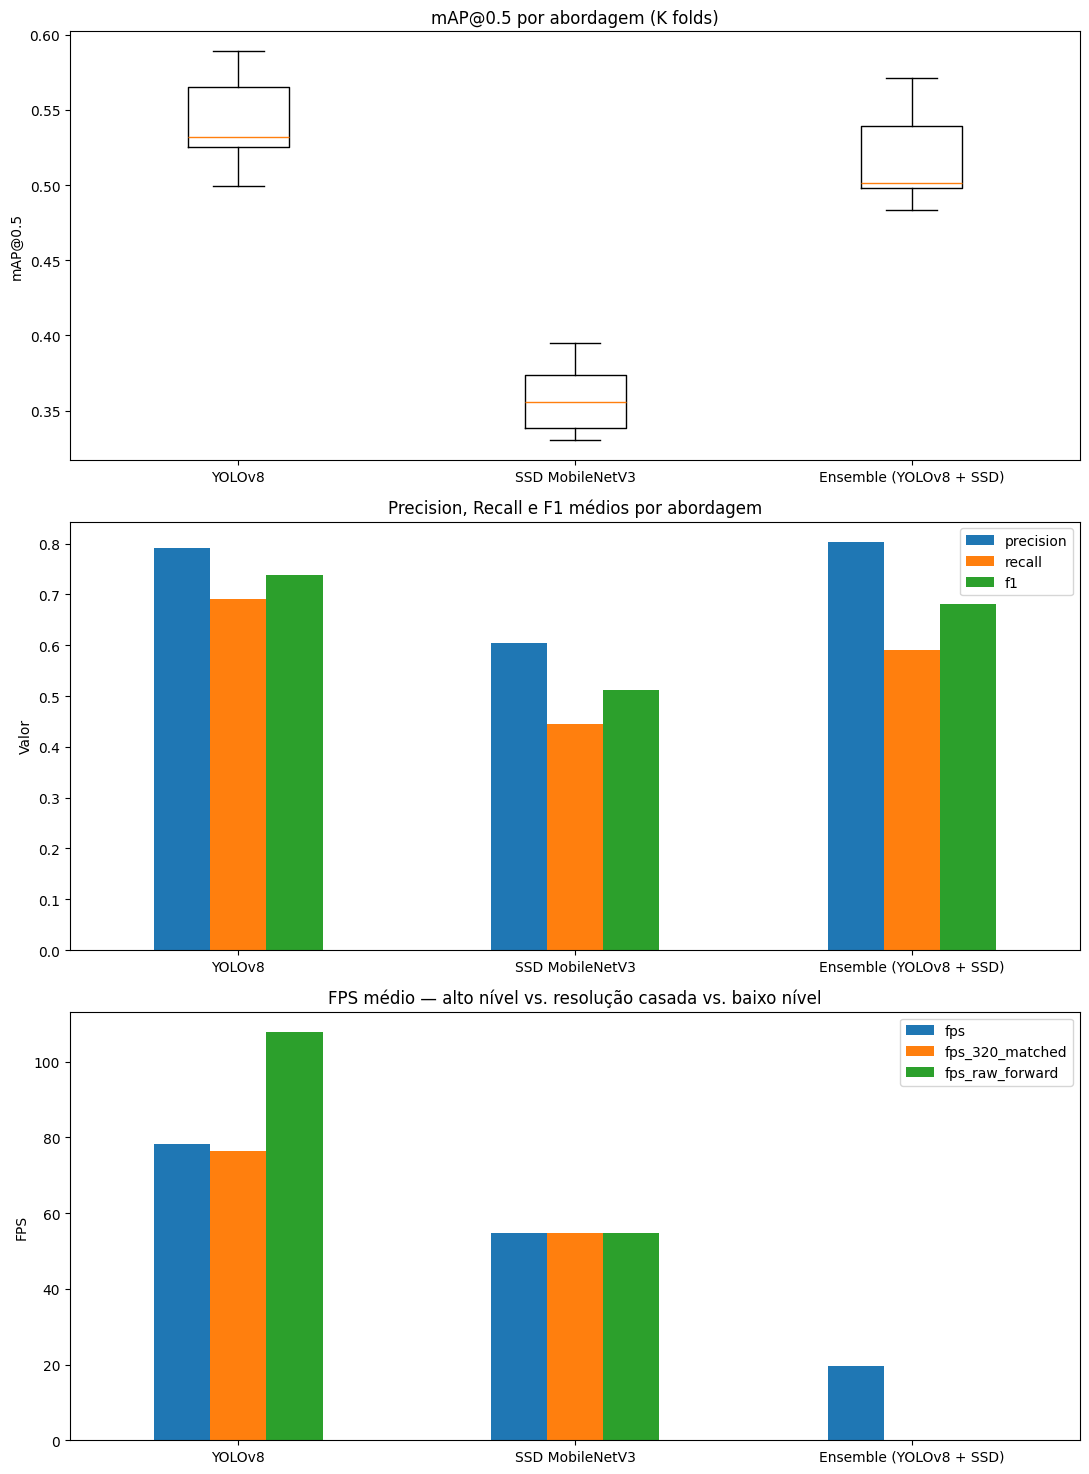

In [26]:
import matplotlib.pyplot as plt

models_plot = [m for m in MODEL_ORDER if m in set(results_df["model"])]

fig, axes = plt.subplots(3, 1, figsize=(11, 15))   # um gráfico abaixo do outro

# (1) mAP@0.5 por fold — boxplot na ordem fixa das abordagens
map_data = [results_df.loc[results_df["model"] == m, "map50"].dropna().values for m in models_plot]
axes[0].boxplot(map_data)
axes[0].set_xticks(range(1, len(models_plot) + 1))
axes[0].set_xticklabels(models_plot, rotation=0)
axes[0].set_title("mAP@0.5 por abordagem (K folds)")
axes[0].set_ylabel("mAP@0.5")

# (2) Precision / Recall / F1 médios
results_df.groupby("model")[["precision", "recall", "f1"]].mean().reindex(models_plot).plot(kind="bar", ax=axes[1])
axes[1].set_title("Precision, Recall e F1 médios por abordagem")
axes[1].set_xlabel(""); axes[1].set_ylabel("Valor"); axes[1].tick_params(axis="x", rotation=0)

# (3) FPS (o ensemble só tem a medição de alto nível; ver nota da Parte 10 sobre comparabilidade)
results_df.groupby("model")[["fps", "fps_320_matched", "fps_raw_forward"]].mean().reindex(models_plot).plot(kind="bar", ax=axes[2])
axes[2].set_title("FPS médio — alto nível vs. resolução casada vs. baixo nível")
axes[2].set_xlabel(""); axes[2].set_ylabel("FPS"); axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/comparacao_graficos.png", dpi=150, bbox_inches="tight")
plt.show()


## Parte 9b · Estimativa de exposição financeira à NR 28 (nova)

Endereça a limitação "nenhuma estimativa financeira de autuações da NR 28 foi calculada". A função
abaixo converte o **Recall medido no Hold-Out** (Parte 7b) em uma estimativa simplificada de
violações não detectadas e sua exposição financeira — mas os valores de multa por trabalhador e de
trabalhadores expostos por violação **precisam ser fornecidos pelo usuário**, com base na tabela de
dosimetria da NR 28 vigente e no cenário real da operação. Os valores no exemplo abaixo são
**ilustrativos/fictícios** (marcados como tal) e não devem ser citados no TCC como estimativa real
sem substituição pelos valores corretos.

A estimativa é calculada para **cada abordagem** presente no Hold-Out (YOLOv8, SSD e Ensemble).

> ⚠️ **Correção (v5):** o exemplo de uso desta parte aplicava o **Recall global** (todas as classes, dominado por capacete/colete/etc.) às imagens com violação, o que subestimava as violações perdidas e podia inverter o ranking entre as abordagens. Aqui fica apenas a **definição da função**; o cálculo com o desempenho medido nas próprias violações está na **Parte 9i**.


In [27]:
def estimate_nr28_exposure(recall, n_images_with_violation,
                            avg_workers_exposed_per_violation,
                            fine_per_worker_per_infraction,
                            reincidence_multiplier=1.0):
    """Estimativa simplificada de exposição financeira à NR 28 a partir do Recall medido.

    ATENÇÃO: esta função NÃO substitui uma análise jurídico-financeira. Os parâmetros
    `avg_workers_exposed_per_violation` e `fine_per_worker_per_infraction` devem vir da tabela
    de dosimetria da NR 28 vigente e do cenário real da operação (não são inferidos pelo modelo).
    """
    missed_violations = n_images_with_violation * (1 - recall)
    estimated_exposure = (
        missed_violations
        * avg_workers_exposed_per_violation
        * fine_per_worker_per_infraction
        * reincidence_multiplier
    )
    return {
        "violacoes_nao_detectadas_estimadas": missed_violations,
        "exposicao_financeira_estimada": estimated_exposure,
    }


# (o exemplo de uso foi movido para a Parte 9i, que usa o recall de violação em vez do recall global)


## Parte 9c · Métricas por classe, violação por imagem e predições do Hold-Out

- **AP@0.5, AP@0.5:0.95, Precision, Recall e F1 por classe**, com médias *macro* para o grupo **violação** vs. **conformidade** — que é o que importa para o problema.
- **Casamento ordenado por confiança** (o da Parte 4 percorre as predições em ordem arbitrária); a célula mostra o quanto isso muda o F1.
- **Alerta por imagem** ("há violação nesta imagem?"): aproxima o uso operacional.
- Opcional (`RUN_PER_CLASS_CV`): as mesmas métricas por classe em cada fold, com média ± desvio — mais suporte para as classes raras de violação.

Usa automaticamente os pesos v2 do YOLOv8 (Parte 7e) se existirem; senão usa os v1 e avisa. No hold-out cada classe de violação tem poucas instâncias (veja a coluna *suporte*): prefira reportar a versão da validação cruzada.

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 147MB/s]


Verificação (mAP@0.5 recalculado aqui vs. tabela da Parte 7b/7e, YOLO=v2):
  YOLOv8                     0.5678 vs 0.5678
  SSD MobileNetV3            0.3694 vs 0.3690
  Ensemble (YOLOv8 + SSD)    0.5279 vs 0.5279

Métricas por classe no Hold-Out (cuidado com o suporte das classes de violação):

--- YOLOv8 ---


,classe,tipo,suporte (GT),AP@0.5,AP@0.5:0.95,precision,recall,f1,tp,fp,fn
0,helmet,conformidade,354,0.895,0.467,0.862,0.898,0.880,318,51,36
1,gloves,conformidade,313,0.761,0.347,0.810,0.722,0.764,226,53,87
2,vest,conformidade,318,0.904,0.578,0.834,0.899,0.865,286,57,32
3,boots,conformidade,342,0.823,0.455,0.781,0.784,0.782,268,75,74
4,goggles,conformidade,109,0.771,0.317,0.844,0.697,0.764,76,14,33
5,none,pessoa / genérica,154,0.591,0.214,0.714,0.584,0.643,90,36,64
6,Person,pessoa / genérica,448,0.904,0.540,0.851,0.906,0.878,406,71,42
7,no_helmet,violação,93,0.345,0.088,0.440,0.118,0.186,11,14,82
8,no_goggle,violação,85,0.113,0.030,0.375,0.035,0.065,3,5,82
9,no_gloves,violação,92,0.110,0.030,0.241,0.076,0.116,7,22,85


,grupo,classes,AP@0.5 (macro),AP@0.5:0.95 (macro),recall (macro),precision (macro)
0,violação,4,0.149,0.039,0.057,0.264
1,conformidade,5,0.831,0.433,0.800,0.826


...

,classe,tipo,suporte (GT),AP@0.5,AP@0.5:0.95,precision,recall,f1,tp,fp,fn
0,helmet,conformidade,354,0.563,0.235,0.783,0.407,0.535,144,40,210
1,gloves,conformidade,313,0.301,0.089,0.706,0.115,0.198,36,15,277
2,vest,conformidade,318,0.766,0.452,0.665,0.742,0.701,236,119,82
3,boots,conformidade,342,0.519,0.267,0.881,0.389,0.540,133,18,209
4,goggles,conformidade,109,0.377,0.103,0.571,0.257,0.354,28,21,81
5,none,pessoa / genérica,154,0.448,0.140,0.396,0.545,0.459,84,128,70
6,Person,pessoa / genérica,448,0.800,0.404,0.616,0.806,0.698,361,225,87
7,no_helmet,violação,93,0.163,0.039,0.278,0.269,0.273,25,65,68
8,no_goggle,violação,85,0.068,0.014,0.250,0.024,0.043,2,6,83
9,no_gloves,violação,92,0.058,0.013,0.214,0.065,0.100,6,22,86


,grupo,classes,AP@0.5 (macro),AP@0.5:0.95 (macro),recall (macro),precision (macro)
0,violação,4,0.072,0.017,0.089,0.186
1,conformidade,5,0.505,0.229,0.382,0.721



--- Ensemble (YOLOv8 + SSD) ---


,classe,tipo,suporte (GT),AP@0.5,AP@0.5:0.95,precision,recall,f1,tp,fp,fn
0,helmet,conformidade,354,0.870,0.450,0.903,0.819,0.859,290,31,64
1,gloves,conformidade,313,0.706,0.326,0.913,0.505,0.650,158,15,155
2,vest,conformidade,318,0.885,0.569,0.822,0.874,0.848,278,60,40
3,boots,conformidade,342,0.777,0.426,0.913,0.585,0.713,200,19,142
4,goggles,conformidade,109,0.690,0.272,0.902,0.422,0.575,46,5,63
5,none,pessoa / genérica,154,0.511,0.193,0.593,0.558,0.575,86,59,68
6,Person,pessoa / genérica,448,0.879,0.514,0.791,0.864,0.826,387,102,61
7,no_helmet,violação,93,0.235,0.065,0.429,0.097,0.158,9,12,84
8,no_goggle,violação,85,0.111,0.025,0.500,0.012,0.023,1,1,84
9,no_gloves,violação,92,0.106,0.028,0.300,0.033,0.059,3,7,89


,grupo,classes,AP@0.5 (macro),AP@0.5:0.95 (macro),recall (macro),precision (macro)
0,violação,4,0.122,0.032,0.035,0.307
1,conformidade,5,0.786,0.409,0.641,0.891


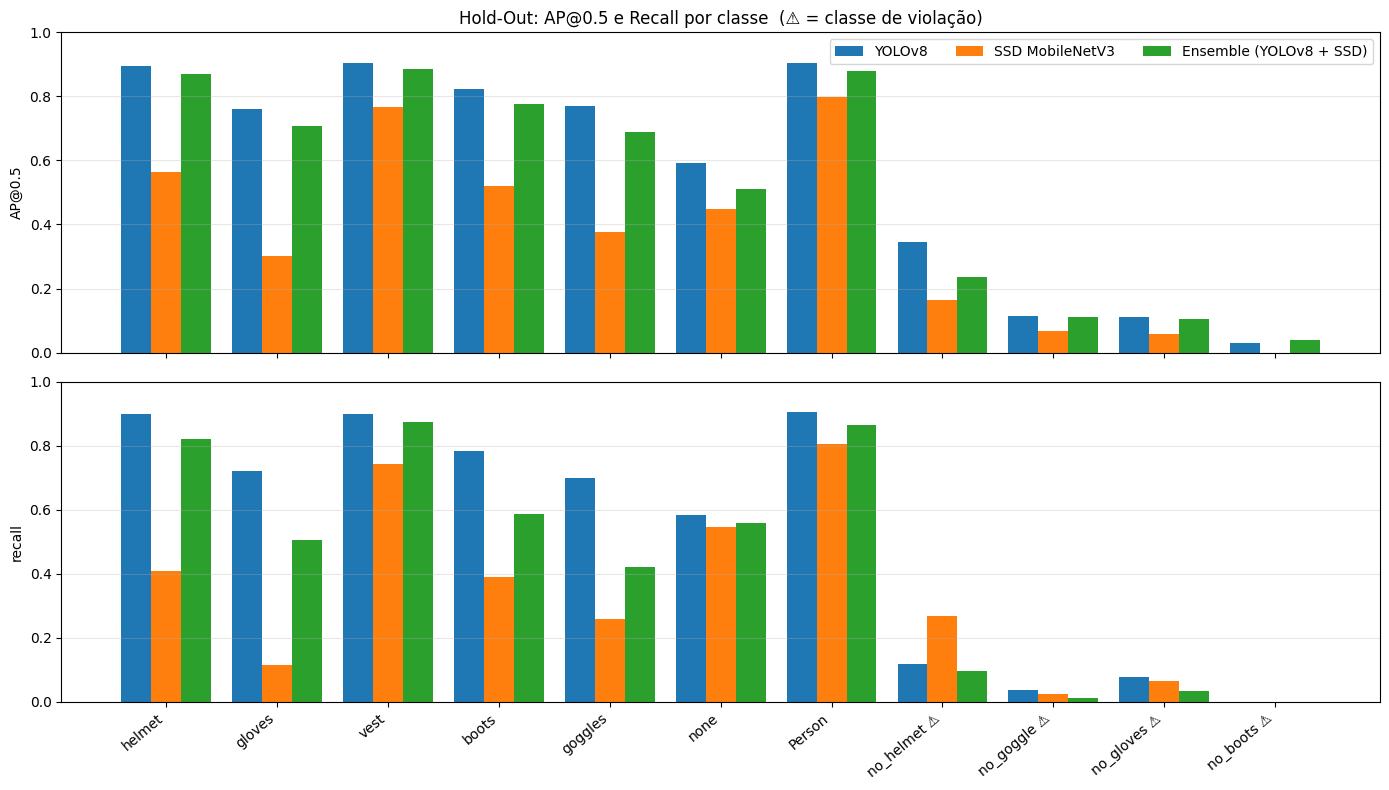


F1 global no Hold-Out: casamento original (Parte 4) vs. ordenado por confiança (Parte 9c):
  YOLOv8                     F1 0.7671 -> 0.7671 | TP 1691 -> 1691
  SSD MobileNetV3            F1 0.5231 -> 0.5231 | TP 1055 -> 1055
  Ensemble (YOLOv8 + SSD)    F1 0.7131 -> 0.7131 | TP 1458 -> 1458

Detecção de violação por IMAGEM no Hold-Out (alerta 'há violação?'):


,modelo,imagens,com violação (GT),tp,fp,fn,tn,precision,recall,f1,especificidade
0,YOLOv8,284,59,35,0,24,225,1.000,0.593,0.745,1.000
1,SSD MobileNetV3,284,59,39,1,20,224,0.975,0.661,0.788,0.996
2,Ensemble (YOLOv8 + SSD),284,59,25,0,34,225,1.000,0.424,0.595,1.000



Métricas por classe na CV carregadas de /content/drive/MyDrive/epi_experimento/metricas_por_classe_cv.csv (apague o arquivo para recalcular).

Métricas por classe na validação cruzada (média e desvio-padrão entre folds):


AP@0.5        recall        precision  \
                                    mean    std   mean    std      mean   
modelo                  classe                                            
YOLOv8                  Person     0.885  0.037  0.873  0.048     0.844   
                        boots      0.794  0.065  0.742  0.067     0.771   
                        gloves     0.803  0.045  0.768  0.065     0.819   
                        goggles    0.728  0.090  0.707  0.091     0.811   
                        helmet     0.891  0.040  0.879  0.042     0.855   
                        no_boots   0.064  0.113  0.004  0.014     0.017   
                        no_gloves  0.145  0.055  0.087  0.037     0.312   
                        no_goggle  0.139  0.073  0.040  0.044     0.360   
                        no_helmet  0.196  0.060  0.109  0.044     0.349   
                        none       0.439  0.073  0.450  0.050     0.567   
                        vest       0.889  0.056  0.863  0.080     0.849   
SSD MobileNetV3         Person     0.770  0.034  0.791  0.045     0.589   
                        boots      0.550  0.070  0.429  0.071     0.849   
                        gloves     0.309  0.044  0.130  0.024     0.752   
                        goggles    0.363  0.078  0.226  0.060     0.622   
                        helmet     0.569  0.079  0.417  0.074     0.808   
                        no_boots   0.004  0.009  0.000  0.000     0.000   
                        no_gloves  0.054  0.044  0.042  0.036     0.234   
                        no_goggle  0.052  0.024  0.009  0.014     0.137   
                        no_helmet  0.149  0.047  0.210  0.072     0.245   
                        none       0.352  0.061  0.414  0.055     0.371   
                        vest       0.751  0.074  0.742  0.077     0.642   
Ensemble (YOLOv8 + SSD) Person     0.849  0.029  0.829  0.048     0.772   
                        boots      0.758  0.068  0.587  0.053     0.893   
                        gloves     0.764  0.046  0.538  0.066     0.932   
                        goggles    0.683  0.096  0.344  0.064     0.863   
                        helmet     0.863  0.047  0.790  0.060     0.897   
                        no_boots   0.060  0.104  0.000  0.000     0.000   
                        no_gloves  0.119  0.047  0.019  0.025     0.234   
                        no_goggle  0.119  0.063  0.004  0.012     0.100   
                        no_helmet  0.188  0.061  0.109  0.069     0.349   
                        none       0.424  0.068  0.426  0.062     0.555   
                        vest       0.858  0.059  0.824  0.080     0.794   

                                             f1         
                                     std   mean    std  
modelo                  classe                          
YOLOv8                  Person     0.053  0.856  0.035  
                        boots      0.085  0.754  0.065  
                        gloves     0.054  0.791  0.044  
                        goggles    0.082  0.753  0.074  
                        helmet     0.041  0.866  0.036  
                        no_boots   0.053  0.007  0.022  
                        no_gloves  0.122  0.134  0.052  
                        no_goggle  0.344  0.070  0.073  
                        no_helmet  0.112  0.163  0.060  
                        none       0.096  0.499  0.062  
                        vest       0.073  0.854  0.064  
SSD MobileNetV3         Person     0.040  0.674  0.025  
                        boots      0.042  0.567  0.069  
                        gloves     0.113  0.221  0.037  
                        goggles    0.107  0.329  0.074  
                        helmet     0.049  0.548  0.072  
                        no_boots   0.000  0.000  0.000  
                        no_gloves  0.172  0.067  0.052  
                        no_goggle  0.313  0.015  0.025  
                        no_helmet  0.044  0.219  0.044  
                      

Ambiente registrado em /content/drive/MyDrive/epi_experimento/ambiente.json e requirements_versions.txt
  GPU: NVIDIA A100-SXM4-40GB | Python 3.13.15 | torch 2.11.0+cu128 | ultralytics 8.4.159


In [28]:
# ==== Parte 9c · Métricas por classe e detecção de violação por imagem ====
# Rodar depois da Parte 7b (e, de preferência, depois da Parte 7e). Precisa dos pesos treinados.
import gc
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore", message="Encountered more than 100 detections")  # efeito medido na Parte 9h
CONF_THR = 0.25          # mesmo limiar fixo usado para Precision/Recall/F1 nas Partes 4-7
IOU_THR = 0.5
RUN_PER_CLASS_CV = True  # métricas por classe também nos K folds (mais suporte por classe; ~5-10 min)


# ------------------------------------------------------------------------------------------------
# Utilidades (NumPy puro: aceitam tensores do PyTorch em CPU ou arrays)
# ------------------------------------------------------------------------------------------------
def _to_np(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def _iou_matrix(a, b):
    """IoU par-a-par entre a [N,4] e b [M,4] (xyxy)."""
    a = a.reshape(-1, 4).astype(np.float64)
    b = b.reshape(-1, 4).astype(np.float64)
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0])
    iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2])
    iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    area_a = np.clip(a[:, 2] - a[:, 0], 0, None) * np.clip(a[:, 3] - a[:, 1], 0, None)
    area_b = np.clip(b[:, 2] - b[:, 0], 0, None) * np.clip(b[:, 3] - b[:, 1], 0, None)
    union = area_a[:, None] + area_b[None, :] - inter
    return np.where(union > 0, inter / np.where(union > 0, union, 1.0), 0.0)


def match_image(pred, gt, conf_thr=CONF_THR, iou_thr=IOU_THR, class_aware=True):
    """Casamento predição↔gabarito de UMA imagem, com as predições em ordem DECRESCENTE de confiança
    (o `compute_precision_recall_f1` original percorre em ordem arbitrária). `class_aware=False`
    ignora a classe (usado na matriz de confusão)."""
    pb = _to_np(pred["boxes"]).reshape(-1, 4)
    ps = _to_np(pred["scores"]).reshape(-1)
    pl = _to_np(pred["labels"]).reshape(-1).astype(int)
    gb = _to_np(gt["boxes"]).reshape(-1, 4)
    gl = _to_np(gt["labels"]).reshape(-1).astype(int)

    keep = ps >= conf_thr
    pb, ps, pl = pb[keep], ps[keep], pl[keep]
    order = np.argsort(-ps, kind="stable")
    pb, ps, pl = pb[order], ps[order], pl[order]

    ious = _iou_matrix(pb, gb) if len(pb) and len(gb) else np.zeros((len(pb), len(gb)))
    matched, tp, fp = set(), [], []
    for i in range(len(pb)):
        best, best_j = 0.0, -1
        for j in range(len(gb)):
            if j in matched or (class_aware and gl[j] != pl[i]):
                continue
            if ious[i, j] > best:
                best, best_j = ious[i, j], j
        if best_j >= 0 and best >= iou_thr:
            matched.add(best_j)
            tp.append((i, best_j))
        else:
            fp.append(i)
    fn = [j for j in range(len(gb)) if j not in matched]
    return {"pb": pb, "ps": ps, "pl": pl, "gb": gb, "gl": gl, "tp": tp, "fp": fp, "fn": fn}


def _prf(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f


def compute_prf_sorted(preds, gts, conf_thr=CONF_THR, iou_thr=IOU_THR):
    """Precision/Recall/F1 globais com casamento ordenado por confiança."""
    tp = fp = fn = 0
    for p, g in zip(preds, gts):
        m = match_image(p, g, conf_thr, iou_thr)
        tp, fp, fn = tp + len(m["tp"]), fp + len(m["fp"]), fn + len(m["fn"])
    p, r, f = _prf(tp, fp, fn)
    return {"tp": tp, "fp": fp, "fn": fn, "precision": p, "recall": r, "f1": f}


def _only_class(d, c, has_scores):
    lab = _to_np(d["labels"]).reshape(-1)
    mask = lab == c
    out = {"boxes": _to_np(d["boxes"]).reshape(-1, 4)[mask], "labels": lab[mask]}
    if has_scores:
        out["scores"] = _to_np(d["scores"]).reshape(-1)[mask]
    return out


# ------------------------------------------------------------------------------------------------
# Métricas por classe
# ------------------------------------------------------------------------------------------------
def _ap_per_class(preds, gts, iou_thresholds=None):
    """AP por classe via torchmetrics (mesma biblioteca usada no mAP das Partes 4-7)."""
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    kw = {"iou_thresholds": iou_thresholds} if iou_thresholds else {}
    metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True, **kw)
    metric.update(preds, gts)
    r = metric.compute()
    classes = np.atleast_1d(_to_np(r["classes"])).astype(int)
    vals = np.atleast_1d(_to_np(r["map_per_class"])).astype(float)
    per_class = {int(c): (float(v) if v >= 0 else np.nan) for c, v in zip(classes, vals)}
    return per_class, float(r["map"])


def per_class_table(preds, gts, conf_thr=CONF_THR):
    """Tabela por classe: suporte, AP@0.5, AP@0.5:0.95, Precision, Recall, F1 (limiar `conf_thr`)."""
    ap50, map50_all = _ap_per_class(preds, gts, iou_thresholds=[0.5])
    ap5095, map5095_all = _ap_per_class(preds, gts)
    rows = []
    for c, name in enumerate(CLASS_NAMES):
        pc = [_only_class(p, c, True) for p in preds]
        gc_ = [_only_class(g, c, False) for g in gts]
        support = int(sum(len(g["labels"]) for g in gc_))
        prf = compute_prf_sorted(pc, gc_, conf_thr)
        rows.append({
            "id": c, "classe": name,
            "tipo": "violação" if c in VIOLATION_CLASS_IDS else ("pessoa / genérica" if name in ("Person", "none") else "conformidade"),
            "suporte (GT)": support,
            "AP@0.5": ap50.get(c, np.nan) if support else np.nan,
            "AP@0.5:0.95": ap5095.get(c, np.nan) if support else np.nan,
            "precision": prf["precision"], "recall": prf["recall"], "f1": prf["f1"],
            "tp": prf["tp"], "fp": prf["fp"], "fn": prf["fn"],
        })
    df = pd.DataFrame(rows)
    df.attrs["map50_torchmetrics"] = map50_all
    df.attrs["map5095_torchmetrics"] = map5095_all
    return df


def group_means(df):
    """Médias macro (por classe, sem ponderar pelo suporte) — violações vs. conformidade."""
    out = []
    for tipo in ("violação", "conformidade"):
        d = df[(df["tipo"] == tipo) & (df["suporte (GT)"] > 0)]
        out.append({"grupo": tipo, "classes": len(d), "AP@0.5 (macro)": d["AP@0.5"].mean(),
                    "AP@0.5:0.95 (macro)": d["AP@0.5:0.95"].mean(),
                    "recall (macro)": d["recall"].mean(), "precision (macro)": d["precision"].mean()})
    return pd.DataFrame(out)


def image_level_violation(preds, gts, conf_thr=CONF_THR):
    """Métrica de ALERTA por imagem: 'há alguma violação nesta imagem?' (não exige acertar a caixa).
    Aproxima o uso operacional (disparar um alerta), mas é mais permissiva que a métrica por caixa."""
    tp = fp = fn = tn = 0
    for p, g in zip(preds, gts):
        gt_has = any(int(l) in VIOLATION_CLASS_IDS for l in _to_np(g["labels"]).reshape(-1))
        keep = _to_np(p["scores"]).reshape(-1) >= conf_thr
        pred_has = any(int(l) in VIOLATION_CLASS_IDS for l in _to_np(p["labels"]).reshape(-1)[keep])
        tp += gt_has and pred_has
        fp += (not gt_has) and pred_has
        fn += gt_has and (not pred_has)
        tn += (not gt_has) and (not pred_has)
    p_, r_, f_ = _prf(tp, fp, fn)
    return {"imagens": tp + fp + fn + tn, "com violação (GT)": tp + fn, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": p_, "recall": r_, "f1": f_, "especificidade": tn / (tn + fp) if (tn + fp) else 0.0}


# ------------------------------------------------------------------------------------------------
# Predições dos três modelos em um conjunto de imagens
# ------------------------------------------------------------------------------------------------
def resolve_yolo_weights(kind, fold_id):
    v2 = f"{PROJECT_DIR}/runs_yolo/{kind}v2_{fold_id}/weights/best.pt"
    v1 = f"{PROJECT_DIR}/runs_yolo/{kind}_{fold_id}/weights/best.pt"
    if os.path.exists(v2):
        return v2, "v2"
    if os.path.exists(v1):
        return v1, "v1"
    return None, None


def resolve_ssd_weights(kind, fold_id):
    p = f"{PROJECT_DIR}/runs_ssd/{kind}_{fold_id}/weights/best.pt"
    return p if os.path.exists(p) else None


def predict_three(idx, yolo_w, ssd_w):
    """Predições (limiar baixo, sem filtro) de YOLOv8, SSD e Ensemble em `idx`. Sem re-treino."""
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    yolo_model = load_yolo_from_weights(yolo_w)
    ssd_model = load_ssd_from_weights(ssd_w, device)
    out = {YOLO_NAME: [], SSD_NAME: [], ENSEMBLE_NAME: []}
    gts, paths = [], []
    for i in idx:
        img_path, lbl_path = all_images[i]
        img_rgb = np.array(Image.open(img_path).convert("RGB"))
        h, w = img_rgb.shape[:2]
        p_y = yolo_predict_raw(yolo_model, img_path)
        p_s = ssd_predict_raw(ssd_model, img_rgb, device)
        out[YOLO_NAME].append(p_y)
        out[SSD_NAME].append(p_s)
        out[ENSEMBLE_NAME].append(fuse_predictions([p_y, p_s], w, h))
        gts.append(build_gt_dict(lbl_path, w, h, device="cpu"))
        paths.append(img_path)
    del yolo_model, ssd_model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    return out, gts, paths


def plot_per_class(table_by_model, path, title):
    names = [c for c in CLASS_NAMES]
    x = np.arange(len(names))
    width = 0.27
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for ax, col in zip(axes, ["AP@0.5", "recall"]):
        for k, m in enumerate(MODEL_ORDER):
            vals = table_by_model[m].set_index("classe").reindex(names)[col].values
            ax.bar(x + (k - 1) * width, vals, width, label=m)
        ax.set_ylabel(col)
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([n + (" ⚠" if i in VIOLATION_CLASS_IDS else "") for i, n in enumerate(names)],
                            rotation=40, ha="right")
    axes[0].legend(ncol=3)
    axes[0].set_title(title + "  (⚠ = classe de violação)")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()


# ---- execução ----
# 1) Hold-Out ------------------------------------------------------------------------------------
yolo_w, tag = resolve_yolo_weights("holdout", -1)
ssd_w = resolve_ssd_weights("holdout", -1)
if yolo_w is None or ssd_w is None or len(holdout_idx) == 0:
    print("⚠️ Pesos do Hold-Out não encontrados (rode a Parte 7b). Célula ignorada.")
else:
    if tag == "v1":
        print("⚠️ Usando o YOLOv8 v1 (best.pt escolhido no próprio Hold-Out). Rode a Parte 7e para o v2.")
    HOLDOUT_PREDS, HOLDOUT_GTS, HOLDOUT_PATHS = predict_three(holdout_idx, yolo_w, ssd_w)
    HOLDOUT_YOLO_TAG = tag

    tables = {m: per_class_table(HOLDOUT_PREDS[m], HOLDOUT_GTS) for m in MODEL_ORDER}
    ref_df = holdout_v2_df if (tag == "v2" and "holdout_v2_df" in globals() and len(holdout_v2_df)) else holdout_results_df
    print(f"Verificação (mAP@0.5 recalculado aqui vs. tabela da Parte 7b/7e, YOLO={tag}):")
    for m in MODEL_ORDER:
        ref = ref_df.loc[ref_df["model"] == m, "map50"]
        print(f"  {m:26s} {tables[m].attrs['map50_torchmetrics']:.4f} vs {float(ref.iloc[0]) if len(ref) else float('nan'):.4f}")

    long_df = pd.concat([t.assign(modelo=m) for m, t in tables.items()], ignore_index=True)
    long_df.to_csv(f"{PROJECT_DIR}/metricas_por_classe_holdout.csv", index=False)
    print("\nMétricas por classe no Hold-Out (cuidado com o suporte das classes de violação):")
    for m in MODEL_ORDER:
        print(f"\n--- {m} ---")
        display(tables[m].drop(columns=["id"]).round(3))
        display(group_means(tables[m]).round(3))
    plot_per_class(tables, f"{PROJECT_DIR}/metricas_por_classe_holdout.png", "Hold-Out: AP@0.5 e Recall por classe")

    # Comparação do casamento ordenado com o da Parte 4 (para justificar/relatar a diferença)
    print("\nF1 global no Hold-Out: casamento original (Parte 4) vs. ordenado por confiança (Parte 9c):")
    for m in MODEL_ORDER:
        orig = compute_precision_recall_f1(HOLDOUT_PREDS[m], HOLDOUT_GTS)
        srt = compute_prf_sorted(HOLDOUT_PREDS[m], HOLDOUT_GTS)
        print(f"  {m:26s} F1 {orig['f1']:.4f} -> {srt['f1']:.4f} | TP {orig['tp']} -> {srt['tp']}")

    # Alerta por imagem
    img_rows = [{"modelo": m, **image_level_violation(HOLDOUT_PREDS[m], HOLDOUT_GTS)} for m in MODEL_ORDER]
    img_df = pd.DataFrame(img_rows)
    img_df.to_csv(f"{PROJECT_DIR}/violacao_por_imagem_holdout.csv", index=False)
    print("\nDetecção de violação por IMAGEM no Hold-Out (alerta 'há violação?'):")
    display(img_df.round(3))

# 2) Validação cruzada (opcional) ----------------------------------------------------------------
if RUN_PER_CLASS_CV:
    cv_csv = f"{PROJECT_DIR}/metricas_por_classe_cv.csv"
    if os.path.exists(cv_csv):
        cv_long = pd.read_csv(cv_csv)
        print(f"\nMétricas por classe na CV carregadas de {cv_csv} (apague o arquivo para recalcular).")
    else:
        parts = []
        for fold_id, (_, test_idx) in enumerate(folds):
            yw, tg = resolve_yolo_weights("fold", fold_id)
            sw = resolve_ssd_weights("fold", fold_id)
            if yw is None or sw is None:
                print(f"  ⚠️ fold {fold_id}: pesos não encontrados — pulado.")
                continue
            print(f"  fold {fold_id}: YOLO {tg}")
            out, gts_f, _ = predict_three(test_idx, yw, sw)
            for m in MODEL_ORDER:
                parts.append(per_class_table(out[m], gts_f).assign(modelo=m, fold=fold_id, yolo_versao=tg))
        cv_long = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
        if len(cv_long):
            cv_long.to_csv(cv_csv, index=False)
    if len(cv_long):
        agg = (cv_long.groupby(["modelo", "classe"])[["AP@0.5", "recall", "precision", "f1"]]
               .agg(["mean", "std"]).round(3))
        print("\nMétricas por classe na validação cruzada (média e desvio-padrão entre folds):")
        display(agg.loc[[m for m in MODEL_ORDER if m in agg.index.get_level_values(0)]])
        agg.to_csv(f"{PROJECT_DIR}/metricas_por_classe_cv_resumo.csv")

if "save_environment_info" in globals():   # definida na Parte 6d
    save_environment_info()   # regrava ambiente.json agora que todas as variáveis existem

## Parte 9c-bis · Acertos por classe e por modelo

Responde à pergunta **"qual abordagem acerta mais em cada classe?"** (capacete, colete, luvas etc.). Para cada classe mostra o nº de objetos no gabarito e, por modelo, os **acertos (TP)**, **falsos positivos (FP)** e **não detectados (FN)**, indica quem teve mais acertos e desenha um gráfico de barras (Hold-Out e, se existir, validação cruzada — um gráfico abaixo do outro).

- **Não re-treina e não refaz inferência:** usa `tables` da Parte 9c ou os CSVs `metricas_por_classe_holdout.csv` / `metricas_por_classe_cv.csv` já gravados.
- "Acerto" = classe certa, IoU ≥ 0,5, confiança ≥ 0,25 — o mesmo critério da Parte 9c.
- Mais acertos não é o mesmo que "melhor": um modelo que dispara mais caixas acerta mais **e** erra mais. Leia as colunas FP junto (ex.: em `no_helmet`, o SSD acerta mais, mas com muito mais falsos positivos).
- Não existe `no_vest` no dataset: para colete só há o lado da conformidade (`vest`).

Gera `acertos_por_classe_holdout.csv/.png` e `acertos_por_classe_cv.csv/.png`.


Acertos (TP), falsos positivos (FP) e não detectados (FN) por classe — Hold-Out:


,classe,classe (pt),tipo,objetos no gabarito,TP YOLOv8,FP YOLOv8,FN YOLOv8,TP SSD MobileNetV3,FP SSD MobileNetV3,FN SSD MobileNetV3,TP Ensemble (YOLOv8 + SSD),FP Ensemble (YOLOv8 + SSD),FN Ensemble (YOLOv8 + SSD),mais acertos
0,helmet,capacete,conformidade/outros,354,318,51,36,144,40,210,290,31,64,YOLOv8
1,gloves,luvas,conformidade/outros,313,226,53,87,36,15,277,158,15,155,YOLOv8
2,vest,colete,conformidade/outros,318,286,57,32,236,119,82,278,60,40,YOLOv8
3,boots,botas,conformidade/outros,342,268,75,74,133,18,209,200,19,142,YOLOv8
4,goggles,óculos,conformidade/outros,109,76,14,33,28,21,81,46,5,63,YOLOv8
5,none,none,conformidade/outros,154,90,36,64,84,128,70,86,59,68,YOLOv8
6,Person,pessoa,conformidade/outros,448,406,71,42,361,225,87,387,102,61,YOLOv8
7,no_helmet,sem capacete,violação,93,11,14,82,25,65,68,9,12,84,SSD MobileNetV3
8,no_goggle,sem óculos,violação,85,3,5,82,2,6,83,1,1,84,YOLOv8
9,no_gloves,sem luvas,violação,92,7,22,85,6,22,86,3,7,89,YOLOv8



Resumo — em quantas classes cada modelo acertou mais (Hold-Out):


,modelo,classes com mais acertos,quais,total de acertos (TP),total de falsos positivos (FP)
0,YOLOv8,9,"helmet, gloves, vest, boots, goggles, none, Pe...",1691,398
1,SSD MobileNetV3,1,no_helmet,1055,659
2,Ensemble (YOLOv8 + SSD),0,,1458,311


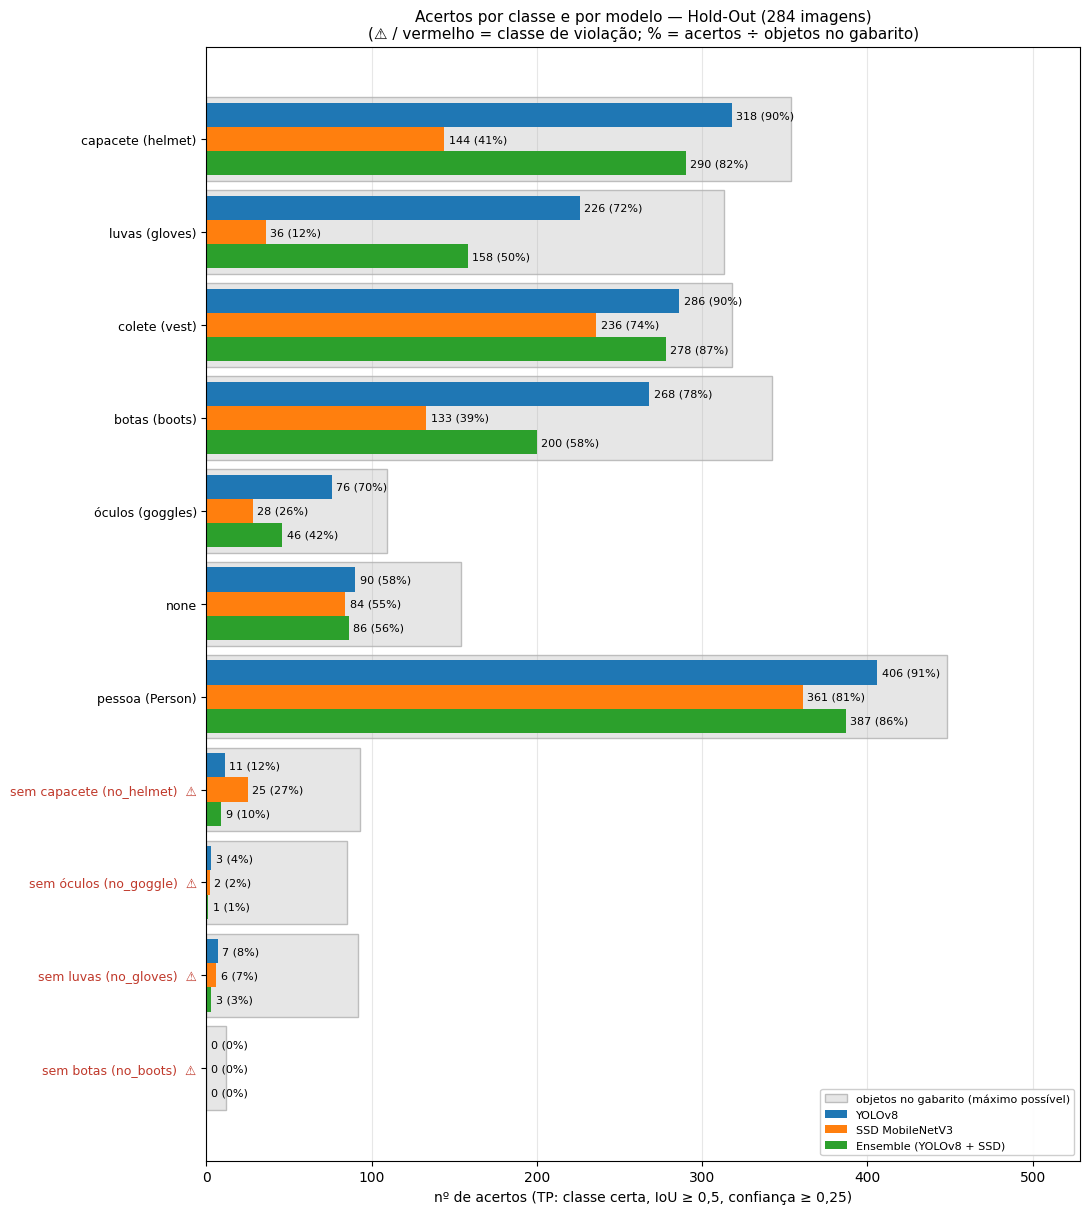


Acertos por classe — validação cruzada (soma dos 10 folds de teste):


,classe,classe (pt),tipo,objetos no gabarito,TP YOLOv8,FP YOLOv8,FN YOLOv8,TP SSD MobileNetV3,FP SSD MobileNetV3,FN SSD MobileNetV3,TP Ensemble (YOLOv8 + SSD),FP Ensemble (YOLOv8 + SSD),FN Ensemble (YOLOv8 + SSD),mais acertos
0,helmet,capacete,conformidade/outros,1380,1205,215,175,561,136,819,1079,130,301,YOLOv8
1,gloves,luvas,conformidade/outros,1132,866,193,266,147,50,985,606,46,526,YOLOv8
2,vest,colete,conformidade/outros,1300,1112,207,188,956,544,344,1062,282,238,YOLOv8
3,boots,botas,conformidade/outros,1255,926,284,329,537,96,718,733,91,522,YOLOv8
4,goggles,óculos,conformidade/outros,409,286,65,123,92,56,317,139,22,270,YOLOv8
5,none,none,conformidade/outros,643,290,228,353,266,454,377,274,225,369,YOLOv8
6,Person,pessoa,conformidade/outros,1797,1564,299,233,1416,1001,381,1484,445,313,YOLOv8
7,no_helmet,sem capacete,violação,392,41,84,351,79,251,313,40,73,352,SSD MobileNetV3
8,no_goggle,sem óculos,violação,326,13,20,313,3,20,323,1,1,325,YOLOv8
9,no_gloves,sem luvas,violação,464,40,92,424,19,70,445,8,27,456,YOLOv8



Resumo — em quantas classes cada modelo acertou mais (validação cruzada):


,modelo,classes com mais acertos,quais,total de acertos (TP),total de falsos positivos (FP)
0,YOLOv8,10,"helmet, gloves, vest, boots, goggles, none, Pe...",6344,1698
1,SSD MobileNetV3,1,no_helmet,4076,2678
2,Ensemble (YOLOv8 + SSD),0,,5426,1343


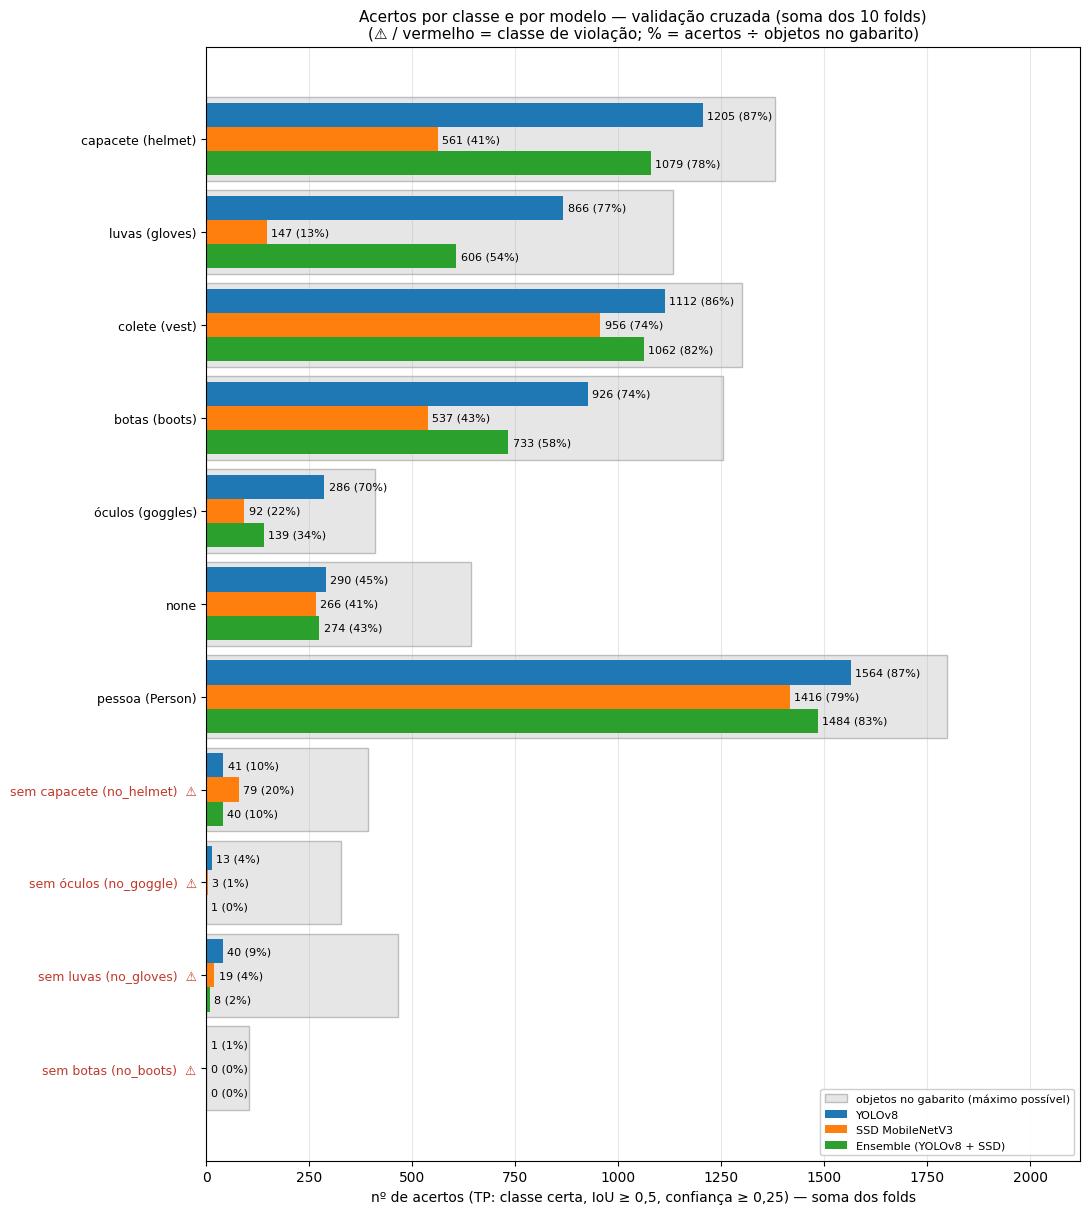


Leitura: 'mais acertos' olha só os TP. Um modelo pode acertar mais porque dispara mais caixas — confira as colunas FP antes de concluir que ele é 'melhor' naquela classe.


In [29]:
# ==== Parte 9c-bis · Acertos por classe e por modelo (tabela + gráfico) ====
# Rodar depois da Parte 9c. NÃO re-treina e NÃO refaz inferência: usa as tabelas por classe que a Parte 9c
# já calculou (variável `tables`) ou, se a sessão foi reiniciada, os CSVs que ela gravou no Drive:
#   • metricas_por_classe_holdout.csv  (Hold-Out)
#   • metricas_por_classe_cv.csv       (validação cruzada, um bloco por fold)
# "Acerto" = verdadeiro positivo (TP): classe correta, IoU >= 0,5 e confiança >= 0,25 (CONF_THR da Parte 9c).
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_COLORS = {"YOLOv8": "#1f77b4", "SSD MobileNetV3": "#ff7f0e", "Ensemble (YOLOv8 + SSD)": "#2ca02c"}
_MODELS = globals().get("MODEL_ORDER", list(MODEL_COLORS))
_VIOL = set(globals().get("VIOLATION_CLASS_IDS", {7, 8, 9, 10}))
_CLASSES = list(globals().get("CLASS_NAMES", ["helmet", "gloves", "vest", "boots", "goggles", "none", "Person",
                                              "no_helmet", "no_goggle", "no_gloves", "no_boots"]))
_PT = {"helmet": "capacete", "gloves": "luvas", "vest": "colete", "boots": "botas", "goggles": "óculos",
       "none": "none", "Person": "pessoa", "no_helmet": "sem capacete", "no_goggle": "sem óculos",
       "no_gloves": "sem luvas", "no_boots": "sem botas"}


def hits_table(long_df):
    """Tabela larga por classe: suporte, TP/FP/FN de cada modelo e o modelo com mais acertos.
    `long_df` precisa das colunas: modelo, classe, suporte (GT), tp, fp, fn (uma ou várias linhas por
    modelo/classe — no caso da CV, uma por fold, que são somadas)."""
    g = long_df.groupby(["modelo", "classe"])[["suporte (GT)", "tp", "fp", "fn"]].sum()
    rows = []
    for c in _CLASSES:
        row = {"classe": c, "classe (pt)": _PT.get(c, c),
               "tipo": "violação" if _CLASSES.index(c) in _VIOL else "conformidade/outros"}
        sup = [int(g.loc[(m, c), "suporte (GT)"]) for m in _MODELS if (m, c) in g.index]
        row["objetos no gabarito"] = sup[0] if sup else 0
        for m in _MODELS:
            for k in ("tp", "fp", "fn"):
                row[f"{k.upper()} {m}"] = int(g.loc[(m, c), k]) if (m, c) in g.index else 0
        tps = {m: row[f"TP {m}"] for m in _MODELS}
        best = max(tps.values())
        winners = [m for m, v in tps.items() if v == best]
        row["mais acertos"] = "nenhum acerto" if best == 0 else (" = ".join(winners) if len(winners) > 1 else winners[0])
        rows.append(row)
    return pd.DataFrame(rows)


def wins_summary(tbl):
    """Quantas classes cada modelo 'venceu' em nº de acertos (empates contam para todos os empatados)."""
    out = []
    for m in _MODELS:
        won = [r["classe"] for _, r in tbl.iterrows() if m in r["mais acertos"].split(" = ")]
        out.append({"modelo": m, "classes com mais acertos": len(won), "quais": ", ".join(won),
                    "total de acertos (TP)": int(tbl[f"TP {m}"].sum()),
                    "total de falsos positivos (FP)": int(tbl[f"FP {m}"].sum())})
    return pd.DataFrame(out)


def plot_hits(tbl, title, path, suffix=""):
    """Um gráfico por conjunto (Hold-Out ou CV), um abaixo do outro: barras de acertos por classe e modelo,
    com o nº de objetos do gabarito como referência (barra cinza de fundo)."""
    n = len(tbl)
    y = np.arange(n)
    h = 0.26
    fig, ax = plt.subplots(figsize=(11, 0.95 * n + 1.8))
    ax.barh(y, tbl["objetos no gabarito"], height=0.9, color="#e6e6e6", edgecolor="#bdbdbd",
            label="objetos no gabarito (máximo possível)", zorder=1)
    for k, m in enumerate(_MODELS):
        vals = tbl[f"TP {m}"].values
        pos = y + (k - (len(_MODELS) - 1) / 2) * h
        ax.barh(pos, vals, height=h, color=MODEL_COLORS.get(m), label=m, zorder=2)
        for p, v, tot in zip(pos, vals, tbl["objetos no gabarito"].values):
            pct = f" ({100 * v / tot:.0f}%)" if tot else ""
            ax.text(v + tbl["objetos no gabarito"].max() * 0.006, p, f"{v}{pct}", va="center", fontsize=8, zorder=3)
    labels = [(f"{r['classe (pt)']} ({r['classe']})" if r["classe (pt)"] != r["classe"] else r["classe"]) + ("  ⚠" if r["tipo"] == "violação" else "")
              for _, r in tbl.iterrows()]
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    for lbl, (_, r) in zip(ax.get_yticklabels(), tbl.iterrows()):
        if r["tipo"] == "violação":
            lbl.set_color("#c0392b")
    ax.invert_yaxis()
    ax.set_xlim(0, tbl["objetos no gabarito"].max() * 1.18)
    ax.set_xlabel("nº de acertos (TP: classe certa, IoU ≥ 0,5, confiança ≥ 0,25)" + suffix)
    ax.set_title(title + "\n(⚠ / vermelho = classe de violação; % = acertos ÷ objetos no gabarito)", fontsize=11)
    ax.grid(axis="x", alpha=0.3, zorder=0)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.95)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


# ---- execução ----
# 1) Hold-Out
if "tables" in globals():
    ho_long = pd.concat([t.assign(modelo=m) for m, t in tables.items()], ignore_index=True)
elif os.path.exists(f"{PROJECT_DIR}/metricas_por_classe_holdout.csv"):
    ho_long = pd.read_csv(f"{PROJECT_DIR}/metricas_por_classe_holdout.csv")
else:
    ho_long = None
    print("⚠️ Sem métricas por classe do Hold-Out: rode a Parte 9c antes.")

if ho_long is not None:
    HITS_HOLDOUT = hits_table(ho_long)
    HITS_HOLDOUT.to_csv(f"{PROJECT_DIR}/acertos_por_classe_holdout.csv", index=False)
    print("Acertos (TP), falsos positivos (FP) e não detectados (FN) por classe — Hold-Out:")
    display(HITS_HOLDOUT)
    print("\nResumo — em quantas classes cada modelo acertou mais (Hold-Out):")
    display(wins_summary(HITS_HOLDOUT))
    plot_hits(HITS_HOLDOUT, f"Acertos por classe e por modelo — Hold-Out ({len(globals().get('holdout_idx', []))} imagens)",
              f"{PROJECT_DIR}/acertos_por_classe_holdout.png")

# 2) Validação cruzada (soma dos K folds de teste: cada imagem de desenvolvimento conta uma vez)
cv_csv = f"{PROJECT_DIR}/metricas_por_classe_cv.csv"
if os.path.exists(cv_csv):
    cv_long_hits = pd.read_csv(cv_csv)
    if {"tp", "fp", "fn"}.issubset(cv_long_hits.columns):
        n_f = cv_long_hits["fold"].nunique() if "fold" in cv_long_hits.columns else "?"
        HITS_CV = hits_table(cv_long_hits)
        HITS_CV.to_csv(f"{PROJECT_DIR}/acertos_por_classe_cv.csv", index=False)
        print(f"\nAcertos por classe — validação cruzada (soma dos {n_f} folds de teste):")
        display(HITS_CV)
        print("\nResumo — em quantas classes cada modelo acertou mais (validação cruzada):")
        display(wins_summary(HITS_CV))
        plot_hits(HITS_CV, f"Acertos por classe e por modelo — validação cruzada (soma dos {n_f} folds)",
                  f"{PROJECT_DIR}/acertos_por_classe_cv.png", suffix=" — soma dos folds")
    else:
        print("\n⚠️ metricas_por_classe_cv.csv não tem as colunas tp/fp/fn — apague-o e rode a Parte 9c de novo "
              "(ela recalcula por inferência, sem re-treinar).")
else:
    print("\n(metricas_por_classe_cv.csv não encontrado: rode a Parte 9c com RUN_PER_CLASS_CV = True para ter a versão da CV.)")

print("\nLeitura: 'mais acertos' olha só os TP. Um modelo pode acertar mais porque dispara mais caixas — "
      "confira as colunas FP antes de concluir que ele é 'melhor' naquela classe.")


## Parte 9d · Matriz de confusão de detecção

Casamento predição↔objeto por IoU ≥ 0,5 **ignorando a classe**, para expor trocas de classe (ex.: `no_helmet` ↔ `none`), falsos positivos (última linha) e objetos não detectados (última coluna). Requer a Parte 9c.

**Visual (v7):** cor = proporção da linha, texto = contagem + %, células com zero em branco, diagonal (acertos) com borda azul, classes de violação em vermelho. Para trocar o mapa de cores, altere `CONFUSION_CMAP` (ex.: `"viridis"`).

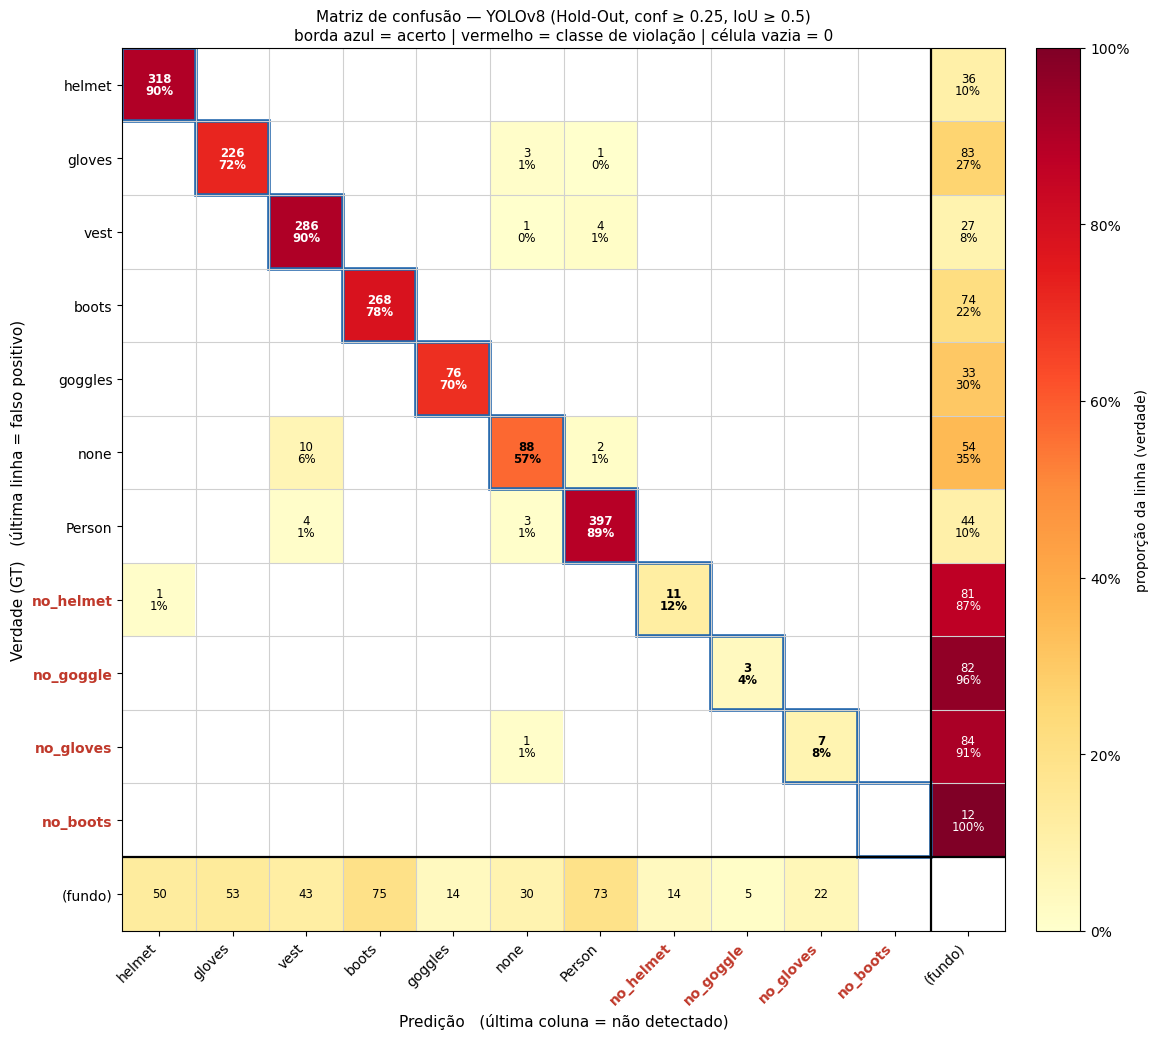


Maiores erros — YOLOv8:


,verdade,predito,n,tipo
0,no_gloves,(fundo),84,não detectado
1,gloves,(fundo),83,não detectado
2,no_goggle,(fundo),82,não detectado
3,no_helmet,(fundo),81,não detectado
4,(fundo),boots,75,falso positivo
5,boots,(fundo),74,não detectado
6,(fundo),Person,73,falso positivo
7,none,(fundo),54,não detectado
8,(fundo),gloves,53,falso positivo
9,(fundo),helmet,50,falso positivo


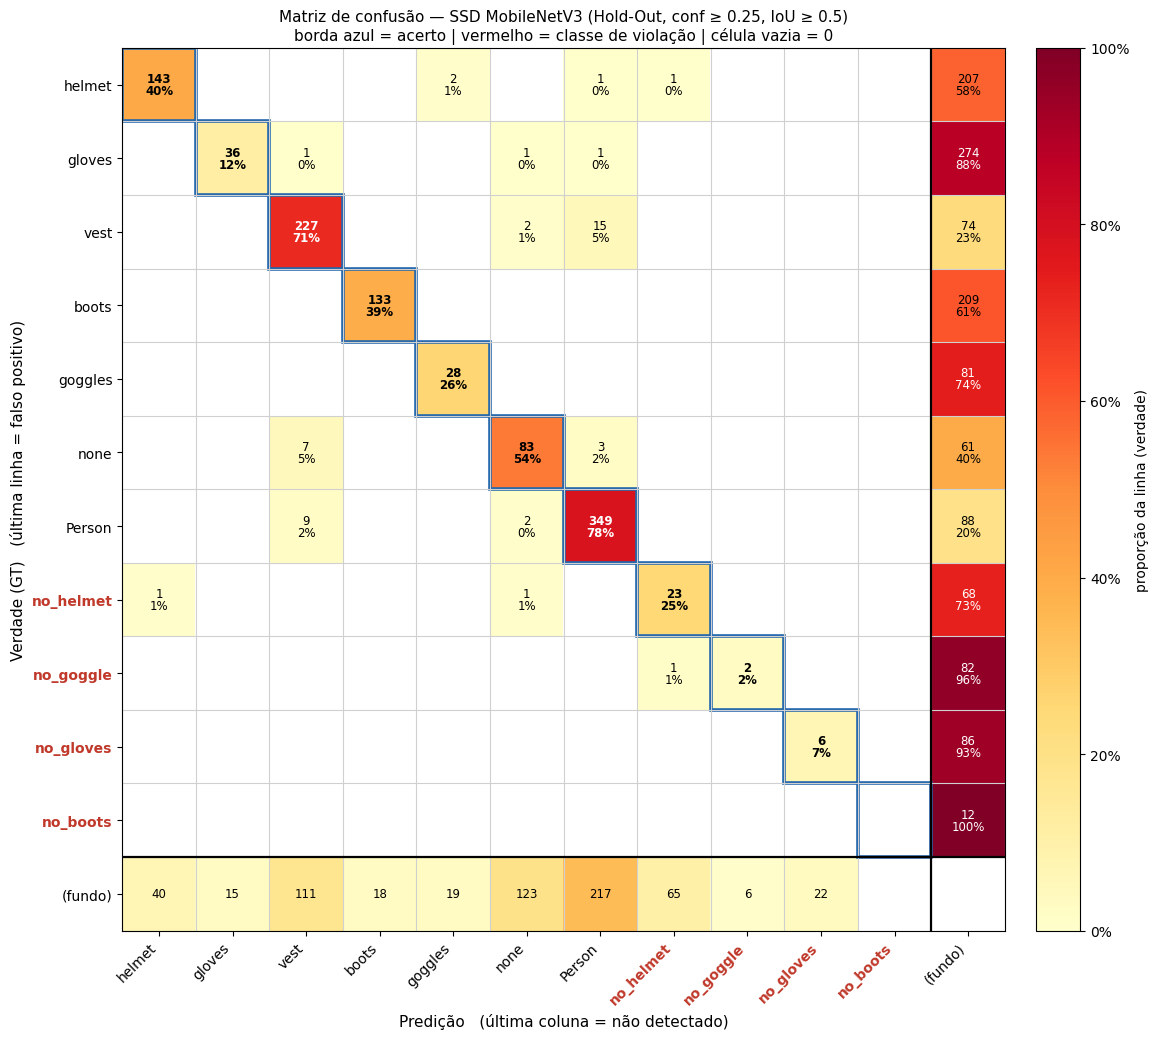


Maiores erros — SSD MobileNetV3:


,verdade,predito,n,tipo
0,gloves,(fundo),274,não detectado
1,(fundo),Person,217,falso positivo
2,boots,(fundo),209,não detectado
3,helmet,(fundo),207,não detectado
4,(fundo),none,123,falso positivo
5,(fundo),vest,111,falso positivo
6,Person,(fundo),88,não detectado
7,no_gloves,(fundo),86,não detectado
8,no_goggle,(fundo),82,não detectado
9,goggles,(fundo),81,não detectado


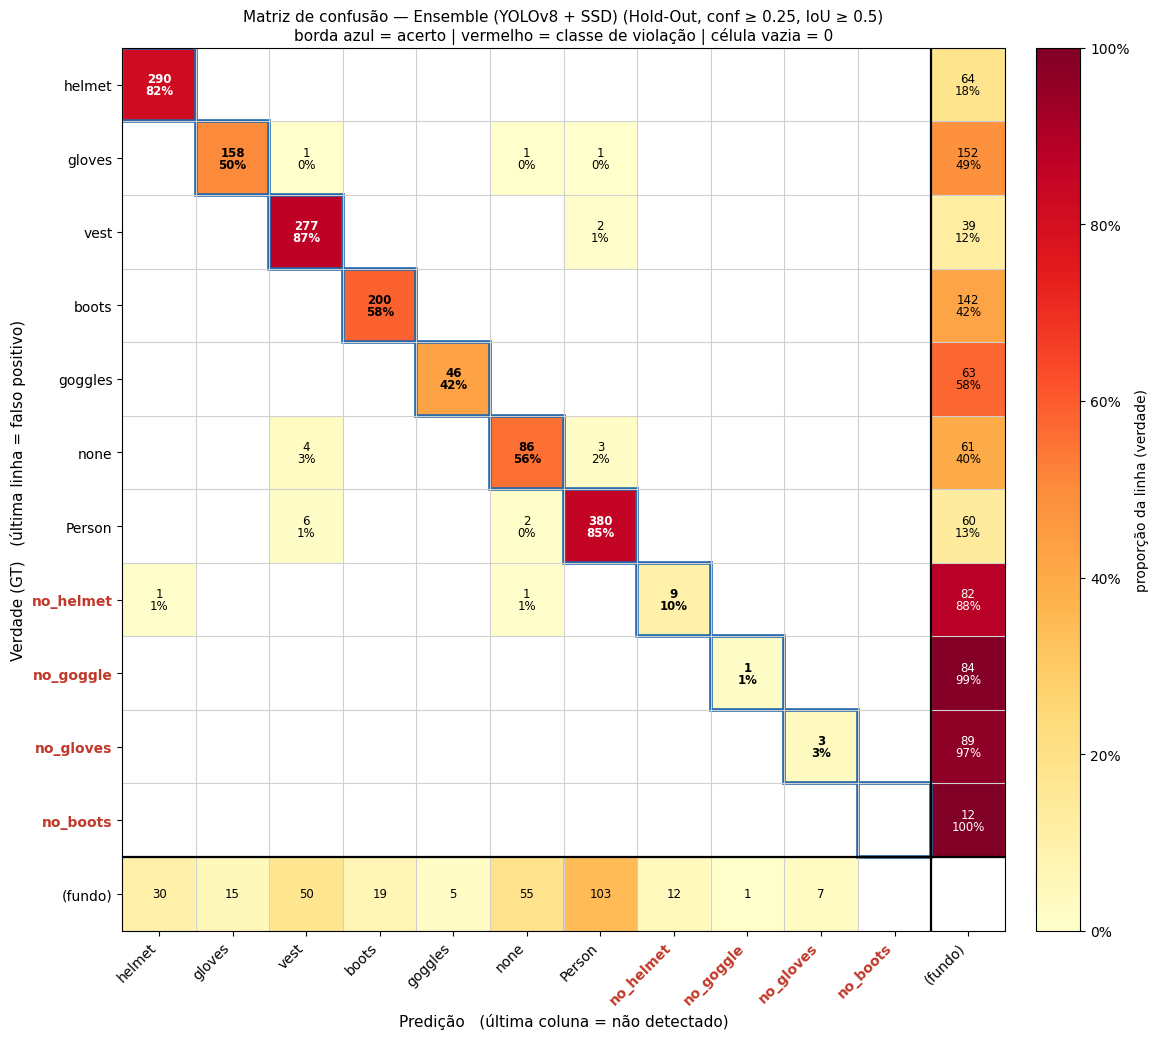


Maiores erros — Ensemble (YOLOv8 + SSD):


,verdade,predito,n,tipo
0,gloves,(fundo),152,não detectado
1,boots,(fundo),142,não detectado
2,(fundo),Person,103,falso positivo
3,no_gloves,(fundo),89,não detectado
4,no_goggle,(fundo),84,não detectado
5,no_helmet,(fundo),82,não detectado
6,helmet,(fundo),64,não detectado
7,goggles,(fundo),63,não detectado
8,none,(fundo),61,não detectado
9,Person,(fundo),60,não detectado


In [30]:
# ==== Parte 9d · Matriz de confusão de detecção (Hold-Out) ====
# Rodar depois da Parte 9c (usa HOLDOUT_PREDS / HOLDOUT_GTS calculados lá).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BACKGROUND = "(fundo)"


def detection_confusion_matrix(preds, gts, n_cls, conf_thr=CONF_THR, iou_thr=IOU_THR):
    """Matriz [verdade × predição] de detecção. O casamento predição↔GT usa IoU >= iou_thr e IGNORA a classe,
    para revelar as confusões entre classes (ex.: no_helmet predito como none).
      - M[c, k]  : objeto de classe verdadeira c detectado como classe k (c == k: acerto)
      - M[n, k]  : predição de classe k sem objeto correspondente (falso positivo)
      - M[c, n]  : objeto de classe c não detectado (falso negativo)"""
    M = np.zeros((n_cls + 1, n_cls + 1), dtype=int)
    for p, g in zip(preds, gts):
        m = match_image(p, g, conf_thr, iou_thr, class_aware=False)
        for i, j in m["tp"]:
            M[int(m["gl"][j]), int(m["pl"][i])] += 1
        for i in m["fp"]:
            M[n_cls, int(m["pl"][i])] += 1
        for j in m["fn"]:
            M[int(m["gl"][j]), n_cls] += 1
    return M


def top_confusions(M, n=10, min_count=1):
    labels = list(CLASS_NAMES) + [BACKGROUND]
    rows = []
    for t in range(M.shape[0]):
        for k in range(M.shape[1]):
            if t != k and M[t, k] >= min_count:
                kind = ("falso positivo" if t == len(CLASS_NAMES) else
                        "não detectado" if k == len(CLASS_NAMES) else "troca de classe")
                rows.append({"verdade": labels[t], "predito": labels[k], "n": int(M[t, k]), "tipo": kind})
    df = pd.DataFrame(rows, columns=["verdade", "predito", "n", "tipo"])
    return df.sort_values("n", ascending=False).head(n).reset_index(drop=True)


CONFUSION_CMAP = "YlOrRd"   # mapa de cores da matriz (bom contraste também em impressão P&B); ex.: "viridis", "magma_r"


def plot_confusion(M, title, path, cmap=CONFUSION_CMAP):
    """Matriz de confusão legível: cor = proporção da linha (0–100%), texto = contagem + %, zeros em branco,
    diagonal (acertos) com borda azul, linha/coluna de fundo separadas e classes de violação em vermelho."""
    from matplotlib.colors import to_rgb
    from matplotlib.patches import Rectangle

    labels = list(CLASS_NAMES) + [BACKGROUND]
    n = len(labels)
    row_sum = M.sum(axis=1, keepdims=True)
    norm = np.divide(M, row_sum, out=np.zeros_like(M, dtype=float), where=row_sum > 0)
    shown = np.ma.masked_where(M == 0, norm)            # zeros ficam em branco (não poluem a leitura)
    cm = plt.get_cmap(cmap).copy()
    cm.set_bad("white")

    fig, ax = plt.subplots(figsize=(12, 10.5))
    im = ax.imshow(shown, cmap=cm, vmin=0, vmax=1)

    # grade branca entre as células
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="#d0d0d0", linewidth=0.8)
    ax.tick_params(which="minor", length=0)
    # separa a linha/coluna de "(fundo)" do resto
    ax.axhline(n - 1.5, color="black", lw=1.6)
    ax.axvline(n - 1.5, color="black", lw=1.6)

    for t in range(n):
        for k in range(n):
            if M[t, k] == 0:
                continue
            r, g, b = to_rgb(cm(norm[t, k]))
            lum = 0.299 * r + 0.587 * g + 0.114 * b     # texto branco em fundo escuro, preto em fundo claro
            txt_color = "white" if lum < 0.5 else "black"
            pct = f"\n{100 * norm[t, k]:.0f}%" if t < n - 1 else ""   # % não faz sentido na linha de FP
            ax.text(k, t, f"{M[t, k]}{pct}", ha="center", va="center", fontsize=8.5,
                    color=txt_color, fontweight="bold" if t == k else "normal", linespacing=0.9)
    for d in range(n - 1):                                # destaca a diagonal (acertos)
        ax.add_patch(Rectangle((d - 0.5, d - 0.5), 1, 1, fill=False, edgecolor="#2166ac", lw=2.6))

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    for i, (xl, yl) in enumerate(zip(ax.get_xticklabels(), ax.get_yticklabels())):
        if i in VIOLATION_CLASS_IDS:
            xl.set_color("#c0392b"); yl.set_color("#c0392b")
            xl.set_fontweight("bold"); yl.set_fontweight("bold")
    ax.set_xlabel("Predição   (última coluna = não detectado)", fontsize=11)
    ax.set_ylabel("Verdade (GT)   (última linha = falso positivo)", fontsize=11)
    ax.set_title(title + "\nborda azul = acerto | vermelho = classe de violação | célula vazia = 0", fontsize=11)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label("proporção da linha (verdade)", fontsize=10)
    cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{100 * v:.0f}%"))
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


# ---- execução ----
if "HOLDOUT_PREDS" not in globals():
    print("⚠️ Rode a Parte 9c antes (ele gera HOLDOUT_PREDS e HOLDOUT_GTS).")
else:
    n_cls = len(CLASS_NAMES)
    CONFUSION = {}
    for m in MODEL_ORDER:
        M = detection_confusion_matrix(HOLDOUT_PREDS[m], HOLDOUT_GTS, n_cls)
        CONFUSION[m] = M
        pd.DataFrame(M, index=list(CLASS_NAMES) + [BACKGROUND], columns=list(CLASS_NAMES) + [BACKGROUND]) \
            .to_csv(f"{PROJECT_DIR}/matriz_confusao_{m.split(' ')[0].lower()}.csv")
        plot_confusion(M, f"Matriz de confusão — {m} (Hold-Out, conf ≥ {CONF_THR}, IoU ≥ {IOU_THR})",
                       f"{PROJECT_DIR}/matriz_confusao_{m.split(' ')[0].lower()}.png")
        print(f"\nMaiores erros — {m}:")
        display(top_confusions(M, n=10))

## Parte 9e · Erros por imagem e galeria de casos relevantes

Seleciona (a) as imagens em que mais se erra violação e (b) as em que os três modelos mais **divergem**, e desenha um abaixo do outro: azul = acerto, laranja = falso positivo, vermelho = objeto não detectado. Requer a Parte 9c.
Escolha 3–6 figuras e **escreva o porquê de cada erro** no relatório — o código entrega o material; a interpretação é sua.

> ⚠️ **Privacidade:** as figuras mostram pessoas. Não as publique no repositório sem checar a licença do dataset e considerar borrar os rostos.

In [31]:
# ==== Parte 9e · Erros por imagem e galeria de casos relevantes (Hold-Out) ====
# Rodar depois da Parte 9c. Gera as figuras para a "análise qualitativa dos erros" do relatório.
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

N_HARD = 4       # imagens em que mais se erra violação (soma dos três modelos)
N_DIVERGE = 4    # imagens em que os modelos mais DIVERGEM sobre violações
PANEL_W = 640

C_TP = (255, 90, 0)     # BGR: azul   = detecção correta
C_FP = (0, 140, 255)    # BGR: laranja = falso positivo
C_FN = (0, 0, 255)      # BGR: vermelho = objeto do gabarito NÃO detectado


def per_image_errors(preds, gts, model_name, conf_thr=CONF_THR):
    rows = []
    for pos, (p, g) in enumerate(zip(preds, gts)):
        m = match_image(p, g, conf_thr)
        fp_v = sum(int(m["pl"][i]) in VIOLATION_CLASS_IDS for i in m["fp"])
        fn_v = sum(int(m["gl"][j]) in VIOLATION_CLASS_IDS for j in m["fn"])
        rows.append({"pos": pos, "modelo": model_name, "tp": len(m["tp"]), "fp": len(m["fp"]), "fn": len(m["fn"]),
                     "fp_violacao": fp_v, "fn_violacao": fn_v, "erros_violacao": fp_v + fn_v})
    return pd.DataFrame(rows)


def select_cases(err_df, n_hard=N_HARD, n_diverge=N_DIVERGE):
    piv = err_df.pivot(index="pos", columns="modelo", values="erros_violacao")
    piv = piv[[m for m in MODEL_ORDER if m in piv.columns]]
    hard_s = piv.sum(axis=1).sort_values(ascending=False, kind="stable")
    hard = hard_s[hard_s > 0].head(n_hard).index.tolist()
    spread = (piv.max(axis=1) - piv.min(axis=1)).sort_values(ascending=False, kind="stable")
    diverge = [i for i in spread[spread > 0].index if i not in hard][:n_diverge]
    return hard, diverge


def draw_error_panel(img_bgr, pred, gt, conf_thr=CONF_THR, max_w=PANEL_W):
    """Azul = acerto | laranja = falso positivo | vermelho = objeto não detectado (FN)."""
    m = match_image(pred, gt, conf_thr)
    out = img_bgr.copy()
    h, w = out.shape[:2]
    th = max(2, int(round(min(h, w) / 300)))
    fs = max(0.5, min(h, w) / 900)

    def box(b, color, text):
        x1, y1, x2, y2 = [int(round(v)) for v in b]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, th)
        cv2.putText(out, text, (x1, max(12, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, fs, color, max(1, th - 1), cv2.LINE_AA)

    tp_pred = {i for i, _ in m["tp"]}
    for i in range(len(m["pb"])):
        name = CLASS_NAMES[int(m["pl"][i])]
        box(m["pb"][i], C_TP if i in tp_pred else C_FP, f"{name} {m['ps'][i]:.2f}")
    for j in m["fn"]:
        box(m["gb"][j], C_FN, f"FN: {CLASS_NAMES[int(m['gl'][j])]}")
    if w > max_w:
        out = cv2.resize(out, (max_w, int(round(h * max_w / w))), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)


def save_case_figure(pos, preds_by_model, gts, paths, err_df, out_path, title):
    img = cv2.imread(paths[pos])
    if img is None:
        print(f"  ⚠️ não consegui abrir {paths[pos]}")
        return
    fig, axes = plt.subplots(len(MODEL_ORDER), 1, figsize=(8, 6.2 * len(MODEL_ORDER)))   # um painel abaixo do outro
    for ax, m in zip(np.atleast_1d(axes), MODEL_ORDER):
        ax.imshow(draw_error_panel(img, preds_by_model[m][pos], gts[pos]))
        e = err_df[(err_df["pos"] == pos) & (err_df["modelo"] == m)].iloc[0]
        ax.set_title(f"{m}\nFN violação: {e['fn_violacao']} | FP violação: {e['fp_violacao']}", fontsize=10)
        ax.axis("off")
    fig.suptitle(f"{title} — {os.path.basename(paths[pos])}   (azul = acerto, laranja = FP, vermelho = FN)", fontsize=11)
    plt.tight_layout()
    plt.savefig(out_path, dpi=110)
    if globals().get("MOSTRAR_FIGURAS_COM_PESSOAS", False):   # definida na Parte 3c (padrão False)
        plt.show()
    else:
        plt.close(fig)


# ---- execução ----
if "HOLDOUT_PREDS" not in globals():
    print("⚠️ Rode a Parte 9c antes (ele gera HOLDOUT_PREDS, HOLDOUT_GTS e HOLDOUT_PATHS).")
else:
    gal_dir = f"{PROJECT_DIR}/analise_erros"
    os.makedirs(gal_dir, exist_ok=True)

    err_df = pd.concat([per_image_errors(HOLDOUT_PREDS[m], HOLDOUT_GTS, m) for m in MODEL_ORDER], ignore_index=True)
    err_df["imagem"] = err_df["pos"].map(lambda p: os.path.basename(HOLDOUT_PATHS[p]))
    err_df.to_csv(f"{PROJECT_DIR}/erros_por_imagem_holdout.csv", index=False)
    print("Erros de violação (FP + FN) por modelo, somados no Hold-Out:")
    display(err_df.groupby("modelo")[["fp_violacao", "fn_violacao", "erros_violacao"]].sum().reindex(MODEL_ORDER))

    hard, diverge = select_cases(err_df)
    print(f"\nCasos mais difíceis (posições no Hold-Out): {hard} | casos de maior divergência: {diverge}")
    for pos in hard:
        save_case_figure(pos, HOLDOUT_PREDS, HOLDOUT_GTS, HOLDOUT_PATHS, err_df,
                         f"{gal_dir}/dificil_{pos}.png", "Caso difícil")
    for pos in diverge:
        save_case_figure(pos, HOLDOUT_PREDS, HOLDOUT_GTS, HOLDOUT_PATHS, err_df,
                         f"{gal_dir}/divergencia_{pos}.png", "Modelos divergem")
    print(f"\nFiguras salvas em {gal_dir}. Escolha 3-6 e comente no relatório: por que errou? (oclusão, "
          "objeto pequeno, ângulo, luz, rótulo ambíguo, confusão com `none`...)")
    print("⚠️ Privacidade: se as imagens mostram rostos identificáveis, não publique as figuras no repositório "
          "sem checar a licença do dataset e considerar borrar os rostos.")
    if not globals().get("MOSTRAR_FIGURAS_COM_PESSOAS", False):
        print("(as figuras foram salvas mas não exibidas, por conterem pessoas; defina MOSTRAR_FIGURAS_COM_PESSOAS = True na Parte 3c para exibi-las)")


Erros de violação (FP + FN) por modelo, somados no Hold-Out:


,fp_violacao,fn_violacao,erros_violacao
modelo,,,
YOLOv8,41,261,302
SSD MobileNetV3,93,249,342
Ensemble (YOLOv8 + SSD),20,269,289



Casos mais difíceis (posições no Hold-Out): [117, 241, 166, 49] | casos de maior divergência: [247, 79, 280, 2]

Figuras salvas em /content/drive/MyDrive/epi_experimento/analise_erros. Escolha 3-6 e comente no relatório: por que errou? (oclusão, objeto pequeno, ângulo, luz, rótulo ambíguo, confusão com `none`...)
⚠️ Privacidade: se as imagens mostram rostos identificáveis, não publique as figuras no repositório sem checar a licença do dataset e considerar borrar os rostos.
(as figuras foram salvas mas não exibidas, por conterem pessoas; defina MOSTRAR_FIGURAS_COM_PESSOAS = True na Parte 3c para exibi-las)


## Parte 9f · Análise qualitativa quantificada dos erros de violação

Transforma a pergunta "por que errou?" em categorias mensuráveis para cada objeto de violação do gabarito: **detectado**, **abaixo do limiar** (o modelo viu, mas com pouca confiança), **classe trocada**, **localização** ruim (IoU < 0,5), **predição já usada** ou **não detectado**. Depois cruza com o **tamanho** do objeto e a **aglomeração** da imagem (nº de pessoas anotadas). Complementa a matriz de confusão (9d) e a galeria (9e), que continuam sendo a base da interpretação visual.

Objetos de violação no gabarito do Hold-Out: 282

O que aconteceu com cada objeto de violação (% por abordagem):


categoria,detectado,abaixo do limiar,classe trocada,"localização (IoU<0,5)",predição já usada,não detectado
modelo,,,,,,
YOLOv8,7.4,64.9,0.0,3.5,0.0,24.1
SSD MobileNetV3,11.7,40.8,0.0,4.6,0.0,42.9
Ensemble (YOLOv8 + SSD),4.6,67.0,0.0,1.1,0.0,27.3


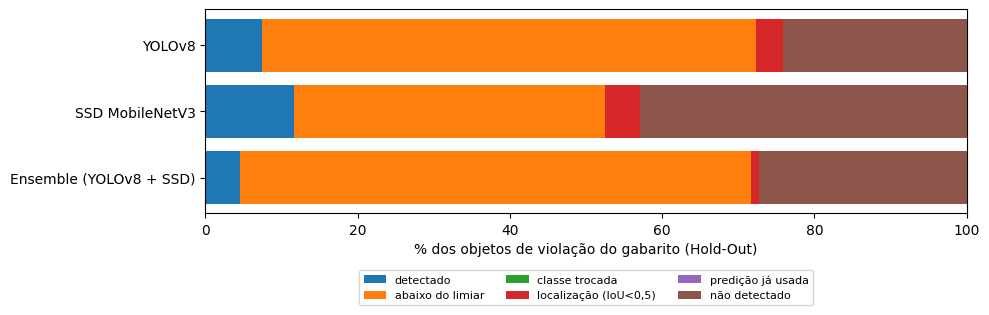


% detectado por tamanho do objeto (pequena < 32px, média < 96px, grande, a 640x640):


,modelo,tamanho,n objetos,% detectado
0,Ensemble (YOLOv8 + SSD),pequena,26,0.0
1,Ensemble (YOLOv8 + SSD),média,191,2.1
2,Ensemble (YOLOv8 + SSD),grande,65,13.8
3,SSD MobileNetV3,pequena,26,0.0
4,SSD MobileNetV3,média,191,3.1
5,SSD MobileNetV3,grande,65,41.5
6,YOLOv8,pequena,26,0.0
7,YOLOv8,média,191,7.9
8,YOLOv8,grande,65,9.2



% detectado por aglomeração (nº de pessoas anotadas na imagem):


,modelo,aglomeração,n objetos,% detectado
0,Ensemble (YOLOv8 + SSD),≤2 pessoas,187,7.0
1,Ensemble (YOLOv8 + SSD),3–5 pessoas,59,0.0
2,Ensemble (YOLOv8 + SSD),≥6 pessoas,36,0.0
3,SSD MobileNetV3,≤2 pessoas,187,15.5
4,SSD MobileNetV3,3–5 pessoas,59,6.8
5,SSD MobileNetV3,≥6 pessoas,36,0.0
6,YOLOv8,≤2 pessoas,187,9.1
7,YOLOv8,3–5 pessoas,59,5.1
8,YOLOv8,≥6 pessoas,36,2.8



Por classe de violação — YOLOv8:


categoria,detectado,abaixo do limiar,classe trocada,"localização (IoU<0,5)",predição já usada,não detectado
classe,,,,,,
no_boots,0,2,0,0,0,10
no_gloves,7,54,0,8,0,23
no_goggle,3,56,0,1,0,25
no_helmet,11,71,0,1,0,10



Como ler: 'não detectado' = o modelo não viu o objeto; 'abaixo do limiar' = viu, mas com pouca confiança (candidato a limiar por classe — veja a Parte 9g); 'classe trocada' = confundiu com outra classe.
Fração dos objetos de violação recuperável só baixando o limiar: YOLOv8: 64.9%, SSD MobileNetV3: 40.8%, Ensemble (YOLOv8 + SSD): 67.0%


In [32]:
# ==== Parte 9f · Análise qualitativa quantificada dos erros de violação (Hold-Out) ====
# Rodar depois da Parte 9c (usa HOLDOUT_PREDS / HOLDOUT_GTS / HOLDOUT_PATHS e as funções de lá).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

PERSON_ID = CLASS_NAMES.index("Person")
SMALL_FRAC = (32 / 640) ** 2      # convenção COCO (objeto pequeno < 32x32 px) reescalada para 640x640
MEDIUM_FRAC = (96 / 640) ** 2     # médio < 96x96 px
CATEGORIES = ["detectado", "abaixo do limiar", "classe trocada", "localização (IoU<0,5)",
              "predição já usada", "não detectado"]


def violation_gt_outcomes(pred, gt, size_wh, conf_thr=CONF_THR, iou_thr=IOU_THR):
    """Para cada objeto de VIOLAÇÃO do gabarito, diz o que aconteceu (categorias mutuamente exclusivas):
      detectado               : casou com uma predição da mesma classe (score >= limiar, IoU >= 0,5)
      abaixo do limiar        : existe predição da mesma classe com IoU >= 0,5, mas com score < limiar
                                (recuperável baixando o limiar — ao custo de mais falsos positivos)
      predição já usada       : predição correta existe, mas foi consumida por outro objeto (sobreposição)
      classe trocada          : há predição de OUTRA classe sobre o objeto (IoU >= 0,5, score >= limiar)
      localização (IoU<0,5)   : predição da mesma classe, mas mal localizada (0,1 <= IoU < 0,5)
      não detectado           : nenhuma predição relevante (o modelo simplesmente não viu)"""
    m = match_image(pred, gt, conf_thr, iou_thr)
    tp_gt = {j for _, j in m["tp"]}
    pb = _to_np(pred["boxes"]).reshape(-1, 4)
    ps = _to_np(pred["scores"]).reshape(-1)
    pl = _to_np(pred["labels"]).reshape(-1).astype(int)
    gb, gl = m["gb"], m["gl"]
    ious = _iou_matrix(gb, pb) if len(gb) and len(pb) else np.zeros((len(gb), len(pb)))
    W, H = size_wh
    n_person = int((gl == PERSON_ID).sum())
    rows = []
    for j in range(len(gb)):
        if int(gl[j]) not in VIOLATION_CLASS_IDS:
            continue
        area = float((gb[j, 2] - gb[j, 0]) * (gb[j, 3] - gb[j, 1])) / float(W * H)
        if j in tp_gt:
            cat = "detectado"
        else:
            same, hit, near = (pl == gl[j]), ious[j] >= iou_thr, ious[j] >= 0.1
            hi = ps >= conf_thr
            if (same & hit & ~hi).any():
                cat = "abaixo do limiar"
            elif (same & hit & hi).any():
                cat = "predição já usada"
            elif ((~same) & hit & hi).any():
                cat = "classe trocada"
            elif (same & near & hi).any():
                cat = "localização (IoU<0,5)"
            else:
                cat = "não detectado"
        rows.append({"classe": CLASS_NAMES[int(gl[j])], "categoria": cat, "area_frac": area, "n_pessoas": n_person})
    return rows


def violation_outcomes_df(preds, gts, paths, model_name, conf_thr=CONF_THR):
    rows = []
    for pos, (p, g, path) in enumerate(zip(preds, gts, paths)):
        size_wh = Image.open(path).size
        for r in violation_gt_outcomes(p, g, size_wh, conf_thr):
            r.update(pos=pos, modelo=model_name)
            rows.append(r)
    df = pd.DataFrame(rows, columns=["classe", "categoria", "area_frac", "n_pessoas", "pos", "modelo"])
    df["tamanho"] = pd.cut(df["area_frac"], [0, SMALL_FRAC, MEDIUM_FRAC, np.inf],
                           labels=["pequena", "média", "grande"], right=False)
    df["aglomeração"] = pd.cut(df["n_pessoas"], [-1, 2, 5, np.inf], labels=["≤2 pessoas", "3–5 pessoas", "≥6 pessoas"])
    return df


def summarize_outcomes(df):
    df = df.reset_index(drop=True)
    cat = (pd.crosstab(df["modelo"], df["categoria"], normalize="index") * 100).reindex(
        index=[m for m in MODEL_ORDER if m in set(df["modelo"])], columns=CATEGORIES, fill_value=0.0)

    def rate(col):
        out = df.groupby(["modelo", col], observed=True).agg(
            **{"n objetos": ("categoria", "size"),
               "% detectado": ("categoria", lambda s: 100 * (s == "detectado").mean())})
        return out.reset_index()

    return cat, rate("tamanho"), rate("aglomeração")


def plot_outcomes(cat, path):
    fig, ax = plt.subplots(figsize=(10, 3.4))
    left = np.zeros(len(cat))
    for c in CATEGORIES:
        ax.barh(cat.index, cat[c].values, left=left, label=c)
        left += cat[c].values
    ax.set_xlabel("% dos objetos de violação do gabarito (Hold-Out)")
    ax.set_xlim(0, 100)
    ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.25))
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


# ---- execução ----
if "HOLDOUT_PREDS" not in globals():
    print("⚠️ Rode a Parte 9c antes (ela gera HOLDOUT_PREDS, HOLDOUT_GTS e HOLDOUT_PATHS).")
else:
    TAXON_DF = pd.concat([violation_outcomes_df(HOLDOUT_PREDS[m], HOLDOUT_GTS, HOLDOUT_PATHS, m)
                          for m in MODEL_ORDER], ignore_index=True)
    TAXON_DF.to_csv(f"{PROJECT_DIR}/taxonomia_violacao_holdout.csv", index=False)
    TAXON_SUMMARY, SIZE_TAB, CROWD_TAB = summarize_outcomes(TAXON_DF)

    n_obj = TAXON_DF[TAXON_DF["modelo"] == MODEL_ORDER[0]].shape[0]
    print(f"Objetos de violação no gabarito do Hold-Out: {n_obj}\n")
    print("O que aconteceu com cada objeto de violação (% por abordagem):")
    display(TAXON_SUMMARY.round(1))
    plot_outcomes(TAXON_SUMMARY, f"{PROJECT_DIR}/taxonomia_violacao_holdout.png")

    print("\n% detectado por tamanho do objeto (pequena < 32px, média < 96px, grande, a 640x640):")
    display(SIZE_TAB.round(1))
    print("\n% detectado por aglomeração (nº de pessoas anotadas na imagem):")
    display(CROWD_TAB.round(1))

    print("\nPor classe de violação — YOLOv8:")
    display((pd.crosstab(TAXON_DF[TAXON_DF["modelo"] == MODEL_ORDER[0]]["classe"],
                         TAXON_DF[TAXON_DF["modelo"] == MODEL_ORDER[0]]["categoria"])
             .reindex(columns=CATEGORIES, fill_value=0)))

    rec = TAXON_SUMMARY["abaixo do limiar"]
    print("\nComo ler: 'não detectado' = o modelo não viu o objeto; 'abaixo do limiar' = viu, mas com pouca confiança "
          "(candidato a limiar por classe — veja a Parte 9g); 'classe trocada' = confundiu com outra classe.")
    print("Fração dos objetos de violação recuperável só baixando o limiar: "
          + ", ".join(f"{m}: {rec[m]:.1f}%" for m in rec.index))

## Parte 9g · Limiar por classe de violação (experimento exploratório, sem vazamento)

O limiar fixo de 0,25 é um ponto de operação ruim para classes raras, cujas confianças são baixas. Aqui o limiar de cada classe de violação é escolhido em predições **fora-da-amostra** (cada imagem de desenvolvimento predita pelo modelo do fold em que foi teste) e aplicado **uma vez** ao Hold-Out. O mAP não muda; muda o ponto de operação. Ative/desative com `RUN_THRESHOLD_EXPERIMENT`; as predições ficam em cache (`oof_predictions.pkl`).

**Três critérios de alerta por imagem** (do mais permissivo ao mais estrito): *permissivo* — basta prever qualquer classe de violação; *por classe* — a classe prevista precisa existir no gabarito da imagem; *por caixa* — ao menos uma caixa de violação correta (classe certa, IoU ≥ 0,5). O critério permissivo é o das Partes 9c e 9h e tende a superestimar o recall; reporte os três.


Predições OOF carregadas de /content/drive/MyDrive/epi_experimento/oof_predictions.pkl (apague o arquivo para recalcular).
Imagens OOF: 1132 de 1132 do desenvolvimento.

Limiar escolhido por classe (OOF) e efeito no Hold-Out (HO):


,modelo,classe,limiar escolhido (OOF),obs.,"F1 OOF @0,25",F1 OOF @escolhido,"recall HO @0,25",recall HO @escolhido,"precision HO @0,25",precision HO @escolhido,"F1 HO @0,25",F1 HO @escolhido
0,YOLOv8,no_helmet,0.125,,0.159,0.269,0.118,0.419,0.440,0.382,0.186,0.400
1,YOLOv8,no_goggle,0.100,,0.072,0.191,0.035,0.176,0.375,0.188,0.065,0.182
2,YOLOv8,no_gloves,0.100,,0.134,0.228,0.076,0.217,0.241,0.182,0.116,0.198
3,YOLOv8,no_boots,0.075,,0.017,0.065,0.000,0.083,0.000,0.125,0.000,0.100
4,SSD MobileNetV3,no_helmet,0.225,,0.219,0.230,0.269,0.280,0.278,0.250,0.273,0.264
5,SSD MobileNetV3,no_goggle,0.075,,0.017,0.110,0.024,0.165,0.250,0.107,0.043,0.130
6,SSD MobileNetV3,no_gloves,0.100,,0.069,0.094,0.065,0.141,0.214,0.093,0.100,0.112
7,SSD MobileNetV3,no_boots,0.250,sem sinal (F1=0),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,Ensemble (YOLOv8 + SSD),no_helmet,0.100,,0.158,0.249,0.097,0.462,0.429,0.270,0.158,0.341
9,Ensemble (YOLOv8 + SSD),no_goggle,0.075,,0.006,0.185,0.012,0.153,0.500,0.178,0.023,0.165



Alerta por imagem no Hold-Out: limiar padrão × por classe, com três critérios de acerto
(o critério 'permissivo' é o das Partes 9c/9h; 'por classe' e 'por caixa' são mais estritos):


,modelo,limiares,critério,tp,fp,fn,tn,precision,recall,f1
0,YOLOv8,"0,25 (padrão)",permissivo (qualquer classe de violação),35,0,24,225,1.000,0.593,0.745
1,YOLOv8,"0,25 (padrão)",por classe (a classe prevista existe no gabarito),32,0,27,225,1.000,0.542,0.703
2,YOLOv8,"0,25 (padrão)","por caixa (≥1 caixa correta: classe + IoU ≥ 0,5)",19,0,40,225,1.000,0.322,0.487
3,YOLOv8,por classe (OOF),permissivo (qualquer classe de violação),56,4,3,221,0.933,0.949,0.941
4,YOLOv8,por classe (OOF),por classe (a classe prevista existe no gabarito),55,4,4,221,0.932,0.932,0.932
5,YOLOv8,por classe (OOF),"por caixa (≥1 caixa correta: classe + IoU ≥ 0,5)",39,4,20,221,0.907,0.661,0.765
6,SSD MobileNetV3,"0,25 (padrão)",permissivo (qualquer classe de violação),39,1,20,224,0.975,0.661,0.788
7,SSD MobileNetV3,"0,25 (padrão)",por classe (a classe prevista existe no gabarito),38,1,21,224,0.974,0.644,0.776
8,SSD MobileNetV3,"0,25 (padrão)","por caixa (≥1 caixa correta: classe + IoU ≥ 0,5)",26,1,33,224,0.963,0.441,0.605
9,SSD MobileNetV3,por classe (OOF),permissivo (qualquer classe de violação),49,3,10,222,0.942,0.831,0.883


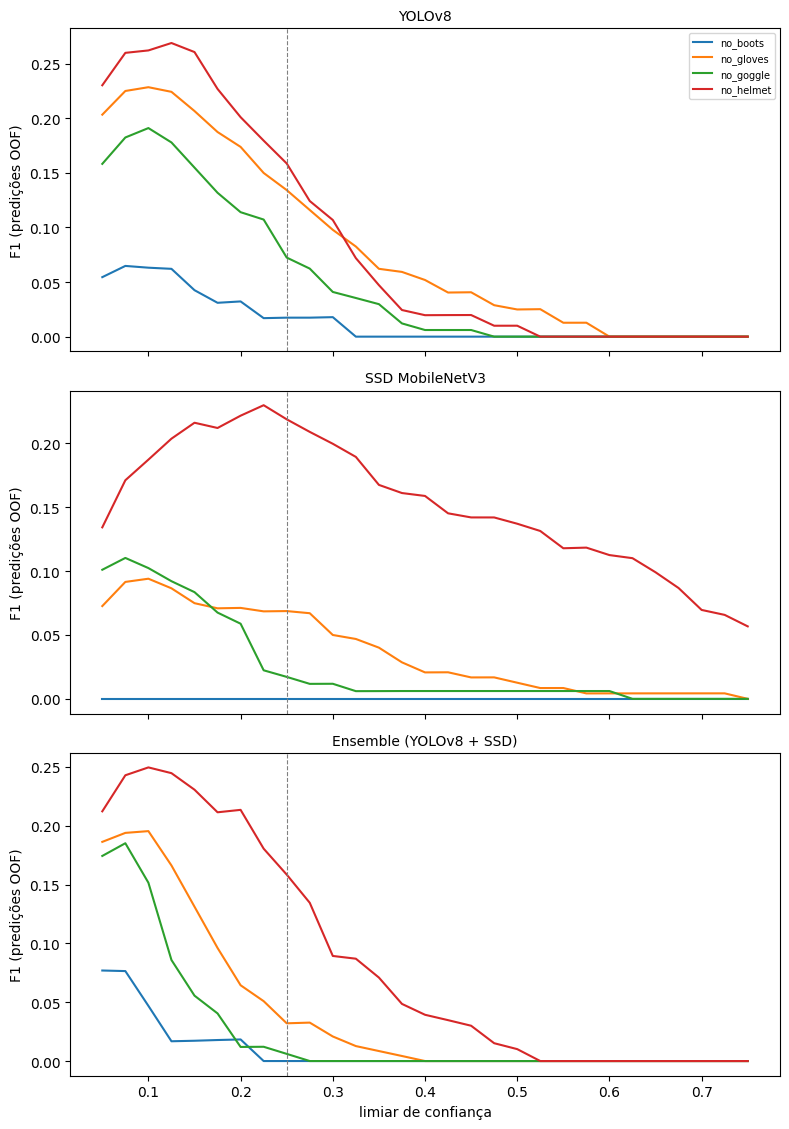


Cuidados: (i) exploratório — reporte como tal; (ii) as predições OOF vêm de 10 modelos treinados em 90% do desenvolvimento, enquanto o Hold-Out usa o modelo final treinado em 100% (a calibração das confianças pode diferir um pouco); (iii) o Hold-Out tem poucas instâncias por classe de violação — veja os ICs na Parte 9h.


In [33]:
# ==== Parte 9g · Limiar por classe de violação (escolhido fora-da-amostra, avaliado no Hold-Out) ====
# Rodar depois da Parte 9c. Experimento EXPLORATÓRIO: o mAP não muda (não depende do limiar); o que muda é o
# ponto de operação (Precision/Recall/F1 e o alerta por imagem).
#
# Protocolo sem vazamento:
#   1) predições "fora-da-amostra" (OOF): cada imagem de desenvolvimento é predita pelo modelo do fold em que
#      ela foi TESTE (isto é, um modelo que não a viu no treino);
#   2) para cada classe de violação e cada abordagem, escolhe-se o limiar que maximiza o F1 nas predições OOF;
#   3) o limiar fixado é aplicado UMA vez ao Hold-Out (que não participa da escolha).
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUN_THRESHOLD_EXPERIMENT = True          # ~5-10 min na primeira vez (as predições OOF ficam em cache)
THR_GRID = np.round(np.arange(0.05, 0.7501, 0.025), 3)
OOF_CACHE = f"{PROJECT_DIR}/oof_predictions.pkl"
VIOLATION_IDS = sorted(VIOLATION_CLASS_IDS)


def _pack(d):
    return {k: _to_np(v) for k, v in d.items()}


def collect_oof_predictions(cache_path=OOF_CACHE):
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            print(f"Predições OOF carregadas de {cache_path} (apague o arquivo para recalcular).")
            return pickle.load(f)
    preds = {m: [] for m in MODEL_ORDER}
    gts, fold_of, versions = [], [], []
    for fold_id, (_, test_idx) in enumerate(folds):
        yw, tg = resolve_yolo_weights("fold", fold_id)
        sw = resolve_ssd_weights("fold", fold_id)
        if yw is None or sw is None:
            print(f"  ⚠️ fold {fold_id}: pesos não encontrados — pulado (o OOF ficará incompleto).")
            continue
        print(f"  fold {fold_id}: YOLO {tg}")
        out, g, _ = predict_three(test_idx, yw, sw)
        for m in MODEL_ORDER:
            preds[m].extend(_pack(p) for p in out[m])
        gts.extend(_pack(x) for x in g)
        fold_of.extend([fold_id] * len(g))
        versions.append(tg)
    data = {"preds": preds, "gts": gts, "fold": np.array(fold_of), "yolo_versions": versions}
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    return data


def sweep_thresholds(preds, gts, classes, grid=THR_GRID):
    """F1/Precision/Recall por classe e por limiar."""
    rows = []
    for c in classes:
        pc = [_only_class(p, c, True) for p in preds]
        gc_ = [_only_class(g, c, False) for g in gts]
        for thr in grid:
            r = compute_prf_sorted(pc, gc_, float(thr))
            rows.append({"classe_id": c, "classe": CLASS_NAMES[c], "limiar": float(thr), **r})
    return pd.DataFrame(rows)


def choose_thresholds(sweep_df, default=CONF_THR):
    """Limiar de maior F1 por classe (empate -> o maior limiar). Sem sinal algum (F1 = 0 em todo o grid)
    mantém o limiar padrão e marca a classe."""
    chosen, flags = {}, {}
    for c, d in sweep_df.groupby("classe_id"):
        best = d["f1"].max()
        if best <= 0:
            chosen[int(c)], flags[int(c)] = default, "sem sinal (F1=0)"
        else:
            chosen[int(c)] = float(d[np.isclose(d["f1"], best)]["limiar"].max())
            flags[int(c)] = ""
    return chosen, flags


def image_level_violation_multi(preds, gts, thr_by_class):
    """Alerta por imagem PERMISSIVO com limiar por classe (qualquer classe de violação prevista)."""
    return image_alert(preds, gts, thr_by_class, mode="any")


ALERT_MODES = [("permissivo (qualquer classe de violação)", "any"),
               ("por classe (a classe prevista existe no gabarito)", "classe"),
               ("por caixa (≥1 caixa correta: classe + IoU ≥ 0,5)", "caixa")]


def image_alert(preds, gts, thr_by_class, mode="any"):
    """Alerta por imagem com três critérios de acerto (do mais permissivo ao mais estrito):
      any    : basta prever QUALQUER classe de violação (não exige acertar a classe nem o local)
      classe : a classe de violação prevista precisa existir no gabarito daquela imagem
      caixa  : ao menos uma caixa de violação correta (classe certa e IoU >= 0,5)
    Imagem sem violação no gabarito: falso alarme se prever qualquer violação, em qualquer critério."""
    tp = fp = fn = tn = 0
    for p, g in zip(preds, gts):
        gl = _to_np(g["labels"]).reshape(-1).astype(int)
        gt_viol = {int(l) for l in gl if int(l) in VIOLATION_CLASS_IDS}
        sc = _to_np(p["scores"]).reshape(-1)
        lb = _to_np(p["labels"]).reshape(-1).astype(int)
        keep = np.array([(int(l) not in VIOLATION_CLASS_IDS) or (s >= thr_by_class.get(int(l), CONF_THR))
                         for s, l in zip(sc, lb)], dtype=bool)
        pred_viol = {int(l) for l in lb[keep] if int(l) in VIOLATION_CLASS_IDS}
        pred_has = len(pred_viol) > 0
        if mode == "any":
            hit = pred_has
        elif mode == "classe":
            hit = bool(pred_viol & gt_viol)
        else:
            pf = {"boxes": _to_np(p["boxes"]).reshape(-1, 4)[keep], "scores": sc[keep], "labels": lb[keep]}
            m = match_image(pf, g, conf_thr=0.0)
            hit = any(int(m["gl"][j]) in VIOLATION_CLASS_IDS for _, j in m["tp"])
        if gt_viol:
            tp += bool(hit)
            fn += not hit
        else:
            fp += pred_has
            tn += not pred_has
    p_, r_, f_ = _prf(tp, fp, fn)
    return {"tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn), "precision": p_, "recall": r_, "f1": f_}


def evaluate_with_thresholds(preds, gts, thr_by_class):
    rows = []
    for c in VIOLATION_IDS:
        pc = [_only_class(p, c, True) for p in preds]
        gc_ = [_only_class(g, c, False) for g in gts]
        r = compute_prf_sorted(pc, gc_, thr_by_class[c])
        rows.append({"classe": CLASS_NAMES[c], "limiar": thr_by_class[c], **{k: r[k] for k in ("precision", "recall", "f1")},
                     "tp": r["tp"], "fp": r["fp"], "fn": r["fn"]})
    return pd.DataFrame(rows)


def plot_f1_curves(sweeps, path):
    fig, axes = plt.subplots(len(sweeps), 1, figsize=(8, 3.8 * len(sweeps)), sharex=True)   # um gráfico abaixo do outro
    for ax, (m, sw) in zip(np.atleast_1d(axes), sweeps.items()):
        for c, d in sw.groupby("classe"):
            ax.plot(d["limiar"], d["f1"], label=c)
        ax.axvline(CONF_THR, color="gray", ls="--", lw=0.8)
        ax.set_title(m, fontsize=10)
        ax.set_ylabel("F1 (predições OOF)")
    np.atleast_1d(axes)[-1].set_xlabel("limiar de confiança")
    np.atleast_1d(axes)[0].legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()


# ---- execução ----
if not RUN_THRESHOLD_EXPERIMENT:
    print("RUN_THRESHOLD_EXPERIMENT = False — experimento de limiares ignorado.")
elif "HOLDOUT_PREDS" not in globals():
    print("⚠️ Rode a Parte 9c antes (ela gera HOLDOUT_PREDS e HOLDOUT_GTS).")
else:
    OOF = collect_oof_predictions()
    print(f"Imagens OOF: {len(OOF['gts'])} de {len(dev_idx)} do desenvolvimento.")
    sweeps, THR_CHOSEN, res_rows, alert_rows = {}, {}, [], []
    for m in MODEL_ORDER:
        sw = sweep_thresholds(OOF["preds"][m], OOF["gts"], VIOLATION_IDS)
        sweeps[m] = sw
        chosen, flags = choose_thresholds(sw)
        THR_CHOSEN[m] = chosen
        base = {c: CONF_THR for c in VIOLATION_IDS}
        ev0 = evaluate_with_thresholds(HOLDOUT_PREDS[m], HOLDOUT_GTS, base)
        ev1 = evaluate_with_thresholds(HOLDOUT_PREDS[m], HOLDOUT_GTS, chosen)
        oof_f1 = {c: float(sw[(sw["classe_id"] == c) & np.isclose(sw["limiar"], chosen[c])]["f1"].iloc[0]) for c in VIOLATION_IDS}
        oof_f1_base = {c: float(sw[(sw["classe_id"] == c) & np.isclose(sw["limiar"], CONF_THR)]["f1"].iloc[0]) for c in VIOLATION_IDS}
        for k, c in enumerate(VIOLATION_IDS):
            res_rows.append({
                "modelo": m, "classe": CLASS_NAMES[c], "limiar escolhido (OOF)": chosen[c], "obs.": flags[c],
                "F1 OOF @0,25": oof_f1_base[c], "F1 OOF @escolhido": oof_f1[c],
                "recall HO @0,25": ev0.loc[k, "recall"], "recall HO @escolhido": ev1.loc[k, "recall"],
                "precision HO @0,25": ev0.loc[k, "precision"], "precision HO @escolhido": ev1.loc[k, "precision"],
                "F1 HO @0,25": ev0.loc[k, "f1"], "F1 HO @escolhido": ev1.loc[k, "f1"]})
        for lim_label, thrs in (("0,25 (padrão)", base), ("por classe (OOF)", chosen)):
            for crit_label, mode in ALERT_MODES:
                alert_rows.append({"modelo": m, "limiares": lim_label, "critério": crit_label,
                                   **image_alert(HOLDOUT_PREDS[m], HOLDOUT_GTS, thrs, mode)})

    THR_RESULT_DF = pd.DataFrame(res_rows)
    THR_ALERT_DF = pd.DataFrame(alert_rows)
    THR_RESULT_DF.to_csv(f"{PROJECT_DIR}/limiares_por_classe_resultado.csv", index=False)
    THR_ALERT_DF.to_csv(f"{PROJECT_DIR}/limiares_alerta_por_imagem_holdout.csv", index=False)
    print("\nLimiar escolhido por classe (OOF) e efeito no Hold-Out (HO):")
    display(THR_RESULT_DF.round(3))
    print("\nAlerta por imagem no Hold-Out: limiar padrão × por classe, com três critérios de acerto\n"
          "(o critério 'permissivo' é o das Partes 9c/9h; 'por classe' e 'por caixa' são mais estritos):")
    display(THR_ALERT_DF.round(3))
    plot_f1_curves(sweeps, f"{PROJECT_DIR}/limiares_curvas_f1_oof.png")
    print("\nCuidados: (i) exploratório — reporte como tal; (ii) as predições OOF vêm de 10 modelos treinados em 90% "
          "do desenvolvimento, enquanto o Hold-Out usa o modelo final treinado em 100% (a calibração das confianças "
          "pode diferir um pouco); (iii) o Hold-Out tem poucas instâncias por classe de violação — veja os ICs na Parte 9h.")

## Parte 9h · Teste das hipóteses (H1–H3), intervalos de confiança e sensibilidades

- **H1:** Friedman e comparações pareadas (Holm) sobre o mAP@0.5, com IC95% (t) da média por abordagem.
- **H2:** o mesmo desenho sobre o AP@0.5 macro das classes de violação (a partir de `metricas_por_classe_cv.csv`).
- **H3:** recall e precision do alerta por imagem com IC95% de Wilson, confrontados com o critério `TARGET_RECALL_IMG`.
- **ICs do Hold-Out** por bootstrap de imagens (precision, recall, F1; global e só violação).
- **Sensibilidades:** (i) mAP do Hold-Out sem as imagens com quase-duplicata no desenvolvimento (Parte 3c); (ii) AP@0.5 recalculado em NumPy com limite de 100, 300 ou nenhum por classe e imagem (o `MeanAveragePrecision` com `max_detection_thresholds=[1, 10, 300]` devolve −1; a implementação NumPy é conferida contra o torchmetrics).
- **H3' (exploratória):** o mesmo teste da H3 sobre o alerta com limiar por classe da Parte 9g, nos três critérios de acerto.


In [34]:
# ==== Parte 9h · Hipóteses (H1–H3), intervalos de confiança e análises de sensibilidade ====
# Rodar depois da Parte 9c (e, de preferência, 9g). As hipóteses estão formuladas na Parte 0b.
import os
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats

ALPHA = 0.05
# Critério de aceitação da H3 (ILUSTRATIVO — defina com base no risco da aplicação e declare no relatório;
# se o critério for ajustado depois de ver os resultados, apresente a H3 como análise exploratória).
TARGET_RECALL_IMG = 0.80
TARGET_PRECISION_IMG = 0.90
N_BOOT = 2000


# ------------------------------------------------------------------------------------------------
# Utilidades estatísticas
# ------------------------------------------------------------------------------------------------
def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    order = np.argsort(pvals)
    adj = np.empty_like(pvals)
    run = 0.0
    for rank, idx in enumerate(order):
        run = max(run, (len(pvals) - rank) * pvals[idx])
        adj[idx] = min(1.0, run)
    return adj


def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (centre - half, centre + half)


def t_ci(values, conf=0.95):
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if len(v) < 2:
        return (np.nan, np.nan)
    h = stats.sem(v) * stats.t.ppf((1 + conf) / 2, len(v) - 1)
    return (v.mean() - h, v.mean() + h)


def pairwise_paired(pivot, label):
    """Shapiro das diferenças -> t pareado ou Wilcoxon; p ajustado por Holm sobre todas as comparações."""
    rows = []
    for a, b in combinations(list(pivot.columns), 2):
        d = (pivot[a] - pivot[b]).dropna()
        x, y = pivot.loc[d.index, a], pivot.loc[d.index, b]
        try:
            sh = stats.shapiro(d)[1]
        except ValueError:
            sh = np.nan
        if len(d) >= 3 and not np.isnan(sh) and sh > ALPHA:
            _, p = stats.ttest_rel(x, y)
            name = "t pareado"
        else:
            try:
                _, p = stats.wilcoxon(x, y)
                name = "Wilcoxon"
            except ValueError:
                p, name = 1.0, "Wilcoxon (diferenças nulas)"
        rows.append({"hipótese": label, "comparação": f"{a} vs {b}", "Δ média": float(d.mean()), "n": len(d),
                     "teste": name, "p bruto": float(p)})
    df = pd.DataFrame(rows)
    if len(df):
        df["p (Holm)"] = holm_adjust(df["p bruto"].values)
        df["decisão"] = np.where(df["p (Holm)"] < ALPHA, "rejeita H0", "não rejeita H0")
    return df


def map50_numpy(preds, gts, max_det=100, iou_thr=0.5):
    """AP@0.5 no estilo COCO (interpolação em 101 pontos), média sobre as classes com gabarito.
    `max_det` limita as detecções por CLASSE em cada imagem (como o COCO/torchmetrics); None = sem limite."""
    aps = []
    for c in range(len(CLASS_NAMES)):
        scores, hits, n_gt = [], [], 0
        for p, g in zip(preds, gts):
            gl = _to_np(g["labels"]).reshape(-1).astype(int)
            gb = _to_np(g["boxes"]).reshape(-1, 4)[gl == c]
            n_gt += len(gb)
            pl = _to_np(p["labels"]).reshape(-1).astype(int)
            msk = pl == c
            if not msk.any():
                continue
            pb = _to_np(p["boxes"]).reshape(-1, 4)[msk]
            ps = _to_np(p["scores"]).reshape(-1)[msk]
            order = np.argsort(-ps, kind="stable")
            if max_det:
                order = order[:max_det]
            pb, ps = pb[order], ps[order]
            ious = _iou_matrix(pb, gb) if len(gb) else np.zeros((len(pb), 0))
            used = set()
            for i in range(len(pb)):
                best, bj = -1.0, -1
                for j in range(len(gb)):
                    if j not in used and ious[i, j] >= iou_thr and ious[i, j] > best:
                        best, bj = ious[i, j], j
                if bj >= 0:
                    used.add(bj)
                hits.append(1.0 if bj >= 0 else 0.0)
                scores.append(ps[i])
        if n_gt == 0:
            continue
        if not scores:
            aps.append(0.0)
            continue
        o = np.argsort(-np.asarray(scores), kind="stable")
        tp = np.cumsum(np.asarray(hits)[o])
        fp = np.cumsum(1.0 - np.asarray(hits)[o])
        rec, prec = tp / n_gt, tp / np.maximum(tp + fp, 1e-12)
        for k in range(len(prec) - 2, -1, -1):            # envelope monotônico da precisão
            prec[k] = max(prec[k], prec[k + 1])
        rs = np.linspace(0, 1, 101)
        idx = np.searchsorted(rec, rs, side="left")
        aps.append(float(np.mean([prec[i] if i < len(prec) else 0.0 for i in idx])))
    return float(np.mean(aps)) if aps else float("nan")


def per_image_counts(preds, gts, conf_thr=CONF_THR):
    """Por imagem: (tp, fp, fn) globais e (tp, fp, fn) só das classes de violação."""
    out = []
    for p, g in zip(preds, gts):
        m = match_image(p, g, conf_thr)
        tpv = sum(int(m["gl"][j]) in VIOLATION_CLASS_IDS for _, j in m["tp"])
        fpv = sum(int(m["pl"][i]) in VIOLATION_CLASS_IDS for i in m["fp"])
        fnv = sum(int(m["gl"][j]) in VIOLATION_CLASS_IDS for j in m["fn"])
        out.append((len(m["tp"]), len(m["fp"]), len(m["fn"]), tpv, fpv, fnv))
    return np.array(out, dtype=int)


def bootstrap_prf(counts, cols, B=N_BOOT, seed=None):
    """IC95% percentil por reamostragem de IMAGENS. cols = (tp, fp, fn) como índices das colunas de `counts`."""
    rng = np.random.default_rng(SEED if seed is None else seed)
    n = len(counts)
    idx = rng.integers(0, n, size=(B, n))
    s = counts[:, list(cols)][idx].sum(axis=1)                # B x 3
    tp, fp, fn = s[:, 0].astype(float), s[:, 1].astype(float), s[:, 2].astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        prec = np.where(tp + fp > 0, tp / (tp + fp), 0.0)
        rec = np.where(tp + fn > 0, tp / (tp + fn), 0.0)
        f1 = np.where(prec + rec > 0, 2 * prec * rec / (prec + rec), 0.0)
    q = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"precision": q(prec), "recall": q(rec), "f1": q(f1)}


def _fmt_ci(ci):
    return f"[{ci[0]:.3f}; {ci[1]:.3f}]"


# ------------------------------------------------------------------------------------------------
# H1 — mAP@0.5 global (folds da validação cruzada)
# ------------------------------------------------------------------------------------------------
HYP_ROWS = []
piv = results_df.pivot(index="fold", columns="model", values="map50")[MODEL_ORDER].dropna()
print(f"H1 · mAP@0.5 global — {len(piv)} folds (resultados: {'v2' if globals().get('ADOPT_V2_AS_MAIN') else 'v1'})")
CI_CV_ROWS = []
for m in MODEL_ORDER:
    lo, hi = t_ci(piv[m])
    CI_CV_ROWS.append({"modelo": m, "mAP@0.5 (média)": piv[m].mean(), "dp": piv[m].std(), "IC95% (t)": _fmt_ci((lo, hi))})
CI_CV_DF = pd.DataFrame(CI_CV_ROWS)
display(CI_CV_DF.round(4))
fr_stat, fr_p = stats.friedmanchisquare(*[piv[m] for m in MODEL_ORDER])
print(f"Friedman: χ² = {fr_stat:.4f}, p = {fr_p:.6f} → {'rejeita H0 (há diferença global)' if fr_p < ALPHA else 'não rejeita H0'}")
HYP_ROWS.append({"hipótese": "H1 (Friedman)", "comparação": " / ".join(MODEL_ORDER), "Δ média": np.nan, "n": len(piv),
                 "teste": "Friedman", "p bruto": float(fr_p), "p (Holm)": float(fr_p),
                 "decisão": "rejeita H0" if fr_p < ALPHA else "não rejeita H0"})
H1_PAIRS = pairwise_paired(piv, "H1 (pareado)")
HYP_ROWS.extend(H1_PAIRS.to_dict("records"))
with pd.option_context("display.float_format", lambda v: f"{v:.3g}"):
    display(H1_PAIRS)
d_y_s = piv[MODEL_ORDER[0]].mean() - piv[MODEL_ORDER[1]].mean()
d_e_y = piv[MODEL_ORDER[2]].mean() - piv[MODEL_ORDER[0]].mean()
print(f"H1a (YOLOv8 > SSD): Δ = {d_y_s:+.4f} → {'suportada' if d_y_s > 0 and H1_PAIRS.iloc[0]['p (Holm)'] < ALPHA else 'não suportada'}")
print(f"H1b (Ensemble > YOLOv8): Δ = {d_e_y:+.4f} → "
      f"{'suportada' if d_e_y > 0 and H1_PAIRS.iloc[1]['p (Holm)'] < ALPHA else 'NÃO suportada (o Ensemble não superou o YOLOv8)'}")

# ------------------------------------------------------------------------------------------------
# H2 — classes de violação (AP@0.5 macro por fold)
# ------------------------------------------------------------------------------------------------
_cv_path = f"{PROJECT_DIR}/metricas_por_classe_cv.csv"
_cv = globals().get("cv_long")
if _cv is None or len(_cv) == 0:
    _cv = pd.read_csv(_cv_path) if os.path.exists(_cv_path) else None
H2_PAIRS = None
if _cv is None:
    print("\n⚠️ H2 não avaliada: rode a Parte 9c com RUN_PER_CLASS_CV = True (gera as métricas por classe por fold).")
else:
    viol = _cv[_cv["tipo"] == "violação"]
    for label, sub in (("H2 (4 classes de violação)", viol), ("H2 (sem no_boots)", viol[viol["classe"] != "no_boots"])):
        ap = sub.groupby(["fold", "modelo"])["AP@0.5"].mean().unstack("modelo")[MODEL_ORDER]
        print(f"\n{label} — AP@0.5 macro por fold: "
              + ", ".join(f"{m}: {ap[m].mean():.3f}" for m in MODEL_ORDER))
        pw = pairwise_paired(ap, label)
        with pd.option_context("display.float_format", lambda v: f"{v:.3g}"):
            display(pw)
        HYP_ROWS.extend(pw.to_dict("records"))
        if H2_PAIRS is None:
            H2_PAIRS = pw
    rec = viol.groupby(["fold", "modelo"])["recall"].mean().unstack("modelo")[MODEL_ORDER]
    print("Recall macro de violação por fold (média entre folds): " + ", ".join(f"{m}: {rec[m].mean():.3f}" for m in MODEL_ORDER))

# ------------------------------------------------------------------------------------------------
# H3 — suficiência operacional (alerta por imagem) e ICs do Hold-Out
# ------------------------------------------------------------------------------------------------
ALERT_ROWS, CI_HO_ROWS = [], []
if "HOLDOUT_PREDS" not in globals():
    print("\n⚠️ H3 e ICs do Hold-Out não avaliados: rode a Parte 9c.")
else:
    for m in MODEL_ORDER:
        al = image_level_violation(HOLDOUT_PREDS[m], HOLDOUT_GTS)
        n_pos = al["tp"] + al["fn"]
        r_lo, r_hi = wilson_ci(al["tp"], n_pos)
        p_lo, p_hi = wilson_ci(al["tp"], al["tp"] + al["fp"])
        ok = r_hi >= TARGET_RECALL_IMG
        ALERT_ROWS.append({"modelo": m, "imagens com violação": n_pos, "detectadas": al["tp"], "recall": al["recall"],
                           "IC95% recall (Wilson)": _fmt_ci((r_lo, r_hi)), "precision": al["precision"],
                           "IC95% precision (Wilson)": _fmt_ci((p_lo, p_hi)), "falsos alarmes": al["fp"],
                           f"H3 (recall ≥ {TARGET_RECALL_IMG:.2f})": "não refutada" if ok else "REFUTADA (IC abaixo do critério)"})
        HYP_ROWS.append({"hipótese": f"H3 (recall_img ≥ {TARGET_RECALL_IMG})", "comparação": m, "Δ média": al["recall"] - TARGET_RECALL_IMG,
                         "n": n_pos, "teste": "IC95% Wilson", "p bruto": np.nan, "p (Holm)": np.nan,
                         "decisão": "não refutada" if ok else "refutada"})
    ALERT_TABLE = pd.DataFrame(ALERT_ROWS)
    print(f"\nH3 · alerta por imagem no Hold-Out (limiar {CONF_THR}); critério ilustrativo: recall ≥ {TARGET_RECALL_IMG}, "
          f"precision ≥ {TARGET_PRECISION_IMG}")
    display(ALERT_TABLE.round(3))
    if "THR_ALERT_DF" in globals():
        print("\nH3' (EXPLORATÓRIA) · alerta por imagem com limiar por classe escolhido fora-da-amostra (Parte 9g), "
              "nos três critérios de acerto:")
        h3x = []
        for r in THR_ALERT_DF[THR_ALERT_DF["limiares"].str.startswith("por classe")].itertuples():
            n_pos = r.tp + r.fn
            lo, hi = wilson_ci(r.tp, n_pos)
            plo, phi = wilson_ci(r.tp, r.tp + r.fp)
            dec = "refutada" if hi < TARGET_RECALL_IMG else ("suportada (IC ≥ critério)" if lo >= TARGET_RECALL_IMG else "inconclusiva")
            h3x.append({"modelo": r.modelo, "critério": r.critério, "detectadas": r.tp, "recall": r.recall,
                        "IC95% recall": _fmt_ci((lo, hi)), "precision": r.precision, "IC95% precision": _fmt_ci((plo, phi)),
                        "falsos alarmes": r.fp, "H3'": dec})
            HYP_ROWS.append({"hipótese": f"H3' exploratória ({r.critério})", "comparação": r.modelo,
                             "Δ média": r.recall - TARGET_RECALL_IMG, "n": n_pos, "teste": "IC95% Wilson",
                             "p bruto": np.nan, "p (Holm)": np.nan, "decisão": dec})
        H3X_DF = pd.DataFrame(h3x)
        display(H3X_DF.round(3))

    # ICs bootstrap (Hold-Out): global e violação
    print(f"\nIC95% por bootstrap de imagens (B = {N_BOOT}) — Hold-Out, limiar {CONF_THR}:")
    for m in MODEL_ORDER:
        cnt = per_image_counts(HOLDOUT_PREDS[m], HOLDOUT_GTS)
        for escopo, cols in (("global", (0, 1, 2)), ("violação", (3, 4, 5))):
            tp, fp, fn = cnt[:, cols[0]].sum(), cnt[:, cols[1]].sum(), cnt[:, cols[2]].sum()
            p_, r_, f_ = _prf(tp, fp, fn)
            ci = bootstrap_prf(cnt, cols)
            CI_HO_ROWS.append({"modelo": m, "escopo": escopo, "precision": p_, "IC precision": _fmt_ci(ci["precision"]),
                               "recall": r_, "IC recall": _fmt_ci(ci["recall"]), "F1": f_, "IC F1": _fmt_ci(ci["f1"])})
    CI_HO_DF = pd.DataFrame(CI_HO_ROWS)
    display(CI_HO_DF.round(3))
    CI_HO_DF.to_csv(f"{PROJECT_DIR}/ic_holdout_bootstrap.csv", index=False)
    ALERT_TABLE.to_csv(f"{PROJECT_DIR}/alerta_por_imagem_holdout_ic.csv", index=False)

    # -------------------------------------------------------------------------------------------
    # Sensibilidades do Hold-Out
    # -------------------------------------------------------------------------------------------
    SENS_ROWS = []
    # (i) quase-duplicatas entre Hold-Out e desenvolvimento (Parte 3c)
    if "NEAR_DUP_MATES" in globals():
        devs = set(map(int, dev_idx))
        keep = [pos for pos, i in enumerate(holdout_idx) if not (NEAR_DUP_MATES.get(int(i), set()) & devs)]
        print(f"\nSensibilidade (i): Hold-Out sem imagens que têm quase-duplicata no desenvolvimento — "
              f"{len(keep)} de {len(holdout_idx)} imagens mantidas.")
        for m in MODEL_ORDER:
            full = evaluate_map50(HOLDOUT_PREDS[m], HOLDOUT_GTS)
            sub = evaluate_map50([HOLDOUT_PREDS[m][k] for k in keep], [HOLDOUT_GTS[k] for k in keep]) if keep else np.nan
            SENS_ROWS.append({"análise": "sem quase-duplicatas", "modelo": m, "mAP@0.5 completo": full,
                              "mAP@0.5 na variante": sub, "diferença": sub - full, "imagens": len(keep)})
    else:
        print("\n(i) pulada: rode a Parte 3c para ter NEAR_DUP_MATES.")
    # (ii) limite de detecções por classe e imagem (aviso do torchmetrics). O `MeanAveragePrecision` com
    # max_detection_thresholds=[1,10,300] devolve -1 (o pycocotools só resume em maxDets=100), então recalculamos o
    # AP@0.5 em NumPy, no estilo COCO (101 pontos), e conferimos a implementação contra o torchmetrics (max_det=100).
    print("Sensibilidade (ii): AP@0.5 recalculado em NumPy com 100, 300 ou sem limite de detecções por classe/imagem.")
    for m in MODEL_ORDER:
        tm = evaluate_map50(HOLDOUT_PREDS[m], HOLDOUT_GTS)
        v100 = map50_numpy(HOLDOUT_PREDS[m], HOLDOUT_GTS, 100)
        v300 = map50_numpy(HOLDOUT_PREDS[m], HOLDOUT_GTS, 300)
        vinf = map50_numpy(HOLDOUT_PREDS[m], HOLDOUT_GTS, None)
        SENS_ROWS.append({"análise": "verificação: NumPy(100) vs torchmetrics", "modelo": m, "mAP@0.5 completo": tm,
                          "mAP@0.5 na variante": v100, "diferença": v100 - tm, "imagens": len(HOLDOUT_GTS)})
        SENS_ROWS.append({"análise": "limite 100 → 300 detecções", "modelo": m, "mAP@0.5 completo": v100,
                          "mAP@0.5 na variante": v300, "diferença": v300 - v100, "imagens": len(HOLDOUT_GTS)})
        SENS_ROWS.append({"análise": "limite 100 → sem limite", "modelo": m, "mAP@0.5 completo": v100,
                          "mAP@0.5 na variante": vinf, "diferença": vinf - v100, "imagens": len(HOLDOUT_GTS)})
    SENS_DF = pd.DataFrame(SENS_ROWS)
    if len(SENS_DF):
        display(SENS_DF.round(4))
        SENS_DF.to_csv(f"{PROJECT_DIR}/sensibilidade_holdout.csv", index=False)

HYP_TABLE = pd.DataFrame(HYP_ROWS)
HYP_TABLE.to_csv(f"{PROJECT_DIR}/hipoteses_resultados.csv", index=False)
print(f"\nTabela de hipóteses salva em {PROJECT_DIR}/hipoteses_resultados.csv")
print("Lembrete: os folds compartilham dados de treino; os p-valores são indicativos (Nadeau & Bengio, 2003).")

H1 · mAP@0.5 global — 10 folds (resultados: v2)


,modelo,mAP@0.5 (média),dp,IC95% (t)
0,YOLOv8,0.5430,0.0302,[0.521; 0.565]
1,SSD MobileNetV3,0.3564,0.0218,[0.341; 0.372]
2,Ensemble (YOLOv8 + SSD),0.5170,0.0298,[0.496; 0.538]


Friedman: χ² = 20.0000, p = 0.000045 → rejeita H0 (há diferença global)


,hipótese,comparação,Δ média,n,teste,p bruto,p (Holm),decisão
0,H1 (pareado),YOLOv8 vs SSD MobileNetV3,0.187,10,t pareado,2.3e-09,6.91e-09,rejeita H0
1,H1 (pareado),YOLOv8 vs Ensemble (YOLOv8 + SSD),0.026,10,t pareado,2.5e-07,2.5e-07,rejeita H0
2,H1 (pareado),SSD MobileNetV3 vs Ensemble (YOLOv8 + SSD),-0.161,10,t pareado,4.06e-09,8.12e-09,rejeita H0


H1a (YOLOv8 > SSD): Δ = +0.1866 → suportada
H1b (Ensemble > YOLOv8): Δ = -0.0260 → NÃO suportada (o Ensemble não superou o YOLOv8)

H2 (4 classes de violação) — AP@0.5 macro por fold: YOLOv8: 0.136, SSD MobileNetV3: 0.065, Ensemble (YOLOv8 + SSD): 0.122


...


IC95% por bootstrap de imagens (B = 2000) — Hold-Out, limiar 0.25:


,modelo,escopo,precision,IC precision,recall,IC recall,F1,IC F1
0,YOLOv8,global,0.809,[0.780; 0.839],0.729,[0.691; 0.769],0.767,[0.737; 0.799]
1,YOLOv8,violação,0.339,[0.230; 0.473],0.074,[0.047; 0.105],0.122,[0.078; 0.169]
2,SSD MobileNetV3,global,0.616,[0.582; 0.652],0.455,[0.421; 0.491],0.523,[0.491; 0.557]
3,SSD MobileNetV3,violação,0.262,[0.188; 0.341],0.117,[0.076; 0.165],0.162,[0.110; 0.215]
4,Ensemble (YOLOv8 + SSD),global,0.824,[0.799; 0.849],0.628,[0.594; 0.666],0.713,[0.684; 0.744]
5,Ensemble (YOLOv8 + SSD),violação,0.394,[0.235; 0.593],0.046,[0.024; 0.077],0.083,[0.044; 0.134]



Sensibilidade (i): Hold-Out sem imagens que têm quase-duplicata no desenvolvimento — 255 de 284 imagens mantidas.
Sensibilidade (ii): AP@0.5 recalculado em NumPy com 100, 300 ou sem limite de detecções por classe/imagem.


,análise,modelo,mAP@0.5 completo,mAP@0.5 na variante,diferença,imagens
0,sem quase-duplicatas,YOLOv8,0.5678,0.5537,-0.0142,255
1,sem quase-duplicatas,SSD MobileNetV3,0.3694,0.3573,-0.0120,255
2,sem quase-duplicatas,Ensemble (YOLOv8 + SSD),0.5279,0.5129,-0.0151,255
3,verificação: NumPy(100) vs torchmetrics,YOLOv8,0.5678,0.5678,0.0000,284
4,limite 100 → 300 detecções,YOLOv8,0.5678,0.5678,-0.0000,284
5,limite 100 → sem limite,YOLOv8,0.5678,0.5678,-0.0000,284
6,verificação: NumPy(100) vs torchmetrics,SSD MobileNetV3,0.3694,0.3694,0.0000,284
7,limite 100 → 300 detecções,SSD MobileNetV3,0.3694,0.3694,0.0001,284
8,limite 100 → sem limite,SSD MobileNetV3,0.3694,0.3694,0.0001,284
9,verificação: NumPy(100) vs torchmetrics,Ensemble (YOLOv8 + SSD),0.5279,0.5279,0.0000,284



Tabela de hipóteses salva em /content/drive/MyDrive/epi_experimento/hipoteses_resultados.csv
Lembrete: os folds compartilham dados de treino; os p-valores são indicativos (Nadeau & Bengio, 2003).


## Parte 9i · Estimativa de exposição financeira à NR 28 — versão corrigida

Substitui o exemplo da Parte 9b. Compara o cenário antigo (recall **global**) com dois cenários que usam o desempenho **nas violações**: alerta por imagem (base) e recall por caixa nas classes de violação (pessimista). Valores monetários continuam **fictícios**.

In [35]:
# ==== Parte 9i · Estimativa de exposição financeira à NR 28 — versão corrigida ====
# Rodar depois da Parte 9c. Substitui o exemplo da Parte 9b, que aplicava o Recall GLOBAL (todas as classes,
# dominado por capacete/colete/etc.) às imagens com violação — o que subestimava as violações perdidas.
# Aqui usa-se o desempenho medido nas próprias violações:
#   • alerta por imagem  → cenário "base"      (mesma unidade do 'n de imagens com violação')
#   • recall por caixa nas classes de violação (macro) → cenário "pessimista"
import numpy as np
import pandas as pd

# ⚠️ VALORES ILUSTRATIVOS/FICTÍCIOS — substitua pelos valores reais da NR 28 e da operação antes de citar
# qualquer número absoluto no relatório.
FINE_PER_WORKER_PER_INFRACTION = 1000.0   # placeholder fictício, em R$
AVG_WORKERS_EXPOSED_PER_VIOLATION = 3     # placeholder fictício

if "HOLDOUT_PREDS" not in globals():
    print("⚠️ Rode a Parte 9c antes (ela gera HOLDOUT_PREDS e as tabelas por classe).")
else:
    n_pos = int(y_strat[holdout_idx].sum())
    print(f"Imagens com violação no Hold-Out: {n_pos} / {len(holdout_idx)}")
    print("(valores monetários FICTÍCIOS; o que importa aqui é a diferença entre o recall global e o de violação)\n")
    rows = []
    for m in MODEL_ORDER:
        recall_global = float(holdout_results_df.loc[holdout_results_df["model"] == m, "recall"].iloc[0])
        al = image_level_violation(HOLDOUT_PREDS[m], HOLDOUT_GTS)
        recall_img = al["recall"]
        recall_box_viol = np.nan
        if "tables" in globals() and m in tables:
            gm = group_means(tables[m])
            recall_box_viol = float(gm.loc[gm["grupo"] == "violação", "recall (macro)"].iloc[0])
        for cenario, rec in (("global (Parte 9b antiga — INADEQUADO)", recall_global),
                             ("alerta por imagem (base)", recall_img),
                             ("recall por caixa nas violações (pessimista)", recall_box_viol)):
            if np.isnan(rec):
                continue
            est = estimate_nr28_exposure(rec, n_pos, AVG_WORKERS_EXPOSED_PER_VIOLATION, FINE_PER_WORKER_PER_INFRACTION)
            rows.append({"modelo": m, "cenário": cenario, "recall usado": rec,
                         "violações não detectadas (est.)": est["violacoes_nao_detectadas_estimadas"],
                         "exposição ilustrativa (R$)": est["exposicao_financeira_estimada"]})
    FIN_DF = pd.DataFrame(rows)
    FIN_DF.to_csv(f"{PROJECT_DIR}/exposicao_financeira_ilustrativa.csv", index=False)
    display(FIN_DF.round(3))
    y0 = FIN_DF[FIN_DF["modelo"] == MODEL_ORDER[0]].set_index("cenário")["violações não detectadas (est.)"]
    g_key = [k for k in y0.index if k.startswith("global")][0]
    i_key = [k for k in y0.index if k.startswith("alerta")][0]
    print(f"Leitura ({MODEL_ORDER[0]}): o recall global sugeriria ~{y0[g_key]:.0f} de {n_pos} imagens com violação perdidas; "
          f"medindo nas violações, o alerta por imagem perde ~{y0[i_key]:.0f}"
          + (f" e, por caixa, ~{y0.iloc[-1]:.0f} em {n_pos} (cenário pessimista)." if len(y0) > 2 else ".")
          + " O ranking entre as abordagens também pode mudar conforme a métrica usada.")

Imagens com violação no Hold-Out: 59 / 284
(valores monetários FICTÍCIOS; o que importa aqui é a diferença entre o recall global e o de violação)



,modelo,cenário,recall usado,violações não detectadas (est.),exposição ilustrativa (R$)
0,YOLOv8,global (Parte 9b antiga — INADEQUADO),0.729,15.996,47988.362
1,YOLOv8,alerta por imagem (base),0.593,24.000,72000.000
2,YOLOv8,recall por caixa nas violações (pessimista),0.057,55.613,166837.517
3,SSD MobileNetV3,global (Parte 9b antiga — INADEQUADO),0.455,32.170,96510.776
4,SSD MobileNetV3,alerta por imagem (base),0.661,20.000,60000.000
5,SSD MobileNetV3,recall por caixa nas violações (pessimista),0.089,53.726,161177.793
6,Ensemble (YOLOv8 + SSD),global (Parte 9b antiga — INADEQUADO),0.628,21.922,65764.655
7,Ensemble (YOLOv8 + SSD),alerta por imagem (base),0.424,34.000,102000.000
8,Ensemble (YOLOv8 + SSD),recall por caixa nas violações (pessimista),0.035,56.918,170754.219


Leitura (YOLOv8): o recall global sugeriria ~16 de 59 imagens com violação perdidas; medindo nas violações, o alerta por imagem perde ~24 e, por caixa, ~56 em 59 (cenário pessimista). O ranking entre as abordagens também pode mudar conforme a métrica usada.


## Parte 10 · Benchmark de FPS no mesmo ambiente (YOLOv8 vs SSD vs Ensemble)

Os FPS gravados nos CSVs (Parte 9) foram medidos em **momentos e, possivelmente, hardwares diferentes**
(por exemplo: folds reavaliados na Parte 7c numa sessão sem GPU vs. Hold-Out numa T4). Misturar essas
medições distorce a comparação — sobretudo para o ensemble, cujo custo depende dos dois modelos.

Esta célula mede as **três abordagens na mesma sessão, no mesmo dispositivo e nas mesmas imagens**
(as primeiras `N_FPS_IMAGES` do Hold-Out), usando os pesos finais. É essa tabela que deve ser usada para
comparar velocidade no artigo.

Notas de validade de construto: cada abordagem usa o seu caminho natural de entrada (o YOLOv8 lê a imagem
via API do Ultralytics; SSD e ensemble recebem a imagem já carregada em memória), e as medições são
sequenciais, imagem a imagem, sem batching. O ensemble roda os dois modelos em série, então
`1/FPS_ensemble ≈ 1/FPS_yolo + 1/FPS_ssd + tempo_da_fusão`.


In [36]:
# ==== Parte 10 · Benchmark de FPS no MESMO ambiente ====
N_FPS_IMAGES = 50   # nº de imagens usadas na medição (as primeiras do Hold-Out)

device_bench = "cuda" if torch.cuda.is_available() else "cpu"
device_label = torch.cuda.get_device_name(0) if device_bench == "cuda" else "CPU"
print(f"Dispositivo desta medição: {device_label}")
if device_bench == "cpu":
    print("⚠️ Sem GPU: os números serão bem menores. Use o MESMO tipo de runtime em que quer reportar os resultados.")

yolo_w = find_best_weights(f"{PROJECT_DIR}/runs_yolo")
ssd_w = find_best_weights(f"{PROJECT_DIR}/runs_ssd")

if yolo_w is None or ssd_w is None:
    print("⚠️ Pesos do YOLOv8 e/ou do SSD não encontrados — rode as Partes 7/7b antes desta célula.")
else:
    print("Pesos YOLOv8:", yolo_w)
    print("Pesos SSD   :", ssd_w)
    yolo_bench = load_yolo_from_weights(yolo_w)
    ssd_bench = load_ssd_from_weights(ssd_w, device_bench)

    bench_idx = holdout_idx if len(holdout_idx) > 0 else folds[0][1]
    bench_paths = [all_images[i][0] for i in bench_idx[:N_FPS_IMAGES]]
    print(f"Medindo em {len(bench_paths)} imagens...")

    fps_yolo = measure_fps_yolo(yolo_bench, bench_paths, imgsz=640)
    fps_ssd = measure_fps_torchvision(ssd_bench, bench_paths, device_bench)
    fps_ens = measure_fps_ensemble(yolo_bench, ssd_bench, bench_paths, device_bench)

    fps_bench_df = pd.DataFrame({"model": MODEL_ORDER, "fps": [fps_yolo, fps_ssd, fps_ens]})
    fps_bench_df["latencia_ms"] = 1000.0 / fps_bench_df["fps"]
    fps_bench_df["dispositivo"] = device_label
    display(fps_bench_df)
    fps_bench_df.to_csv(f"{PROJECT_DIR}/fps_mesmo_ambiente.csv", index=False)
    print("Salvo em:", f"{PROJECT_DIR}/fps_mesmo_ambiente.csv")


Dispositivo desta medição: NVIDIA A100-SXM4-40GB
Pesos YOLOv8: /content/drive/MyDrive/epi_experimento/runs_yolo/holdout_-1/weights/best.pt
Pesos SSD   : /content/drive/MyDrive/epi_experimento/runs_ssd/holdout_-1/weights/best.pt
Medindo em 50 imagens...


,model,fps,latencia_ms,dispositivo
0,YOLOv8,71.969240,13.894825,NVIDIA A100-SXM4-40GB
1,SSD MobileNetV3,53.088961,18.836308,NVIDIA A100-SXM4-40GB
2,Ensemble (YOLOv8 + SSD),18.854689,53.037205,NVIDIA A100-SXM4-40GB


Salvo em: /content/drive/MyDrive/epi_experimento/fps_mesmo_ambiente.csv


## Parte 10b · Tabelas prontas para o relatório

Gera `tabelas_relatorio.md` com as tabelas finais (CV, Hold-Out, por classe, hipóteses, alerta por imagem, limiares, taxonomia, sensibilidades, divisão), todas a partir das variáveis desta execução — evita copiar números de partes diferentes.

> Esta parte roda **depois da Parte 10**: a Tabela 2 usa o `fps_mesmo_ambiente.csv` gravado por ela.


In [37]:
# ==== Parte 10b · Tabelas prontas para o relatório (Markdown) ====
# Rodar por último (DEPOIS da Parte 10, que grava o FPS usado na Tabela 2, e das Partes 9c–9i). Junta os números FINAIS numa única saída para colar no
# relatório, evitando copiar valores de partes diferentes. Gera `tabelas_relatorio.md`.
import os

import numpy as np
import pandas as pd


def df_to_md(df, floatfmt="{:.3f}"):
    def cell(v):
        if isinstance(v, (float, np.floating)):
            if np.isnan(v):
                return ""
            return f"{v:.1e}" if (v != 0 and abs(v) < 1e-3) else floatfmt.format(v)   # p-valores pequenos em notação científica
        return str(v).replace("|", "\\|")

    cols = list(df.columns)
    lines = ["| " + " | ".join(str(c).replace("|", "\\|") for c in cols) + " |",
             "|" + "|".join("---" for _ in cols) + "|"]
    for _, r in df.iterrows():
        lines.append("| " + " | ".join(cell(v) for v in r.values) + " |")
    return "\n".join(lines)


def _mean_sd(s):
    return f"{s.mean():.3f} ± {s.std():.3f}"


sections = []


def add(title, note, df):
    if df is None or len(df) == 0:
        sections.append(f"### {title}\n\n_(indisponível: rode a parte correspondente)_\n")
        return
    sections.append(f"### {title}\n\n{note}\n\n{df_to_md(df)}\n")


# T1 — CV -------------------------------------------------------------------------------------------
_origem = "v2 (YOLOv8 sem seleção de checkpoint no teste)" if globals().get("ADOPT_V2_AS_MAIN") else "v1"
rows = []
for m in MODEL_ORDER:
    d = results_df[results_df["model"] == m]
    row = {"Abordagem": m, "mAP@0.5": _mean_sd(d["map50"]), "Precision": _mean_sd(d["precision"]),
           "Recall": _mean_sd(d["recall"]), "F1": _mean_sd(d["f1"])}
    if "CI_CV_DF" in globals():
        row["IC95% mAP (t)"] = CI_CV_DF.set_index("modelo").loc[m, "IC95% (t)"]
    rows.append(row)
add("Tabela 1 — Validação cruzada (10 folds): média ± desvio-padrão",
    f"Resultados {_origem}. Precision/Recall/F1 com limiar de confiança {CONF_THR} e IoU {IOU_THR}.", pd.DataFrame(rows))

# T2 — Hold-out -------------------------------------------------------------------------------------
ho = holdout_results_df.set_index("model").reindex(MODEL_ORDER)
t2 = ho[["map50", "precision", "recall", "f1"]].rename(columns={"map50": "mAP@0.5", "precision": "Precision",
                                                                "recall": "Recall", "f1": "F1"}).reset_index()
t2 = t2.rename(columns={"model": "Abordagem"})
_fps_csv = f"{PROJECT_DIR}/fps_mesmo_ambiente.csv"
if os.path.exists(_fps_csv):
    fps = pd.read_csv(_fps_csv).set_index("model")
    t2["FPS (mesmo ambiente)"] = [fps.loc[m, "fps"] if m in fps.index else np.nan for m in t2["Abordagem"]]
    t2["Latência (ms)"] = [fps.loc[m, "latencia_ms"] if m in fps.index else np.nan for m in t2["Abordagem"]]
add("Tabela 2 — Hold-Out (avaliação única, 284 imagens)", f"Resultados {_origem}. FPS: benchmark da Parte 10.", t2)

# T3 — por classe, Hold-Out ------------------------------------------------------------------------
if "tables" in globals():
    base = tables[MODEL_ORDER[0]][["classe", "tipo", "suporte (GT)"]].copy()
    for m in MODEL_ORDER:
        t = tables[m].set_index("classe")
        short = m.split(" ")[0]
        base[f"AP@0.5 {short}"] = base["classe"].map(t["AP@0.5"])
        base[f"Recall {short}"] = base["classe"].map(t["recall"])
    order = {"violação": 0, "pessoa / genérica": 1, "conformidade": 2}
    base = base.sort_values(by="tipo", key=lambda s: s.map(order), kind="stable")
    add("Tabela 3 — Métricas por classe no Hold-Out",
        "AP@0.5 (independe do limiar) e Recall no limiar fixo. As classes de violação têm poucas instâncias "
        "(coluna *suporte*): interprete com cautela.", base)
else:
    add("Tabela 3 — Métricas por classe no Hold-Out", "", None)

# T4 — por classe, CV (violação) ---------------------------------------------------------------------
_cv = globals().get("cv_long")
if _cv is None and os.path.exists(f"{PROJECT_DIR}/metricas_por_classe_cv.csv"):
    _cv = pd.read_csv(f"{PROJECT_DIR}/metricas_por_classe_cv.csv")
if _cv is not None and len(_cv):
    v = _cv[_cv["tipo"] == "violação"]
    rows = []
    for c in sorted(v["classe"].unique()):
        row = {"Classe": c}
        for m in MODEL_ORDER:
            d = v[(v["classe"] == c) & (v["modelo"] == m)]
            short = m.split(" ")[0]
            row[f"AP@0.5 {short}"] = _mean_sd(d["AP@0.5"].dropna()) if len(d) else ""
            row[f"Recall {short}"] = _mean_sd(d["recall"].dropna()) if len(d) else ""
        rows.append(row)
    add("Tabela 4 — Classes de violação na validação cruzada (média ± dp entre folds)", "", pd.DataFrame(rows))
else:
    add("Tabela 4 — Classes de violação na validação cruzada", "", None)

# T5.. — alerta por imagem, hipóteses, limiares, taxonomia, sensibilidade, divisão ---------------------
add("Tabela 5 — Alerta por imagem no Hold-Out (limiar padrão) com IC95%",
    "Unidade: imagem. IC de Wilson.", globals().get("ALERT_TABLE"))
add("Tabela 6 — Testes das hipóteses",
    f"α = {ALPHA}; p ajustado por Holm dentro de cada família. H3 usa IC de Wilson (critério: recall ≥ {TARGET_RECALL_IMG}).",
    globals().get("HYP_TABLE"))
add("Tabela 7 — Limiar por classe (escolhido fora-da-amostra) e efeito no Hold-Out",
    "Exploratório. HO = Hold-Out; OOF = predições fora-da-amostra.", globals().get("THR_RESULT_DF"))
add("Tabela 8 — Alerta por imagem: limiar padrão × por classe, em três critérios de acerto",
    "Permissivo = qualquer classe de violação prevista; por classe = a classe prevista existe no gabarito; "
    "por caixa = ao menos uma caixa correta (classe + IoU ≥ 0,5).", globals().get("THR_ALERT_DF"))
add("Tabela 8b — H3' (exploratória): recall do alerta por imagem com limiar por classe e IC95%",
    f"Critério de aceitação: recall ≥ {TARGET_RECALL_IMG}.", globals().get("H3X_DF"))
if "TAXON_SUMMARY" in globals():
    add("Tabela 9 — Destino de cada objeto de violação do gabarito (% por abordagem, Hold-Out)",
        "Categorias mutuamente exclusivas (ver Parte 9f).", TAXON_SUMMARY.reset_index().rename(columns={"modelo": "Abordagem"}))
    add("Tabela 10 — % de violações detectadas por tamanho do objeto", "", SIZE_TAB)
    add("Tabela 11 — % de violações detectadas por aglomeração da imagem", "", CROWD_TAB)
add("Tabela 12 — Sensibilidade do mAP@0.5 no Hold-Out",
    "(i) sem imagens com quase-duplicata no desenvolvimento; (ii) AP@0.5 em NumPy com 100 e 300 detecções por classe/imagem.", globals().get("SENS_DF"))
add("Tabela 13 — Quase-duplicatas: imagens de teste com quase-duplicata no treino", "", globals().get("LEAK_DF"))
add("Tabela 14 — Diagnóstico da divisão (prevalência de violação e instâncias por bloco)", "", globals().get("DIAG_DF"))

md = "# Tabelas geradas pelo notebook\n\n" + "\n".join(sections)
with open(f"{PROJECT_DIR}/tabelas_relatorio.md", "w", encoding="utf-8") as f:
    f.write(md)
print(md)
print(f"\nSalvo em {PROJECT_DIR}/tabelas_relatorio.md")

# Tabelas geradas pelo notebook

### Tabela 1 — Validação cruzada (10 folds): média ± desvio-padrão

Resultados v2 (YOLOv8 sem seleção de checkpoint no teste). Precision/Recall/F1 com limiar de confiança 0.25 e IoU 0.5.

| Abordagem | mAP@0.5 | Precision | Recall | F1 | IC95% mAP (t) |
|---|---|---|---|---|---|
| YOLOv8 | 0.543 ± 0.030 | 0.792 ± 0.043 | 0.691 ± 0.031 | 0.737 ± 0.029 | [0.521; 0.565] |
| SSD MobileNetV3 | 0.356 ± 0.022 | 0.605 ± 0.032 | 0.444 ± 0.026 | 0.512 ± 0.025 | [0.341; 0.372] |
| Ensemble (YOLOv8 + SSD) | 0.517 ± 0.030 | 0.803 ± 0.031 | 0.591 ± 0.027 | 0.681 ± 0.024 | [0.496; 0.538] |

### Tabela 2 — Hold-Out (avaliação única, 284 imagens)

Resultados v2 (YOLOv8 sem seleção de checkpoint no teste). FPS: benchmark da Parte 10.

| Abordagem | mAP@0.5 | Precision | Recall | F1 | FPS (mesmo ambiente) | Latência (ms) |
|---|---|---|---|---|---|---|
| YOLOv8 | 0.568 | 0.809 | 0.729 | 0.767 | 71.969 | 13.895 |
| SSD MobileNetV3 | 0.369 | 0.615 | 0.455 | 0.523 | 53.089 |

## Parte 11 · Inferência interativa — carregue uma foto ou vídeo e veja os EPIs detectados

Analisa uma **imagem ou vídeo externo** (fora do dataset) com as **três abordagens**: YOLOv8 isolado, SSD
MobileNetV3 isolado e o **Ensemble (YOLOv8 + SSD via WBF)**. No modo `compare` (padrão) os três resultados
aparecem um abaixo do outro, seguidos do resumo por classe de cada abordagem e de uma tabela comparativa de contagens.

Modos (`INFERENCE_MODE`): `"compare"` (as três), `"yolo"`, `"ssd"` ou `"ensemble"`.

Notas:
- Os pesos usados são os do treino final avaliado no Hold-Out (`holdout_-1`), quando existirem.
- O painel do **Ensemble** usa o mesmo pipeline da avaliação (Parte 6b): cada modelo prediz com limiar baixo →
  fusão WBF → filtro por `CONF_THRESHOLD`. A confiança exibida nele é a **confiança fundida**; por isso não é
  diretamente comparável à dos painéis individuais (caixas vistas por um só modelo aparecem com confiança
  reduzida, e podem ficar abaixo do limiar).
- No modo `compare`, cada painel é reduzido para no máximo `PANEL_MAX_WIDTH` px de largura só para exibição
  (a detecção roda na resolução original), para que os três painéis empilhados não fiquem grandes demais.
- Para rodar **só esta parte** após reiniciar a sessão, execute antes as Partes 0, 1, 2, 6 e 6b (apenas
  definem constantes/funções; não re-treinam nada).


Usando pesos YOLOv8: /content/drive/MyDrive/epi_experimento/runs_yolo/holdout_-1/weights/best.pt
Usando pesos SSD MobileNetV3: /content/drive/MyDrive/epi_experimento/runs_ssd/holdout_-1/weights/best.pt
Selecione uma foto (.jpg/.png) ou um vídeo (.mp4/.avi/.mov) para enviar:


Saving imagem_01.jpg to imagem_01.jpg

EPIs / condições detectadas — YOLOv8:
  - Person: 4
  - vest: 3
  - helmet: 2
  - none: 2

EPIs / condições detectadas — SSD MobileNetV3:
  - Person: 3
  - vest: 2
  - none: 2
  - helmet: 1
  - no_helmet: 1 ⚠️ VIOLAÇÃO

EPIs / condições detectadas — Ensemble (YOLOv8 + SSD):
  - Person: 4
  - vest: 3
  - helmet: 2
  - no_helmet: 1 ⚠️ VIOLAÇÃO
  - none: 1

Comparativo de contagens por classe (⚠️ = violação):


,YOLOv8,SSD MobileNetV3,Ensemble (YOLOv8 + SSD)
classe,,,
helmet,2,1,2
vest,3,2,3
none,2,2,1
Person,4,3,4
no_helmet ⚠️,0,1,1


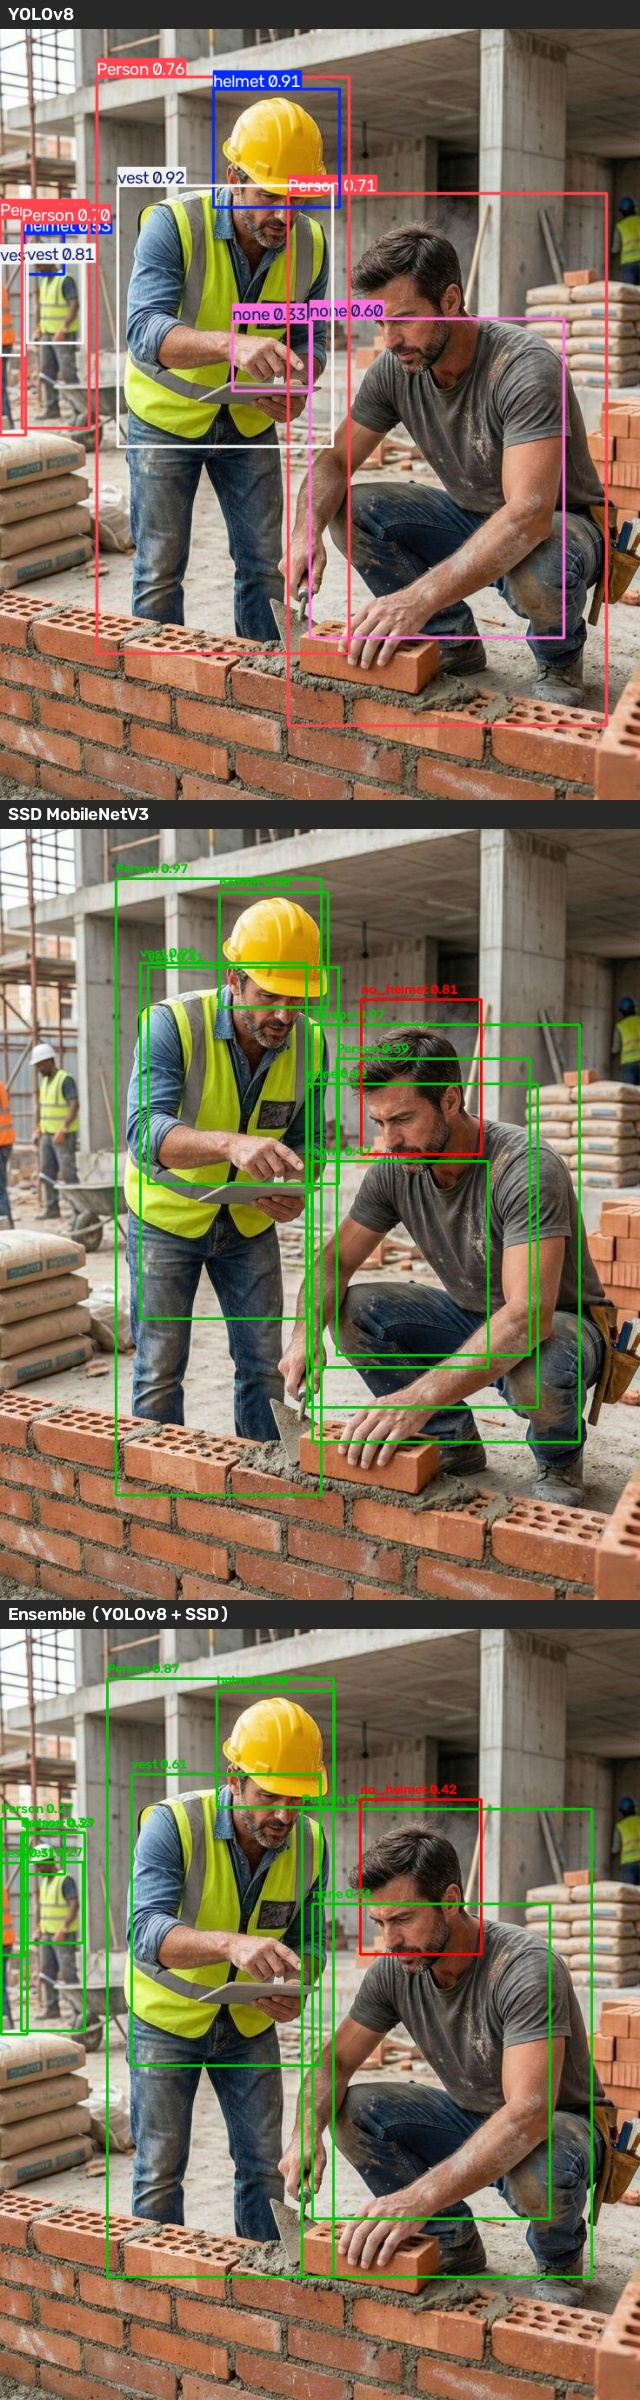

In [38]:
# ==== Parte 11 · Inferência interativa (imagem ou vídeo) — YOLOv8 vs SSD vs Ensemble ====
import os
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Image as IPyImage, Video as IPyVideo

# --- 0) Configuração ---
# "compare" : roda as TRÊS abordagens (YOLOv8 | SSD | Ensemble) e mostra os resultados um abaixo do outro
# "yolo"    : só o YOLOv8
# "ssd"     : só o SSD MobileNetV3
# "ensemble": só o Ensemble (YOLOv8 + SSD via WBF)
INFERENCE_MODE = "compare"
CONF_THRESHOLD = 0.25   # limiar de confiança só para esta demonstração visual (NÃO é o usado no cálculo do mAP, que usa 0.001)
PANEL_MAX_WIDTH = 640   # largura máx. (px) de cada painel no modo "compare" — só afeta a exibição; use None para não reduzir

BOX_COLOR = (0, 200, 0)        # verde: detecção normal (BGR)
VIOLATION_COLOR = (0, 0, 255)  # vermelho: classe de violação (no_helmet, no_goggle, no_gloves, no_boots)
LABEL_BAR_COLOR = (40, 40, 40)
LABEL_TEXT_COLOR = (255, 255, 255)

# --- 1) Localizar e carregar os pesos treinados (find_best_weights e loaders vêm da Parte 6b) ---
ssd_device = "cuda" if torch.cuda.is_available() else "cpu"
yolo_model = None
ssd_model = None

if INFERENCE_MODE in ("compare", "yolo", "ensemble"):
    yolo_path = find_best_weights(f"{PROJECT_DIR}/runs_yolo")
    if yolo_path is not None:
        print("Usando pesos YOLOv8:", yolo_path)
        yolo_model = load_yolo_from_weights(yolo_path)

if INFERENCE_MODE in ("compare", "ssd", "ensemble"):
    ssd_path = find_best_weights(f"{PROJECT_DIR}/runs_ssd")
    if ssd_path is not None:
        print("Usando pesos SSD MobileNetV3:", ssd_path)
        ssd_model = load_ssd_from_weights(ssd_path, ssd_device)

if INFERENCE_MODE == "yolo" and yolo_model is None:
    raise FileNotFoundError(
        "Nenhum peso treinado (best.pt) do YOLOv8 foi encontrado em "
        f"{PROJECT_DIR}/runs_yolo/. Rode a Parte 7 (ou 7b) antes desta célula.")
if INFERENCE_MODE == "ssd" and ssd_model is None:
    raise FileNotFoundError(
        "Nenhum peso treinado (best.pt) do SSD MobileNetV3 foi encontrado em "
        f"{PROJECT_DIR}/runs_ssd/. Rode a Parte 7 (ou 7b) antes desta célula.")
if INFERENCE_MODE == "ensemble" and (yolo_model is None or ssd_model is None):
    raise FileNotFoundError(
        "O modo 'ensemble' exige os pesos dos DOIS modelos (YOLOv8 em runs_yolo/ e SSD em runs_ssd/). "
        "Rode a Parte 7 (ou 7b) antes desta célula.")
if INFERENCE_MODE == "compare":
    if yolo_model is None and ssd_model is None:
        raise FileNotFoundError(
            "Modo 'compare' pedido, mas não há pesos treinados nem do YOLOv8 "
            f"({PROJECT_DIR}/runs_yolo/) nem do SSD ({PROJECT_DIR}/runs_ssd/). "
            "Rode a Parte 7 (ou 7b) para pelo menos um dos dois modelos.")
    missing = [n for n, m in ((YOLO_NAME, yolo_model), (SSD_NAME, ssd_model)) if m is None]
    if missing:
        print(f"⚠️ Pesos de {', '.join(missing)} não encontrados — seguindo só com o(s) modelo(s) disponível(is). "
              f"O painel do Ensemble exige os dois e não será exibido.")

ensemble_available = yolo_model is not None and ssd_model is not None

# --- 2) Upload do arquivo (imagem ou vídeo) ---
try:
    from google.colab import files
    print("Selecione uma foto (.jpg/.png) ou um vídeo (.mp4/.avi/.mov) para enviar:")
    uploaded = files.upload()
    input_path = list(uploaded.keys())[0]
except ImportError:
    # Fora do Colab: informe o caminho manualmente
    input_path = input("Caminho do arquivo (imagem ou vídeo) a analisar: ").strip()

ext = os.path.splitext(input_path)[1].lower()
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv"}

# --- 3) Funções de detecção por frame ---
def draw_boxes(frame_bgr, boxes, scores, labels):
    """Desenha as caixas com confiança >= CONF_THRESHOLD (violações em vermelho) e conta por classe."""
    annotated = frame_bgr.copy()
    counts = Counter()
    for box, score, cls_id in zip(boxes, scores, labels):
        if score < CONF_THRESHOLD:
            continue
        cls_id = int(cls_id)
        counts[cls_id] += 1
        x1, y1, x2, y2 = [int(v) for v in box]
        color = VIOLATION_COLOR if cls_id in VIOLATION_CLASS_IDS else BOX_COLOR
        label = f"{CLASS_NAMES[cls_id]} {score:.2f}"
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated, label, (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return annotated, counts

def run_yolo_frame(frame_bgr):
    result = yolo_model.predict(source=frame_bgr, conf=CONF_THRESHOLD, verbose=False)[0]
    annotated = result.plot()
    counts = Counter(int(c) for c in result.boxes.cls.cpu().numpy())
    return annotated, counts

def ssd_raw_from_frame(frame_bgr):
    return ssd_predict_raw(ssd_model, cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB), ssd_device)

def run_ssd_frame(frame_bgr, raw=None):
    raw = ssd_raw_from_frame(frame_bgr) if raw is None else raw
    return draw_boxes(frame_bgr, raw["boxes"].numpy(), raw["scores"].numpy(), raw["labels"].numpy())

def run_ensemble_frame(frame_bgr, ssd_raw=None):
    """Ensemble (WBF): YOLOv8 e SSD predizem com limiar baixo, as caixas são fundidas e só então filtradas
    por CONF_THRESHOLD — o mesmo pipeline usado na avaliação (Parte 6b)."""
    h, w = frame_bgr.shape[:2]
    ssd_raw = ssd_raw_from_frame(frame_bgr) if ssd_raw is None else ssd_raw
    yolo_raw = yolo_predict_raw(yolo_model, frame_bgr)
    fused = fuse_predictions([yolo_raw, ssd_raw], w, h)
    return draw_boxes(frame_bgr, fused["boxes"].numpy(), fused["scores"].numpy(), fused["labels"].numpy())

def panel_size(w, h):
    """Tamanho de cada painel no modo 'compare' (reduz só a exibição, mantendo a proporção)."""
    if INFERENCE_MODE != "compare" or PANEL_MAX_WIDTH is None or w <= PANEL_MAX_WIDTH:
        return w, h
    return PANEL_MAX_WIDTH, int(round(h * PANEL_MAX_WIDTH / w))

def fit_panel(frame_bgr):
    h, w = frame_bgr.shape[:2]
    pw, ph = panel_size(w, h)
    if (pw, ph) == (w, h):
        return frame_bgr
    return cv2.resize(frame_bgr, (pw, ph), interpolation=cv2.INTER_AREA)

def add_label_bar(frame_bgr, text):
    """Sobrepõe uma barra com o nome da abordagem no topo do frame (para identificar cada painel)."""
    out = frame_bgr.copy()
    bar_h = 28
    cv2.rectangle(out, (0, 0), (out.shape[1], bar_h), LABEL_BAR_COLOR, -1)
    cv2.putText(out, text, (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, LABEL_TEXT_COLOR, 2)
    return out

def run_detection_bgr(frame_bgr):
    """Roda a detecção em um frame BGR (numpy).
    - Em modo único ('yolo'/'ssd'/'ensemble'): retorna (frame_anotado, Counter).
    - Em modo 'compare': retorna (frame_empilhado, {nome_da_abordagem: Counter})."""
    if INFERENCE_MODE == "yolo":
        return run_yolo_frame(frame_bgr)
    if INFERENCE_MODE == "ssd":
        return run_ssd_frame(frame_bgr)
    if INFERENCE_MODE == "ensemble":
        return run_ensemble_frame(frame_bgr)

    # modo "compare": YOLOv8 | SSD | Ensemble
    panels, all_counts = [], {}
    ssd_raw = ssd_raw_from_frame(frame_bgr) if ssd_model is not None else None  # 1 inferência do SSD, usada no painel do SSD e no do Ensemble
    if yolo_model is not None:
        annotated, counts = run_yolo_frame(frame_bgr)
        panels.append(add_label_bar(fit_panel(annotated), YOLO_NAME))
        all_counts[YOLO_NAME] = counts
    if ssd_model is not None:
        annotated, counts = run_ssd_frame(frame_bgr, raw=ssd_raw)
        panels.append(add_label_bar(fit_panel(annotated), SSD_NAME))
        all_counts[SSD_NAME] = counts
    if ensemble_available:
        annotated, counts = run_ensemble_frame(frame_bgr, ssd_raw=ssd_raw)
        panels.append(add_label_bar(fit_panel(annotated), ENSEMBLE_NAME))
        all_counts[ENSEMBLE_NAME] = counts
    combined = np.vstack(panels) if len(panels) > 1 else panels[0]   # um painel abaixo do outro
    return combined, all_counts

# --- 4) Resumos ---
def summarize_detections(counts, class_names, violation_ids, label="EPIs / condições detectadas"):
    print(f"\n{label}:")
    if not counts:
        print("  Nenhuma detecção acima do limiar de confiança definido.")
        return
    for cls_id, n in sorted(counts.items(), key=lambda kv: -kv[1]):
        tag = " ⚠️ VIOLAÇÃO" if cls_id in violation_ids else ""
        print(f"  - {class_names[cls_id]}: {n}{tag}")

def is_multi_model(counts):
    """True se `counts` é um dict {nome_da_abordagem: Counter} (modo compare). Atenção: um Counter também
    é um dict, por isso o teste exclui explicitamente Counter (modo de abordagem única)."""
    return isinstance(counts, dict) and not isinstance(counts, Counter)

def summarize_counts(counts, class_names, violation_ids, label_prefix="EPIs / condições detectadas"):
    """Aceita tanto um Counter único (modo single) quanto um dict {nome_da_abordagem: Counter} (modo compare)."""
    if is_multi_model(counts):
        for model_name, model_counts in counts.items():
            summarize_detections(model_counts, class_names, violation_ids, label=f"{label_prefix} — {model_name}")
    else:
        summarize_detections(counts, class_names, violation_ids, label=label_prefix)

def print_counts_table(all_counts, class_names, violation_ids):
    """Tabela classe × abordagem, para comparar as três de uma vez (só no modo 'compare')."""
    if not is_multi_model(all_counts) or len(all_counts) < 2:
        return
    cls_ids = sorted({c for cnt in all_counts.values() for c in cnt})
    if not cls_ids:
        return
    rows = []
    for c in cls_ids:
        row = {"classe": class_names[c] + (" ⚠️" if c in violation_ids else "")}
        for model_name, cnt in all_counts.items():
            row[model_name] = cnt.get(c, 0)
        rows.append(row)
    print("\nComparativo de contagens por classe (⚠️ = violação):")
    display(pd.DataFrame(rows).set_index("classe"))

# --- 5a) Caso seja imagem ---
if ext in IMAGE_EXTS:
    frame_bgr = cv2.imread(input_path)
    annotated, counts = run_detection_bgr(frame_bgr)
    output_path = "/content/saida_deteccao.jpg"
    cv2.imwrite(output_path, annotated)

    summarize_counts(counts, CLASS_NAMES, VIOLATION_CLASS_IDS)
    print_counts_table(counts, CLASS_NAMES, VIOLATION_CLASS_IDS)
    display(IPyImage(filename=output_path))

# --- 5b) Caso seja vídeo ---
elif ext in VIDEO_EXTS:
    cap = cv2.VideoCapture(input_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if INFERENCE_MODE == "compare":
        n_panels = int(yolo_model is not None) + int(ssd_model is not None) + int(ensemble_available)
    else:
        n_panels = 1
    panel_w, panel_h = panel_size(w, h)
    out_w, out_h = panel_w, panel_h * n_panels   # painéis empilhados na vertical

    raw_output_path = "/content/saida_deteccao_raw.mp4"
    writer = cv2.VideoWriter(raw_output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (out_w, out_h))

    total_counts = {} if INFERENCE_MODE == "compare" else Counter()
    frame_idx = 0
    print(f"Processando vídeo ({n_frames} frames, {fps:.1f} fps)...")
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        annotated, counts = run_detection_bgr(frame)
        writer.write(annotated)
        if INFERENCE_MODE == "compare":
            for model_name, model_counts in counts.items():
                total_counts.setdefault(model_name, Counter()).update(model_counts)
        else:
            total_counts.update(counts)
        frame_idx += 1
        if frame_idx % 50 == 0:
            print(f"  ...{frame_idx}/{n_frames} frames processados")
    cap.release()
    writer.release()

    summarize_counts(
        total_counts, CLASS_NAMES, VIOLATION_CLASS_IDS,
        label_prefix="Total de detecções ao longo do vídeo (soma por frame, não deduplicado por objeto)",
    )
    print_counts_table(total_counts, CLASS_NAMES, VIOLATION_CLASS_IDS)

    # Reencoda para H.264 (o pad garante largura/altura pares, exigidas pelo yuv420p) para o navegador exibir o <video> inline
    output_path = "/content/saida_deteccao.mp4"
    os.system(f'ffmpeg -y -i "{raw_output_path}" -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" -vcodec libx264 -pix_fmt yuv420p "{output_path}" -loglevel error')
    display(IPyVideo(output_path, embed=True, width=min(1920, 640 * n_panels)))

    try:
        from google.colab import files
        files.download(output_path)
    except ImportError:
        print("Vídeo anotado salvo em:", output_path)

else:
    raise ValueError(f"Extensão '{ext}' não suportada. Envie uma imagem ({IMAGE_EXTS}) ou um vídeo ({VIDEO_EXTS}).")


## Parte 12 · Ameaças à validade e limitações (para o relatório)

| # | Ameaça | Tipo | Evidência neste notebook | Mitigação / efeito | Risco residual |
|---|---|---|---|---|---|
| 1 | YOLOv8 usa detector completo pré-treinado no COCO, Mosaic e entrada 640; SSD usa só o backbone ImageNet, augmentation simplificada e entrada 320 | Interna | Partes 5 e 6 | Declarada; não corrigível sem redefinir o SSD | **Alto**: parte da diferença YOLO × SSD não é arquitetural |
| 2 | Seleção do `best.pt` do YOLOv8 no próprio conjunto de teste (v1) | Interna | Parte 7e | Refeito sem a seleção: diferença média de mAP na CV = −0,0006; no Hold-Out, −0,006 | Baixo |
| 3 | Sem otimização de hiperparâmetros; Ensemble com pesos fixos [1, 1]; SSD possivelmente subtreinado | Interna | Partes 5–6b | Declarada | Médio |
| 4 | Treino do SSD sem semente na execução original; GPU não determinística | Interna | Parte 6d; mAP do SSD recalculado com os mesmos pesos: 0,3694 vs 0,3690 | Sementes fixas em execuções novas | Baixo |
| 5 | Folds compartilham dados de treino; n = 10; p-valores indicativos | Conclusão estatística | Parte 9h | Holm; conclusões apoiadas também em ICs e tamanhos de efeito | Médio |
| 6 | Hold-Out único com poucas instâncias de violação (`no_boots`: 12; entre 2 e 24 por fold) | Conclusão estatística | Partes 3c, 9c e 9h | ICs por bootstrap e Wilson; métricas por classe também na CV | **Alto** para `no_boots` |
| 7 | Métricas globais mascaram o desempenho nas violações | Construto | Partes 9c e 9d | Métricas por classe, por imagem e H2/H3 | Baixo (tratada) |
| 8 | Limiar fixo 0,25 e alerta por imagem (permissivo: não exige acertar classe nem local) | Construto | Partes 9c, 9f e 9g: 65% das violações do YOLOv8 têm detecção da classe certa com confiança < 0,25; com limiar por classe (OOF) o recall do alerta permissivo sobe de 0,59 para 0,95 | Limiar por classe como análise exploratória e três critérios de acerto (permissivo, por classe, por caixa) | Médio |
| 9 | Aviso do torchmetrics (>100 detecções por imagem): o corte do COCO é **por classe em cada imagem**, então o efeito esperado é pequeno | Construto | Parte 9h (sensibilidade ii: AP@0.5 em NumPy com 100, 300 e sem limite) | Efeito medido; implementação NumPy conferida contra o torchmetrics | Baixo |
| 10 | FPS depende de hardware e do caminho de inferência | Construto | Parte 10 | Benchmark único no mesmo ambiente | Médio |
| 11 | Estimativa financeira usa valores fictícios | Construto | Partes 9b e 9i | Rotulada como ilustrativa | Baixo |
| 12 | Um único dataset; cenas fora de obra (ginásio, academia) e política de anotação `no_*` por pessoa; semântica de `none`; sem `no_vest`; desempenho por subgrupo (pele, luz) não medido | Externa | Partes 9e e 9f | Declarada | **Alto** para generalização |
| 13 | Quase-duplicatas entre treino e teste; sem metadados de cena para agrupar | Vazamento | Parte 3c: 126 pares (correlação ≥ 0,97), 168 imagens (11,9%) em grupos; 6,2% a 14,2% das imagens de teste de cada fold e 10,2% do Hold-Out (29 de 284) têm quase-duplicata no treino. Parte 9h: sem essas imagens, o mAP do Hold-Out cai 0,012 a 0,015 nas três abordagens | Ordenação entre abordagens preservada; efeito medido; agrupar por cena exigiria metadados | Médio |
| 14 | Dados pessoais (rostos) e uso punitivo | Ética | Partes 9e e 11 | Figuras não exibidas por padrão; uso como apoio, com revisão humana | Médio |
| 15 | Licença AGPL-3.0 (dataset e biblioteca Ultralytics) | Legal | README | Não redistribuir o dataset; verificar a licença do código | Baixo |

**Próximos passos:** validação agrupada por cena (se houver metadados), calibração/limiar por classe validado em dados novos, rebalanceamento ou *loss* focal para as classes de violação, mais dados de `no_boots`, SSD com entrada e âncoras a 640 para eliminar a assimetria, e avaliação por subgrupo.